# EV2 - Proyecto de Mineria de Datos

*Integrantes* :<b>Flavio Henriquez / Bastian Bianchi / Martin Pero</b> <br>
*Docente* : <b>Italo Bonnet</b>  <br>
*Asignatira* : <b>Mineria de datos BIY7121-005D</b><br>
*Grupo* : <b>4</b>

<img src="xdddd.png" style="width:100%;">

## Analisis de precipitaciones, temperaturas y estaciones meteorologicas en Chile

**Asignatura:** BIY7121 - Mineria de Datos  
**Metodologia:** CRISP-DM  
**Dataset base:** precipitaciones, temperaturas y estaciones meteorologicas de Chile  
**Periodo de analisis:** 2021-2025

Este notebook desarrolla un proyecto de mineria de datos aplicado a informacion meteorologica nacional. El objetivo es analizar el comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas, detectar patrones climaticos relevantes y construir modelos predictivos y descriptivos que apoyen la toma de decisiones.

## Estructura del notebook

La estructura del trabajo sigue las fases solicitadas para el proyecto de Data Mining:

1. **Entendimiento del Negocio**
2. **Entendimiento de Datos**
3. **Transformacion**
4. **Modelamiento**
5. **Evaluacion**
6. **Deploy**

En este notebook se desarrollan las fases de entendimiento del negocio, entendimiento de datos, transformacion, modelamiento, evaluacion y deploy conceptual. La organizacion busca que cada decision sea trazable mediante una explicacion previa, codigo breve y analisis posterior cuando corresponde.


**Mini objetivo:** cargar librerias y definir parametros generales de visualizacion antes de iniciar el analisis.


In [1]:
from pathlib import Path
import csv
import json
import re
import subprocess
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import LinearSVR, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, silhouette_score

try:
    import seaborn as sns
except ImportError:
    sns = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.25, 'axes.titlesize': 12, 'axes.labelsize': 10})


**Mini objetivo:** configurar la carpeta `.data/DataMining_Datos` como repositorio externo de datos. Si la carpeta no existe, se clona desde GitHub; si ya existe, se usa como repositorio local independiente del notebook.

In [2]:
DATA_REPO_URL = 'https://github.com/4mnesia/DataMining_Datos.git'
DATA_ROOT = Path('.data')
DATA_DIR = DATA_ROOT / 'DataMining_Datos'
DATA_ROOT.mkdir(exist_ok=True)

estado_repo_datos = 'repo Git local existente'
if not DATA_DIR.exists():
    resultado = subprocess.run(['git', 'clone', DATA_REPO_URL, str(DATA_DIR)], capture_output=True, text=True)
    if resultado.returncode != 0:
        raise RuntimeError(resultado.stderr)
    estado_repo_datos = 'clonado desde GitHub'
elif not (DATA_DIR / '.git').exists():
    estado_repo_datos = 'carpeta local sin metadata Git'

origen_repo_datos = DATA_REPO_URL
if (DATA_DIR / '.git').exists():
    resultado = subprocess.run(['git', '-C', str(DATA_DIR), 'remote', 'get-url', 'origin'], capture_output=True, text=True)
    origen_repo_datos = resultado.stdout.strip() or DATA_REPO_URL

repo_datos_info = pd.DataFrame([{
    'repo_datos': DATA_DIR.as_posix(),
    'origen_git': origen_repo_datos,
    'estado': estado_repo_datos
}])

display(repo_datos_info)


,repo_datos,origen_git,estado
0,.data/DataMining_Datos,https://github.com/4mnesia/DataMining_Datos.git,repo Git local existente


**Analisis del repositorio de datos:**

La carpeta `.data/DataMining_Datos` se maneja como una fuente de datos externa e independiente. Esto permite mantener separado el notebook del repositorio de datasets, facilitando reproducibilidad y evitando mezclar codigo del proyecto con archivos de datos.

**Mini objetivo:** definir rutas de trabajo y verificar que las fuentes de datos existan antes de cargar informacion.

In [3]:
PRECIP_TEMP_CSV = DATA_DIR / 'dataset_precipitaciones_temperaturas_chile.csv'
PRECIP_CSV = DATA_DIR / 'dataset_precipitaciones_diarias_chile_COMPLETO.csv'
STATIONS_JSON = DATA_DIR / 'getEstacionesRedEma.json'
CHILE_GEOJSON = DATA_ROOT / 'chile_country.geojson'
KOPPEN_DIR = DATA_ROOT / 'koppen_geiger'
KOPPEN_TIF = KOPPEN_DIR / 'koppen_geiger_1991_2020_1km.tif'
KOPPEN_LEGEND = KOPPEN_DIR / 'legend.txt'
KOPPEN_TIF_URL = 'https://data.naturalcapitalalliance.stanford.edu/download/global/koppen_geiger_climatezones/koppen_geiger_climatezones_1991_2020_1km.tif'
KOPPEN_LEGEND_URL = 'https://data.naturalcapitalalliance.stanford.edu/download/global/koppen_geiger_climatezones/legend.txt'

fuentes = {
    'Dataset precipitaciones + temperaturas': PRECIP_TEMP_CSV,
    'Dataset precipitaciones diarias': PRECIP_CSV,
    'Metadata de estaciones': STATIONS_JSON,
    'GeoJSON Chile': CHILE_GEOJSON,
    'Koppen-Geiger 1991-2020 1 km': KOPPEN_TIF,
    'Leyenda Koppen-Geiger': KOPPEN_LEGEND,
}

estado_fuentes = pd.DataFrame([
    {'fuente': nombre, 'ruta': ruta.as_posix(), 'estado': 'OK' if ruta.exists() else 'NO ENCONTRADO'}
    for nombre, ruta in fuentes.items()
])

display(estado_fuentes)

,fuente,ruta,estado
0,Dataset precipitaciones + temperaturas,.data/DataMining_Datos/dataset_precipitaciones...,OK
1,Dataset precipitaciones diarias,.data/DataMining_Datos/dataset_precipitaciones...,OK
2,Metadata de estaciones,.data/DataMining_Datos/getEstacionesRedEma.json,OK
3,GeoJSON Chile,.data/chile_country.geojson,OK
4,Koppen-Geiger 1991-2020 1 km,.data/koppen_geiger/koppen_geiger_1991_2020_1k...,OK
5,Leyenda Koppen-Geiger,.data/koppen_geiger/legend.txt,OK


**Analisis de disponibilidad de archivos:**

La validacion permite confirmar que las fuentes requeridas estan disponibles en las rutas esperadas. Al separar el repositorio de datos dentro de `.data`, el notebook queda preparado para ejecutarse en otro equipo clonando primero `DataMining_Datos`.

# 1. Entendimiento del Negocio

La fase de entendimiento del negocio define el contexto del problema, los datos disponibles, las hipotesis iniciales, los indicadores clave y el problema de mineria de datos que se abordara. Esta fase es fundamental en CRISP-DM, porque orienta las decisiones posteriores de limpieza, transformacion, modelamiento y evaluacion.

## 1.1 Contexto

Chile presenta una geografia extensa y diversa, con diferencias climaticas importantes entre el norte, centro, sur, zonas costeras, valles, precordillera y cordillera. Esta diversidad hace que el comportamiento de las precipitaciones y temperaturas varie de forma significativa segun ubicacion, altura, estacion del anio y zona geografica.

El analisis de datos meteorologicos permite transformar registros historicos en conocimiento util para la toma de decisiones. En particular, la informacion de precipitaciones, temperaturas y estaciones puede apoyar procesos relacionados con monitoreo climatico, gestion territorial, planificacion agricola, prevencion de riesgos, gestion hidrica y deteccion de eventos extremos.

Desde la perspectiva de mineria de datos, el problema no consiste solo en describir registros climaticos, sino en descubrir patrones, relaciones y comportamientos que no son evidentes al observar los datos de forma aislada. Por ello, el proyecto se abordara mediante una combinacion de analisis exploratorio, limpieza de datos, transformacion de variables, modelos predictivos y modelos descriptivos.

## 1.2 Datos relevantes

Los datos disponibles se encuentran en la carpeta `.data`. Dentro de ella, `DataMining_Datos` se maneja como un repositorio Git externo clonado desde `https://github.com/4mnesia/DataMining_Datos.git`, separado del repositorio principal del notebook.

| Fuente | Ruta | Uso en el proyecto |
|---|---|---|
| Dataset de precipitaciones y temperaturas | `.data/DataMining_Datos/dataset_precipitaciones_temperaturas_chile.csv` | Fuente principal del proyecto. Contiene precipitacion, temperatura, fecha, estacion y variables geograficas. |
| Dataset de precipitaciones diarias | `.data/DataMining_Datos/dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Fuente de respaldo para contrastar registros de precipitacion. |
| Metadata de estaciones | `.data/DataMining_Datos/getEstacionesRedEma.json` | Informacion descriptiva de estaciones meteorologicas: codigo, nombre, region, zona, coordenadas y altura. |
| Mapa de Chile | `.data/chile_country.geojson` | Apoyo opcional para visualizaciones geograficas. |

Resumen verificado del dataset principal:

| Caracteristica | Valor |
|---|---:|
| Registros | 187.876 |
| Periodo | 2021-01-01 a 2025-12-31 |
| Estaciones presentes en el dataset | 109 |
| Estaciones informadas en metadata JSON | 148 |
| Regiones | 16 |
| Zonas geograficas | Cordillera, Litoral, PreCordillera, Secano Costero, Secano Interior, Valle |
| Filas con formato especial a corregir | 74.112 |
| Nulos en `agua_caida` | 9,08% |
| Nulos en `temp_max` | 11,20% |
| Nulos en `temp_min` | 11,69% |
| Nulos en `temp_media` | 12,09% |

Variables principales:

| Grupo | Variables | Descripcion |
|---|---|---|
| Temporales | `fecha`, `anio`, `mes`, `dia` | Permiten analizar estacionalidad y comportamiento por periodo. |
| Geograficas | `region`, `nombre_region`, `latitud`, `longitud`, `altura`, `zona_geografica` | Permiten relacionar el clima con ubicacion y caracteristicas territoriales. |
| Estacion | `codigo_estacion`, `nombre_estacion` | Identifican el origen de cada registro meteorologico. |
| Precipitacion | `agua_caida` | Variable numerica principal para analizar lluvia diaria. |
| Temperatura | `temp_max`, `temp_min`, `temp_media` | Variables numericas para analizar comportamiento termico. |

Una consideracion importante es que el dataset principal presenta filas completas encerradas entre comillas, lo que requiere una carga controlada del archivo antes de iniciar el analisis. Este hallazgo sera tratado formalmente en la fase de entendimiento y limpieza de datos.

**Mini objetivo:** resumir las caracteristicas principales del dataset para dejar evidencia rapida de la fuente de datos usada en el proyecto.


In [4]:
resumen_datos = pd.DataFrame([
    {'Elemento': 'Registros del dataset principal', 'Valor': '187.876'},
    {'Elemento': 'Periodo de analisis', 'Valor': '2021-01-01 a 2025-12-31'},
    {'Elemento': 'Estaciones presentes en dataset', 'Valor': '109'},
    {'Elemento': 'Estaciones en metadata JSON', 'Valor': '148'},
    {'Elemento': 'Regiones', 'Valor': '16'},
    {'Elemento': 'Variables climaticas principales', 'Valor': 'agua_caida, temp_max, temp_min, temp_media'},
    {'Elemento': 'Variables geograficas principales', 'Valor': 'region, zona_geografica, latitud, longitud, altura'},
    {'Elemento': 'Problema de formato detectado', 'Valor': '74.112 filas completas entre comillas'},
])

resumen_datos

,Elemento,Valor
0,Registros del dataset principal,187.876
1,Periodo de analisis,2021-01-01 a 2025-12-31
2,Estaciones presentes en dataset,109
3,Estaciones en metadata JSON,148
4,Regiones,16
5,Variables climaticas principales,"agua_caida, temp_max, temp_min, temp_media"
6,Variables geograficas principales,"region, zona_geografica, latitud, longitud, al..."
7,Problema de formato detectado,74.112 filas completas entre comillas


**Analisis del resumen de datos:**

El resumen confirma que el dataset principal es suficiente para un problema de mineria de datos porque combina volumen temporal, cobertura territorial y variables climaticas. Esta evidencia permite sostener un objetivo predictivo, no solo descriptivo.

## 1.3 Hipotesis y tesis consideradas

### Tesis general del proyecto

El comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas en Chile puede explicarse parcialmente mediante variables temporales, geograficas y termicas. A partir de estas variables es posible detectar patrones climaticos, identificar eventos extremos y construir modelos predictivos y descriptivos utiles para la toma de decisiones.

### Hipotesis de trabajo

| Hipotesis | Descripcion | Variables asociadas | Tipo de analisis esperado |
|---|---|---|---|
| H1 | La precipitacion diaria presenta diferencias significativas entre regiones y zonas geograficas. | `agua_caida`, `region`, `zona_geografica` | Analisis estadistico, visualizacion y comparacion por grupos. |
| H2 | La probabilidad de lluvia varia segun el mes y la estacion del anio. | `agua_caida`, `mes`, `fecha` | Creacion de variables temporales y clasificacion de dias lluviosos. |
| H3 | La temperatura media se relaciona con la latitud, altura y zona geografica de la estacion. | `temp_media`, `latitud`, `altura`, `zona_geografica` | Correlacion, regresion y visualizacion geografica. |
| H4 | Los dias con lluvia intensa presentan patrones distintos de temperatura y ubicacion respecto de dias sin lluvia. | `agua_caida`, `temp_media`, `temp_max`, `temp_min`, `region`, `zona_geografica` | Clasificacion y analisis comparativo. |
| H5 | Es posible agrupar estaciones meteorologicas con comportamientos climaticos similares. | `agua_caida`, `temp_media`, `altura`, `latitud`, `longitud` | Clustering con K-Means. |
| H6 | Algunos valores extremos de precipitacion pueden corresponder a eventos climaticos excepcionales o a posibles problemas de calidad de datos. | `agua_caida`, `fecha`, `codigo_estacion`, `nombre_estacion` | Deteccion de outliers y revision contextual. |

Estas hipotesis guiaran la seleccion de variables, la construccion de nuevas caracteristicas y la eleccion de modelos en las siguientes fases del proyecto.

## 1.4 KPI's relevantes

Los KPI propuestos permiten evaluar el comportamiento climatico, la calidad de los datos y el rendimiento posterior de los modelos.

| KPI | Formula o criterio | Utilidad |
|---|---|---|
| Precipitacion acumulada | Suma de `agua_caida` por estacion, region, zona o periodo | Identificar territorios con mayor volumen de lluvia. |
| Precipitacion promedio diaria | Promedio de `agua_caida` | Comparar comportamiento normal entre estaciones o regiones. |
| Dias con lluvia | Conteo de registros donde `agua_caida > 0` | Medir frecuencia de lluvia. |
| Porcentaje de dias con lluvia | Dias con lluvia / total de dias observados | Comparar estaciones con distinta cantidad de registros. |
| Eventos de lluvia intensa | Registros sobre un umbral, por ejemplo percentil 95 de `agua_caida` | Detectar eventos relevantes para riesgo climatico. |
| Temperatura media promedio | Promedio de `temp_media` | Caracterizar comportamiento termico por zona. |
| Rango termico promedio | Promedio de `temp_max - temp_min` | Medir variabilidad diaria de temperatura. |
| Cobertura de datos por estacion | Registros validos / registros esperados | Evaluar calidad y completitud de informacion. |
| Porcentaje de nulos por variable | Nulos / total de registros | Priorizar tratamiento de datos faltantes. |
| RMSE / R2 | Metricas de regresion | Evaluar modelos que predigan valores numericos. |
| Accuracy / F1-score / matriz de confusion | Metricas de clasificacion | Evaluar modelos que predigan lluvia o lluvia intensa. |
| Silhouette score | Metrica de clustering | Evaluar separacion y coherencia de grupos. |

Los KPI climaticos se usaran en el analisis exploratorio, mientras que los KPI de rendimiento se usaran en la fase de evaluacion de modelos.

**Mini objetivo:** organizar los KPI propuestos en una tabla simple para conectar el problema de negocio con indicadores medibles.


In [5]:
kpis = pd.DataFrame([
    {'KPI': 'Precipitacion acumulada', 'Variable base': 'agua_caida', 'Nivel': 'region / zona / estacion / periodo'},
    {'KPI': 'Precipitacion promedio diaria', 'Variable base': 'agua_caida', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Dias con lluvia', 'Variable base': 'agua_caida > 0', 'Nivel': 'estacion / region / mes'},
    {'KPI': 'Eventos de lluvia intensa', 'Variable base': 'agua_caida sobre umbral', 'Nivel': 'estacion / region / fecha'},
    {'KPI': 'Temperatura media promedio', 'Variable base': 'temp_media', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Rango termico promedio', 'Variable base': 'temp_max - temp_min', 'Nivel': 'region / zona / estacion'},
    {'KPI': 'Porcentaje de nulos', 'Variable base': 'isna()', 'Nivel': 'variable / estacion'},
])

kpis

,KPI,Variable base,Nivel
0,Precipitacion acumulada,agua_caida,region / zona / estacion / periodo
1,Precipitacion promedio diaria,agua_caida,region / zona / estacion
2,Dias con lluvia,agua_caida > 0,estacion / region / mes
3,Eventos de lluvia intensa,agua_caida sobre umbral,estacion / region / fecha
4,Temperatura media promedio,temp_media,region / zona / estacion
5,Rango termico promedio,temp_max - temp_min,region / zona / estacion
6,Porcentaje de nulos,isna(),variable / estacion


**Analisis de KPI:**

Los KPI conectan las variables disponibles con decisiones de negocio: precipitacion acumulada, lluvia intensa, temperatura y cobertura territorial. Esta tabla ayuda a que los modelos posteriores tengan una justificacion clara y medible.

## 1.5 Problema de negocio (Prediccion)

El problema de negocio se define como la necesidad de anticipar y comprender el comportamiento de precipitaciones y temperaturas en estaciones meteorologicas de Chile, utilizando informacion historica, geografica y temporal.

Desde la perspectiva de mineria de datos, el proyecto abordara tres lineas de modelamiento:

### Problema predictivo de regresion

Predecir una variable numerica climatica a partir de caracteristicas temporales, geograficas y termicas.

**Variable objetivo candidata:**

- `agua_caida`: precipitacion diaria registrada.
- `temp_media`: temperatura media diaria.

**Variables explicativas candidatas:**

- `mes`, `anio`, `dia`
- `region`, `zona_geografica`
- `latitud`, `longitud`, `altura`
- `temp_max`, `temp_min`, `temp_media`, segun la variable objetivo seleccionada

### Problema predictivo de clasificacion

Clasificar si un registro corresponde a un dia sin lluvia, con lluvia o con lluvia intensa.

**Variables objetivo candidatas:**

- `llueve`: variable binaria creada a partir de `agua_caida > 0`.
- `lluvia_intensa`: variable binaria creada a partir de un umbral estadistico, por ejemplo el percentil 95 de `agua_caida`.

### Problema descriptivo de clustering

Agrupar estaciones o registros climaticos con comportamientos similares, usando variables como precipitacion promedio, temperatura media, altura, latitud, longitud y zona geografica.

### Criterios de exito

El proyecto sera considerado exitoso si logra:

1. Identificar patrones climaticos interpretables por region, zona geografica, estacion y mes.
2. Detectar y justificar el tratamiento de nulos y outliers.
3. Construir variables nuevas utiles para el modelamiento.
4. Comparar modelos de regresion, clasificacion y clustering.
5. Evaluar los modelos con metricas coherentes: RMSE, R2, matriz de confusion, F1-score y Silhouette score.
6. Traducir resultados tecnicos en conclusiones comprensibles para la toma de decisiones.

Con esta definicion, las siguientes fases se orientaran a preparar un dataset confiable, explorar patrones y construir modelos que respondan directamente a las hipotesis planteadas.

## Cierre de Fase 1

La Fase 1 establece el marco formal del proyecto. Se definio el contexto, se rectificaron las fuentes de datos disponibles, se formularon hipotesis, se establecieron KPI relevantes y se delimito el problema de negocio como un proyecto mixto de prediccion y descripcion climatica.

La siguiente fase corresponde al **Entendimiento de Datos**, donde se cargara el dataset, se corregira el formato especial de algunas filas, se identificaran tipos de variables, nulos, outliers, estadisticos basicos, correlaciones y primeros patrones observados.

# 2. Entendimiento Datos

En esta fase se estudia la estructura real del dataset antes de tomar decisiones de limpieza profunda o modelamiento. El objetivo es conocer la calidad de los datos, identificar tipos de variables, nulos, outliers, distribuciones, correlaciones y primeros patrones climaticos.

La decision principal de esta fase es trabajar con el archivo `dataset_precipitaciones_temperaturas_chile.csv`, porque integra precipitaciones, temperaturas, estaciones y variables geograficas. El archivo de precipitaciones diarias se usara como respaldo si se requiere contrastar la variable `agua_caida`.


## 2.0 Carga controlada del dataset principal

Antes de analizar los datos se debe resolver un problema de formato detectado en el CSV principal: una parte de las filas viene encerrada completamente entre comillas. Si se carga el archivo directamente, esas filas quedan interpretadas como un solo campo y se distorsionan los tipos de datos, los nulos y los conteos de estaciones.

Por esta razon se construye una carga controlada. Esta carga no cambia los valores originales del dataset; solo corrige la lectura de filas completas entre comillas para que cada columna quede en su posicion correcta.


**Mini objetivo:** definir explicitamente las columnas esperadas del archivo principal para controlar que la carga del CSV quede alineada.


In [6]:
COLUMNAS_CLIMA = [
    'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
    'anio', 'mes', 'dia', 'agua_caida', 'fecha', 'nombre_estacion',
    'nombre_region', 'zona_geografica', 'temp_max', 'temp_min', 'temp_media'
]


**Mini objetivo:** crear una funcion de carga robusta que corrija filas completas entre comillas y convierta los tipos de datos principales.


In [7]:
def leer_filas_clima(ruta_csv):
    filas = []
    filas_entre_comillas = 0
    filas_con_error = []

    with open(ruta_csv, 'r', encoding='utf-8-sig', newline='') as archivo:
        _ = next(archivo)

        for numero_linea, fila_original in enumerate(archivo, start=2):
            fila = fila_original.rstrip('\r\n')

            if len(fila) >= 2 and fila[0] == '"' and fila[-1] == '"':
                filas_entre_comillas += 1
                fila = fila[1:-1].replace('""', '"')

            valores = next(csv.reader([fila]))
            if len(valores) == len(COLUMNAS_CLIMA):
                filas.append(valores)
            else:
                filas_con_error.append((numero_linea, len(valores)))

    return filas, filas_entre_comillas, filas_con_error


**Mini objetivo:** convertir las filas leidas a un DataFrame y asignar tipos numericos, temporales y de texto.


In [8]:
def corregir_texto_mojibake(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor)
    try:
        return valor.encode('latin1').decode('utf-8')
    except UnicodeError:
        return valor


def convertir_tipos_clima(filas):
    datos = pd.DataFrame(filas, columns=COLUMNAS_CLIMA)

    columnas_numericas = [
        'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
        'anio', 'mes', 'dia', 'agua_caida', 'temp_max', 'temp_min', 'temp_media'
    ]
    for columna in columnas_numericas:
        datos[columna] = pd.to_numeric(datos[columna], errors='coerce')

    datos['fecha'] = pd.to_datetime(datos['fecha'], errors='coerce')

    for columna in ['nombre_estacion', 'nombre_region', 'zona_geografica']:
        datos[columna] = datos[columna].apply(corregir_texto_mojibake).astype('string').str.strip()

    return datos


**Mini objetivo:** unir lectura, conversion y resumen de carga en una funcion principal reutilizable.


In [9]:
def cargar_dataset_clima(ruta_csv):
    filas, filas_entre_comillas, filas_con_error = leer_filas_clima(ruta_csv)
    datos = convertir_tipos_clima(filas)

    resumen = {
        'filas_cargadas': len(datos),
        'columnas_cargadas': datos.shape[1],
        'filas_entre_comillas_corregidas': filas_entre_comillas,
        'filas_con_error': len(filas_con_error),
    }

    return datos, resumen, filas_con_error


**Mini objetivo:** ejecutar la carga controlada y revisar una muestra inicial del dataset corregido.


In [10]:
df, resumen_carga, filas_con_error = cargar_dataset_clima(PRECIP_TEMP_CSV)

display(pd.DataFrame([resumen_carga]))
display(df.head(3))


,filas_cargadas,columnas_cargadas,filas_entre_comillas_corregidas,filas_con_error
0,187876,16,74112,0


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,temp_max,temp_min,temp_media
0,170001,15,4084,-17.595,-69.478,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
1,170001,15,4084,-17.595,-69.478,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
2,170001,15,4084,-17.595,-69.478,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN


**Analisis de carga:**

La carga controlada permite trabajar con el dataset principal sin perder columnas ni registros. El punto mas importante es que las filas completas entre comillas no se eliminan: se corrige su lectura para conservar la informacion disponible. Esto es coherente con buenas practicas de preparacion de datos, porque primero se corrige el problema de estructura antes de evaluar nulos, outliers o patrones.


## 2.1 Identificar Tipos de variables/atributos

En mineria de datos es necesario distinguir entre variables numericas, categoricas, temporales e identificadores. Esta clasificacion define que analisis se puede hacer y que transformaciones seran necesarias antes del modelamiento.


**Mini objetivo:** clasificar las variables segun su naturaleza: identificadores, temporales, categoricas, geograficas y climaticas.


In [11]:
tipos_variables = pd.DataFrame([
    {'variable': 'codigo_estacion', 'tipo_conceptual': 'Identificador', 'uso': 'Identifica la estacion meteorologica'},
    {'variable': 'region', 'tipo_conceptual': 'Categorica codificada', 'uso': 'Agrupacion territorial'},
    {'variable': 'nombre_region', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Etiqueta de region'},
    {'variable': 'zona_geografica', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Zona fisica o climatica'},
    {'variable': 'nombre_estacion', 'tipo_conceptual': 'Categorica nominal', 'uso': 'Nombre de estacion'},
    {'variable': 'fecha', 'tipo_conceptual': 'Temporal', 'uso': 'Analisis por dia, mes, anio y estacion'},
    {'variable': 'anio, mes, dia', 'tipo_conceptual': 'Temporales numericas', 'uso': 'Componentes de fecha'},
    {'variable': 'altura, latitud, longitud', 'tipo_conceptual': 'Numericas geograficas', 'uso': 'Ubicacion y condicion territorial'},
    {'variable': 'agua_caida', 'tipo_conceptual': 'Numerica continua', 'uso': 'Precipitacion diaria'},
    {'variable': 'temp_max, temp_min, temp_media', 'tipo_conceptual': 'Numericas continuas', 'uso': 'Temperatura diaria'},
])

display(tipos_variables)
display(df.dtypes.to_frame('tipo_python'))


,variable,tipo_conceptual,uso
0,codigo_estacion,Identificador,Identifica la estacion meteorologica
1,region,Categorica codificada,Agrupacion territorial
2,nombre_region,Categorica nominal,Etiqueta de region
3,zona_geografica,Categorica nominal,Zona fisica o climatica
4,nombre_estacion,Categorica nominal,Nombre de estacion
5,fecha,Temporal,"Analisis por dia, mes, anio y estacion"
6,"anio, mes, dia",Temporales numericas,Componentes de fecha
7,"altura, latitud, longitud",Numericas geograficas,Ubicacion y condicion territorial
8,agua_caida,Numerica continua,Precipitacion diaria
9,"temp_max, temp_min, temp_media",Numericas continuas,Temperatura diaria


,tipo_python
codigo_estacion,int64
region,int64
altura,int64
latitud,float64
longitud,float64
anio,int64
mes,int64
dia,int64
agua_caida,float64
fecha,datetime64[ns]


**Analisis de tipos:**

El dataset combina variables climaticas, geograficas, temporales y categoricas. Para analisis estadistico y modelamiento, las variables numericas pueden usarse directamente despues de tratar nulos y outliers. Las variables categoricas como `nombre_region` y `zona_geografica` requeriran encoding en fases posteriores. La variable `codigo_estacion` identifica observaciones, pero no debe interpretarse como magnitud numerica.


### Cobertura temporal y territorial

Antes de analizar nulos o modelos, se revisa si los datos cubren adecuadamente el periodo y las regiones disponibles. Esta revision permite detectar concentraciones o vacios importantes en la captura de datos.


**Mini objetivo:** calcular un resumen general para validar cobertura temporal, territorial, duplicados y cantidad de estaciones.


In [12]:
resumen_general = pd.DataFrame([
    {'indicador': 'registros', 'valor': len(df)},
    {'indicador': 'columnas', 'valor': df.shape[1]},
    {'indicador': 'fecha_minima', 'valor': df['fecha'].min()},
    {'indicador': 'fecha_maxima', 'valor': df['fecha'].max()},
    {'indicador': 'estaciones', 'valor': df['codigo_estacion'].nunique()},
    {'indicador': 'regiones', 'valor': df['region'].nunique()},
    {'indicador': 'zonas_geograficas', 'valor': df['zona_geografica'].nunique()},
    {'indicador': 'duplicados', 'valor': df.duplicated().sum()},
])

display(resumen_general)


,indicador,valor
0,registros,187876
1,columnas,16
2,fecha_minima,2021-01-01 00:00:00
3,fecha_maxima,2025-12-31 00:00:00
4,estaciones,109
5,regiones,16
6,zonas_geograficas,6
7,duplicados,0


**Analisis de cobertura:**

El dataset tiene una cobertura amplia en registros, anos, estaciones y regiones. Esta base es adecuada para comparar patrones territoriales y temporales, aunque los desbalances por region deben considerarse al interpretar modelos y graficos.

**Mini objetivo:** visualizar la cobertura de registros por anio y por region para detectar desbalances de datos.


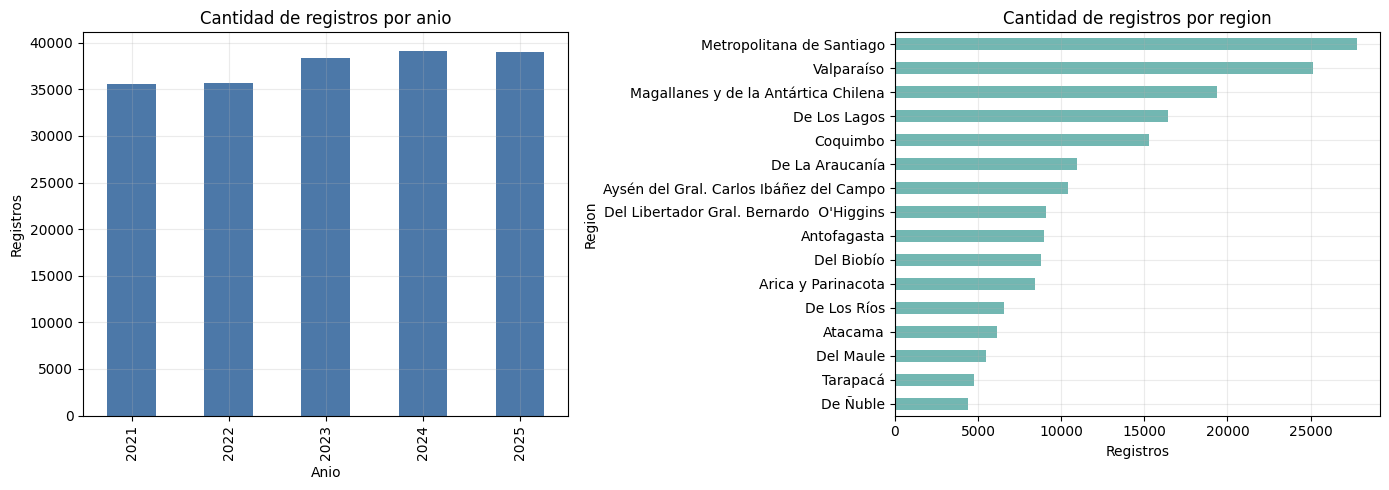

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['anio'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cantidad de registros por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Registros')

registros_region = df.groupby('nombre_region')['codigo_estacion'].size().sort_values()
registros_region.plot(kind='barh', ax=axes[1], color='#72b7b2')
axes[1].set_title('Cantidad de registros por region')
axes[1].set_xlabel('Registros')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis de cobertura:**

El dataset cubre varios anios y todas las regiones del pais, lo que permite comparar comportamientos territoriales y temporales. Sin embargo, la cantidad de registros no es igual para todas las regiones ni estaciones, por lo que en analisis posteriores conviene usar promedios, porcentajes o tasas cuando se comparen territorios con distinta cantidad de observaciones.


## 2.2 Identificar Nulo

La busqueda de valores nulos es un requisito central de la preparacion de datos. En este proyecto los nulos son especialmente importantes porque pueden representar ausencia de medicion, fallas de estacion o dias sin informacion disponible. No se asumira automaticamente que un nulo en precipitacion equivale a cero.


**Mini objetivo:** cuantificar valores nulos por variable para priorizar el tratamiento de datos faltantes.


In [14]:
nulos = df.isna().sum().to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(2)
nulos = nulos.sort_values('porcentaje', ascending=False)

display(nulos)


,nulos,porcentaje
temp_media,22713,12.090
temp_min,21965,11.690
temp_max,21047,11.200
agua_caida,17063,9.080
codigo_estacion,0,0.000
region,0,0.000
altura,0,0.000
latitud,0,0.000
dia,0,0.000
mes,0,0.000


**Analisis de nulos por variable:**

Los nulos se concentran en variables climaticas, especialmente temperaturas y precipitacion. Por eso el tratamiento posterior debe conservar trazabilidad y evitar imputaciones automaticas sin criterio territorial o estadistico.

**Mini objetivo:** graficar el porcentaje de nulos para identificar rapidamente las variables con mayor ausencia de datos.


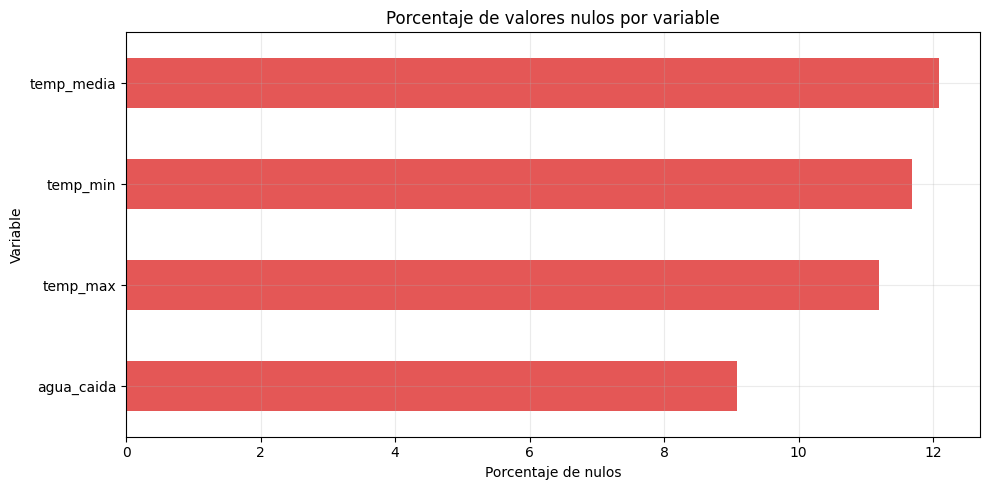

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
nulos[nulos['porcentaje'] > 0]['porcentaje'].sort_values().plot(kind='barh', ax=ax, color='#e45756')
ax.set_title('Porcentaje de valores nulos por variable')
ax.set_xlabel('Porcentaje de nulos')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()


**Analisis del grafico de nulos:**

El grafico permite priorizar las variables con mayor ausencia de datos. Al mostrar porcentajes, no solo cantidades absolutas, se facilita comparar columnas con el mismo universo de registros.

**Mini objetivo:** revisar el porcentaje de nulos climaticos por anio usando un heatmap legible con etiquetas de datos.


In [16]:
columnas_revision_nulos = ['agua_caida', 'temp_max', 'temp_min', 'temp_media']

nulos_climaticos_anio = df.groupby('anio')[columnas_revision_nulos].apply(
    lambda datos: datos.isna().mean() * 100
).T
nulos_climaticos_anio.columns = nulos_climaticos_anio.columns.astype(int)

display(nulos_climaticos_anio.round(2))


anio,2021,2022,2023,2024,2025
agua_caida,11.840,9.550,12.520,7.540,4.310
temp_max,14.950,13.110,14.360,8.980,5.170
temp_min,16.010,14.280,14.950,8.810,5.080
temp_media,16.560,15.050,15.300,9.000,5.260


**Analisis de nulos climaticos por anio:**

La tabla permite ver que la ausencia de datos no es uniforme en el tiempo. Esta revision justifica complementar el porcentaje general de nulos con una lectura temporal antes de decidir tratamientos.

**Mini objetivo:** graficar los nulos climaticos por anio como heatmap para detectar concentraciones temporales.


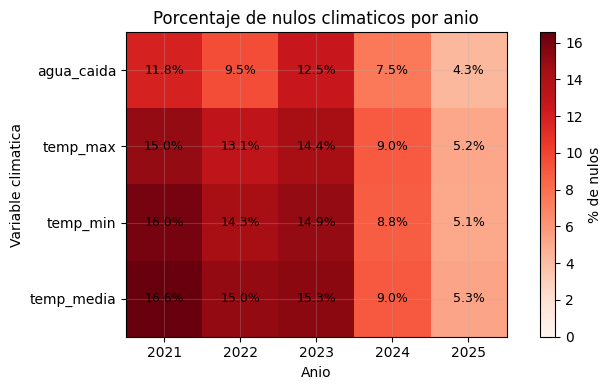

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(nulos_climaticos_anio, cmap='Reds', vmin=0)

ax.set_title('Porcentaje de nulos climaticos por anio')
ax.set_xlabel('Anio')
ax.set_ylabel('Variable climatica')
ax.set_xticks(range(len(nulos_climaticos_anio.columns)))
ax.set_xticklabels(nulos_climaticos_anio.columns)
ax.set_yticks(range(len(nulos_climaticos_anio.index)))
ax.set_yticklabels(nulos_climaticos_anio.index)

for fila in range(len(nulos_climaticos_anio.index)):
    for columna in range(len(nulos_climaticos_anio.columns)):
        valor = nulos_climaticos_anio.iloc[fila, columna]
        color_texto = 'white' if valor >= 20 else 'black'
        ax.text(columna, fila, f'{valor:.1f}%', ha='center', va='center', color=color_texto, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% de nulos')
plt.tight_layout()
plt.show()


**Analisis de nulos:**

Los nulos se concentran principalmente en variables climaticas: `agua_caida`, `temp_max`, `temp_min` y `temp_media`. El heatmap por anio permite revisar si la ausencia de datos se concentra en periodos especificos o si se mantiene relativamente estable. Esto confirma que el tratamiento de nulos debe ser diferenciado por variable. Para la fase de entendimiento se mantienen los nulos visibles; para modelamiento se evaluara imputacion o eliminacion controlada segun el objetivo del modelo.


## 2.3 Identificar Outliers

Los outliers se revisan con estadisticos, percentiles y boxplots. En datos meteorologicos, un valor extremo puede ser un evento real o un error de medicion. Por eso, en esta fase no se eliminan automaticamente: primero se detectan, se contextualizan y se dejan marcados para decidir su tratamiento en fases posteriores.


**Mini objetivo:** aplicar el metodo IQR para detectar posibles outliers en variables climaticas y geograficas relevantes.


In [18]:
variables_outliers = ['agua_caida', 'temp_max', 'temp_min', 'temp_media', 'altura']

def calcular_resumen_iqr(datos, columna):
    serie = datos[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

    return {
        'variable': columna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'outliers_iqr': outliers,
        'porcentaje_outliers': round(outliers / len(serie) * 100, 2)
    }


**Mini objetivo:** aplicar el resumen IQR a las variables seleccionadas y mostrar la tabla de resultados.


In [19]:
resumen_outliers = pd.DataFrame([
    calcular_resumen_iqr(df, columna)
    for columna in variables_outliers
])

display(resumen_outliers)


,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
0,agua_caida,0.000,0.100,0.100,-0.150,0.250,32994,19.320
1,temp_max,14.000,24.100,10.100,-1.150,39.250,740,0.440
2,temp_min,4.100,11.400,7.300,-6.850,22.350,1370,0.830
3,temp_media,9.200,16.700,7.500,-2.050,27.950,1373,0.830
4,altura,53.000,474.000,421.000,-578.500,"1,105.500",15523,8.260


**Analisis de tabla de outliers:**

El resumen cuantifica outliers por variable y permite separar el comportamiento de precipitacion del de temperatura. Esta diferencia es clave porque lluvia requiere un tratamiento especifico por su asimetria.

**Mini objetivo:** visualizar de forma general que variables presentan mayor cantidad y porcentaje de outliers segun el criterio IQR.


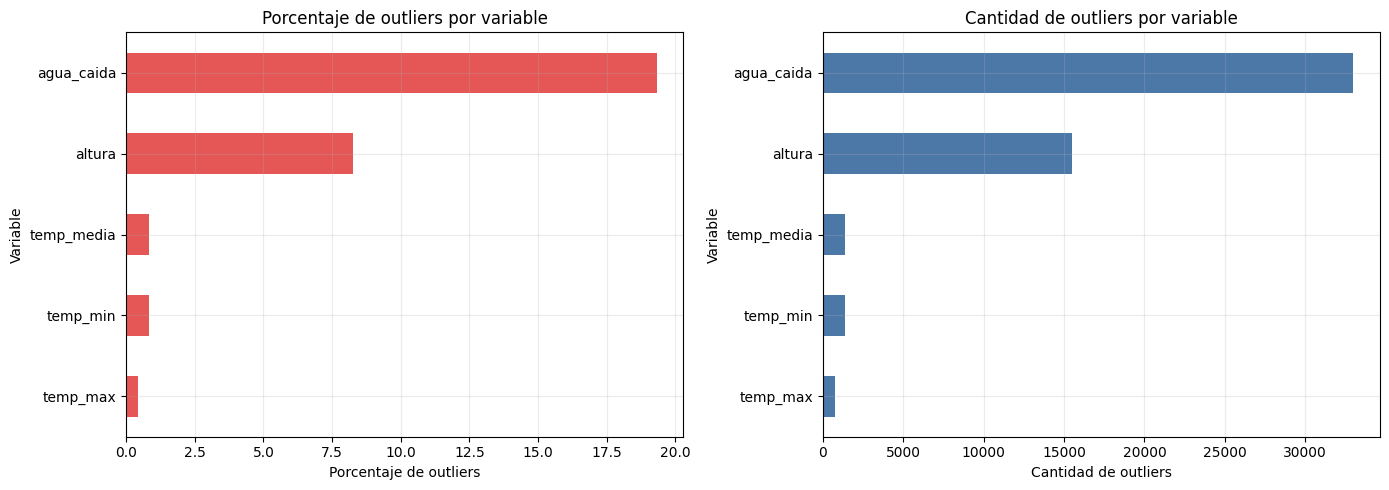

In [20]:
resumen_outliers_ordenado = resumen_outliers.sort_values('porcentaje_outliers')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='porcentaje_outliers',
    ax=axes[0], color='#e45756', legend=False
)
axes[0].set_title('Porcentaje de outliers por variable')
axes[0].set_xlabel('Porcentaje de outliers')
axes[0].set_ylabel('Variable')

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='outliers_iqr',
    ax=axes[1], color='#4c78a8', legend=False
)
axes[1].set_title('Cantidad de outliers por variable')
axes[1].set_xlabel('Cantidad de outliers')
axes[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()


**Analisis general de outliers:**

La precipitacion concentra la mayor cantidad de valores extremos, lo que es esperable por su distribucion asimetrica. Esto justifica tratar lluvia con percentil 99 y no con la misma regla usada para temperaturas.

**Mini objetivo:** construir un boxplot individual para cada variable revisada, permitiendo observar dispersion y valores extremos de manera separada.


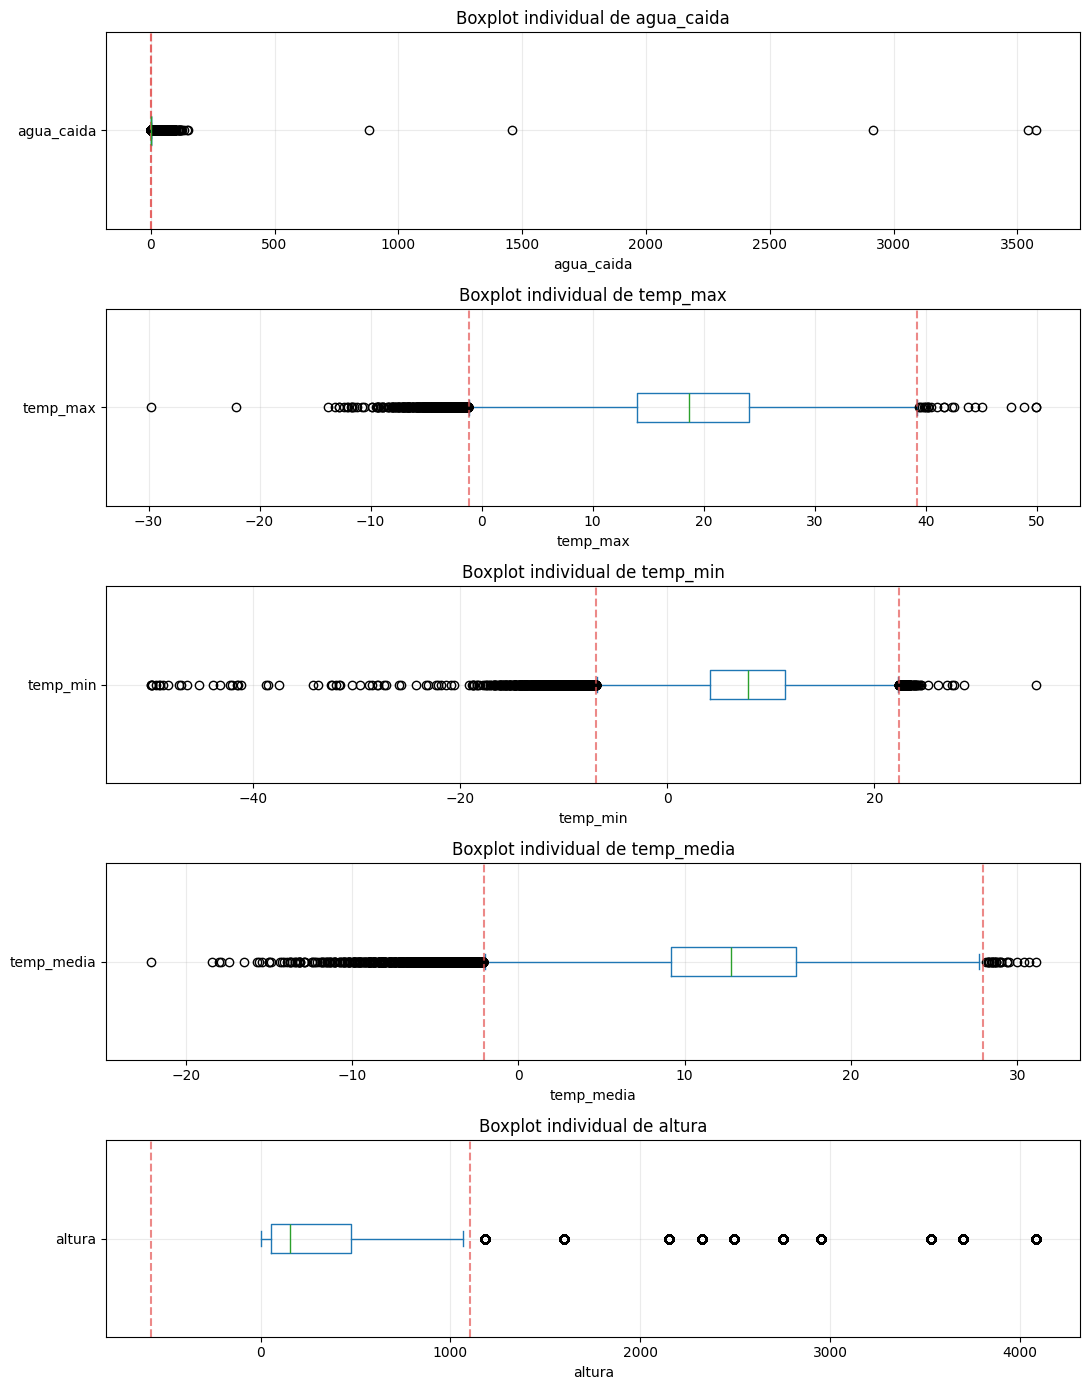

In [21]:
fig, axes = plt.subplots(len(variables_outliers), 1, figsize=(11, 14))

for ax, columna in zip(axes, variables_outliers):
    df[columna].dropna().plot(kind='box', vert=False, ax=ax)
    limites = resumen_outliers.set_index('variable').loc[columna]
    ax.axvline(limites['limite_inferior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.axvline(limites['limite_superior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.set_title(f'Boxplot individual de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis grafico de outliers:**

El grafico general permite comparar rapidamente que variables concentran mas outliers bajo el criterio IQR. Los boxplots individuales complementan esa lectura, porque muestran la forma de la distribucion y la distancia de los valores extremos respecto del rango central. En particular, `agua_caida` requiere cautela: el metodo IQR detecta muchos valores porque la serie tiene muchos ceros y una cola derecha larga. Por eso, para tratamiento se usara un criterio mas conservador basado en extremos altos, no todos los puntos IQR.


**Mini objetivo:** revisar la precipitacion diaria en escala normal, usando solo dias con lluvia para que los ceros no oculten la forma de la distribucion. Se muestra una vista completa y una vista acotada al percentil 99.


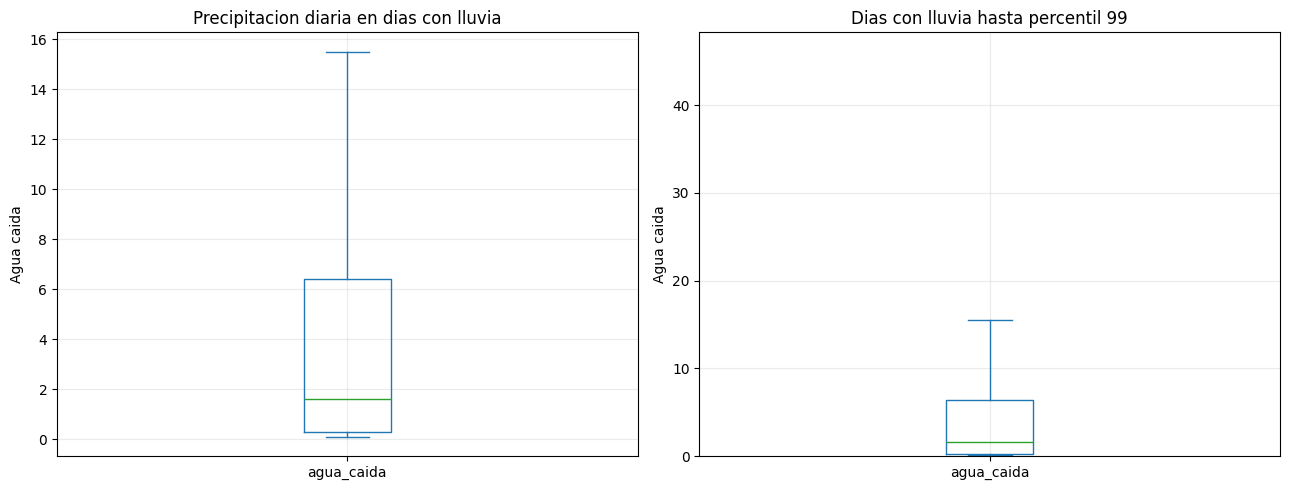

In [22]:
serie_agua = df['agua_caida'].dropna()
serie_agua_lluvia = serie_agua[serie_agua > 0]
limite_visual_agua = serie_agua_lluvia.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

serie_agua_lluvia.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Precipitacion diaria en dias con lluvia')
axes[0].set_ylabel('Agua caida')

serie_agua_lluvia.plot(kind='box', ax=axes[1], showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_ylabel('Agua caida')
axes[1].set_ylim(0, limite_visual_agua)

plt.tight_layout()
plt.show()


**Analisis de precipitacion en dias con lluvia:**

Al excluir dias con 0 mm, el boxplot muestra mejor la dispersion real de los eventos de lluvia. La vista acotada al percentil 99 mantiene escala normal y evita que pocos extremos oculten el comportamiento central.

**Mini objetivo:** revisar outliers y dispersion en temperaturas mediante boxplots.


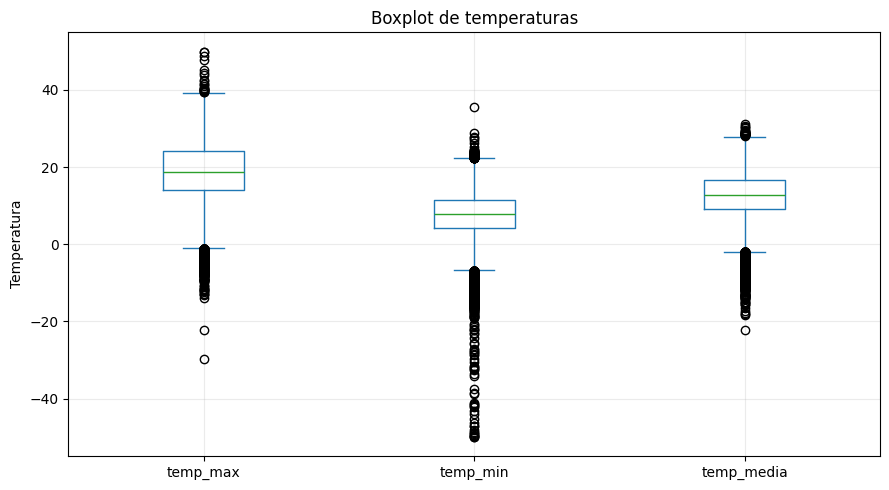

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['temp_max', 'temp_min', 'temp_media']].plot(kind='box', ax=ax)
ax.set_title('Boxplot de temperaturas')
ax.set_ylabel('Temperatura')
plt.tight_layout()
plt.show()


**Analisis de temperaturas:**

Los boxplots de temperatura muestran dispersion mas estable que la precipitacion, aunque existen valores extremos. Estos extremos deben revisarse con cuidado porque pueden representar condiciones reales o errores de registro.

**Mini objetivo:** listar los mayores registros de precipitacion para contextualizar eventos extremos antes de decidir su tratamiento.


In [24]:
top_precipitaciones = df.sort_values('agua_caida', ascending=False).head(10)[[
    'fecha', 'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'agua_caida', 'temp_media', 'altura'
]]

display(top_precipitaciones)


,fecha,codigo_estacion,nombre_estacion,nombre_region,zona_geografica,agua_caida,temp_media,altura
75680,2025-12-08,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,"3,574.300",21.400,876
133239,2025-12-07,380082,Isla Mocha Ad.,Del Biobío,Litoral,"3,541.500",16.500,6
75679,2025-12-07,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,"2,917.400",19.000,876
133240,2025-12-09,380082,Isla Mocha Ad.,Del Biobío,Litoral,"1,459.900",16.400,6
75681,2025-12-09,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,880.100,21.300,876
97400,2023-08-21,340031,"General Freire, Curicó Ad.",Del Maule,Valle,150.200,13.400,229
74780,2023-06-22,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,145.200,11.000,876
123155,2022-04-28,380018,Lonquimay,De La Araucanía,PreCordillera,136.400,NaN,912
138886,2021-05-31,390043,Corral ESSAL,De Los Ríos,Litoral,126.800,13.900,24
102878,2023-08-21,340066,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,121.300,NaN,81


**Analisis de outliers:**

La variable `agua_caida` es altamente asimetrica: muchos dias tienen precipitacion cero o baja, mientras que pocos registros concentran valores muy altos. Por eso se revisa la distribucion en escala normal con una vista completa y una vista acotada al percentil 99. Los valores mas altos deben ser tratados con especial cuidado, ya que pueden representar eventos climaticos excepcionales o posibles errores de registro.


## 2.4 Transformaciones

En esta fase se realizan transformaciones iniciales orientadas al entendimiento de datos. No se aplicara aun escalamiento ni preparacion definitiva para modelos, porque eso corresponde a la Fase 3. Aqui se verifica la limpieza inicial de textos, se preparan codificaciones simples para analisis y se definen criterios de tratamiento para nulos y outliers.


### 2.4.1 A numericos (Encoder)

Las variables categoricas no pueden ser usadas directamente en muchos modelos matematicos. Como primer paso, se crean codigos numericos para region, zona geografica y macrozona. La macrozona se construye agrupando regiones de Chile en grandes areas climaticas y territoriales: Norte Grande, Norte Chico, Zona Central, Zona Sur y Zona Austral. Esta variable permite comparar patrones de forma mas clara que usando solo regiones individuales.


**Mini objetivo:** crear una copia de trabajo, agregar macrozonas y codificar variables categoricas para analisis exploratorio sin alterar el dataset base.


In [25]:
df_eda = df.copy()

macrozonas_orden = ['Norte Grande', 'Norte Chico', 'Zona Central', 'Zona Sur', 'Zona Austral']

def asignar_macrozona(region):
    if region in [15, 1, 2]:
        return 'Norte Grande'
    if region in [3, 4]:
        return 'Norte Chico'
    if region in [5, 13, 6, 7, 16, 8]:
        return 'Zona Central'
    if region in [9, 14, 10]:
        return 'Zona Sur'
    if region in [11, 12]:
        return 'Zona Austral'
    return 'Sin clasificar'

df_eda['macrozona'] = df_eda['region'].apply(asignar_macrozona)
df_eda['macrozona'] = pd.Categorical(df_eda['macrozona'], categories=macrozonas_orden, ordered=True)


**Mini objetivo:** codificar variables categoricas para correlaciones exploratorias y revisar una muestra de la codificacion.


In [26]:
df_eda['region_cod'] = df_eda['nombre_region'].astype('category').cat.codes
df_eda['zona_geografica_cod'] = df_eda['zona_geografica'].astype('category').cat.codes
df_eda['macrozona_cod'] = df_eda['macrozona'].cat.codes

columnas_codificacion = [
    'region', 'nombre_region', 'macrozona', 'region_cod',
    'zona_geografica', 'zona_geografica_cod', 'macrozona_cod'
]
codificacion = df_eda[columnas_codificacion].drop_duplicates()

display(codificacion.sort_values(['macrozona', 'region', 'zona_geografica']).head(15))


,region,nombre_region,macrozona,region_cod,zona_geografica,zona_geografica_cod,macrozona_cod
8400,1,Tarapacá,Norte Grande,14,Cordillera,0,0
9496,1,Tarapacá,Norte Grande,14,Litoral,1,0
16796,2,Antofagasta,Norte Grande,0,Cordillera,0,0
14974,2,Antofagasta,Norte Grande,0,Litoral,1,0
13148,2,Antofagasta,Norte Grande,0,PreCordillera,2,0
0,15,Arica y Parinacota,Norte Grande,1,Cordillera,0,0
1096,15,Arica y Parinacota,Norte Grande,1,Litoral,1,0
2922,15,Arica y Parinacota,Norte Grande,1,PreCordillera,2,0
25053,3,Atacama,Norte Chico,2,Secano Costero,3,1
22131,3,Atacama,Norte Chico,2,Valle,5,1


**Analisis de codificacion categorica:**

La codificacion transforma regiones, zonas y macrozonas en variables numericas sin perder la categoria original. Esto permite usar las variables territoriales en correlaciones y modelos posteriores.

### 2.4.2 Tratamiento de Nulos

Para evitar decisiones apresuradas, el tratamiento definitivo de nulos se aplicara segun el objetivo del modelo. En esta fase se define una estrategia preliminar: mantener nulos para diagnostico, excluirlos solo en graficos que requieren valores validos y proponer imputacion controlada para fases posteriores.


**Mini objetivo:** documentar la estrategia preliminar de tratamiento de nulos segun el tipo de variable.


In [27]:
estrategia_nulos = pd.DataFrame([
    {'variable': 'agua_caida', 'estrategia_preliminar': 'No asumir cero si esta nulo; analizar por estacion, fecha y region antes de imputar.'},
    {'variable': 'temp_max', 'estrategia_preliminar': 'Imputacion posible con mediana por estacion/mes o mediana general si se modela.'},
    {'variable': 'temp_min', 'estrategia_preliminar': 'Imputacion posible con mediana por estacion/mes o mediana general si se modela.'},
    {'variable': 'temp_media', 'estrategia_preliminar': 'Puede recalcularse si temp_max y temp_min existen; si no, imputacion controlada.'},
    {'variable': 'categoricas', 'estrategia_preliminar': 'Usar moda solo si aparecen nulos; actualmente las variables principales estan completas tras corregir carga.'},
])

display(estrategia_nulos)


,variable,estrategia_preliminar
0,agua_caida,No asumir cero si esta nulo; analizar por esta...
1,temp_max,Imputacion posible con mediana por estacion/me...
2,temp_min,Imputacion posible con mediana por estacion/me...
3,temp_media,Puede recalcularse si temp_max y temp_min exis...
4,categoricas,Usar moda solo si aparecen nulos; actualmente ...


**Analisis de estrategia de nulos:**

La estrategia separa variables climaticas, territoriales y temporales. Esta distincion es importante porque no todos los nulos tienen el mismo significado ni deben recibir el mismo tratamiento.

### 2.4.3 Tratamiento de Outliers

En esta etapa los outliers no se eliminan directamente. Para variables climaticas se crean banderas que permiten analizarlos. En el caso especifico de `agua_caida`, los extremos altos pueden distorsionar promedios, correlaciones y graficos; por ello se crea una version tratada de la variable, reemplazando solo los valores extremadamente altos por una mediana robusta. El dato original se conserva para trazabilidad.


**Mini objetivo:** crear banderas de outliers para analizarlos sin eliminarlos automaticamente.


In [28]:
def marcar_outliers_iqr(datos, columna):
    serie = datos[columna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)


**Mini objetivo:** aplicar banderas de outliers sobre variables clave y mostrar un resumen compacto.


In [29]:
df_eda['outlier_agua_caida_iqr'] = marcar_outliers_iqr(df_eda, 'agua_caida')
df_eda['outlier_temp_media_iqr'] = marcar_outliers_iqr(df_eda, 'temp_media')

resumen_banderas_outliers = df_eda[
    ['outlier_agua_caida_iqr', 'outlier_temp_media_iqr']
].sum().to_frame('cantidad')
resumen_banderas_outliers['porcentaje'] = (
    resumen_banderas_outliers['cantidad'] / len(df_eda) * 100
).round(2)

display(resumen_banderas_outliers)


,cantidad,porcentaje
outlier_agua_caida_iqr,32994,17.560
outlier_temp_media_iqr,1373,0.730


**Analisis de banderas de outliers:**

Las banderas permiten marcar registros extremos sin eliminarlos. Esta estrategia conserva trazabilidad y facilita comparar el dato original con variables tratadas.

**Mini objetivo:** tratar los extremos altos de lluvia creando `agua_caida_tratada`, sin sobrescribir la precipitacion original.


In [30]:
umbral_extremo_lluvia = df_eda['agua_caida'].quantile(0.99)
mediana_lluvia_no_extrema = df_eda.loc[
    (df_eda['agua_caida'] > 0) & (df_eda['agua_caida'] <= umbral_extremo_lluvia),
    'agua_caida'
].median()


**Mini objetivo:** aplicar el tratamiento solo a valores superiores al percentil 99, conservando la variable original.


In [31]:
df_eda['outlier_extremo_agua_caida'] = df_eda['agua_caida'] > umbral_extremo_lluvia

df_eda['agua_caida_tratada'] = df_eda['agua_caida'].copy()
df_eda.loc[
    df_eda['outlier_extremo_agua_caida'],
    'agua_caida_tratada'
] = mediana_lluvia_no_extrema


**Mini objetivo:** resumir el umbral usado, la mediana de reemplazo y la cantidad de registros tratados.


In [32]:
resumen_tratamiento_lluvia = pd.DataFrame([
    {'indicador': 'umbral_extremo_lluvia_p99', 'valor': umbral_extremo_lluvia},
    {'indicador': 'mediana_reemplazo_lluvia', 'valor': mediana_lluvia_no_extrema},
    {'indicador': 'registros_reemplazados', 'valor': int(df_eda['outlier_extremo_agua_caida'].sum())},
    {'indicador': 'porcentaje_reemplazado', 'valor': round(df_eda['outlier_extremo_agua_caida'].mean() * 100, 3)},
])

display(resumen_tratamiento_lluvia)


,indicador,valor
0,umbral_extremo_lluvia_p99,27.800
1,mediana_reemplazo_lluvia,1.400
2,registros_reemplazados,"1,705.000"
3,porcentaje_reemplazado,0.908


**Analisis del tratamiento de extremos de lluvia:**

El resumen documenta el umbral usado, el valor de reemplazo y cuantas observaciones fueron tratadas. Esto hace auditable la creacion de `agua_caida_tratada` y evita modificar la variable original.

**Mini objetivo:** comparar visualmente la precipitacion antes y despues del tratamiento de extremos altos, usando dias con lluvia para evitar que los ceros dominen el grafico.


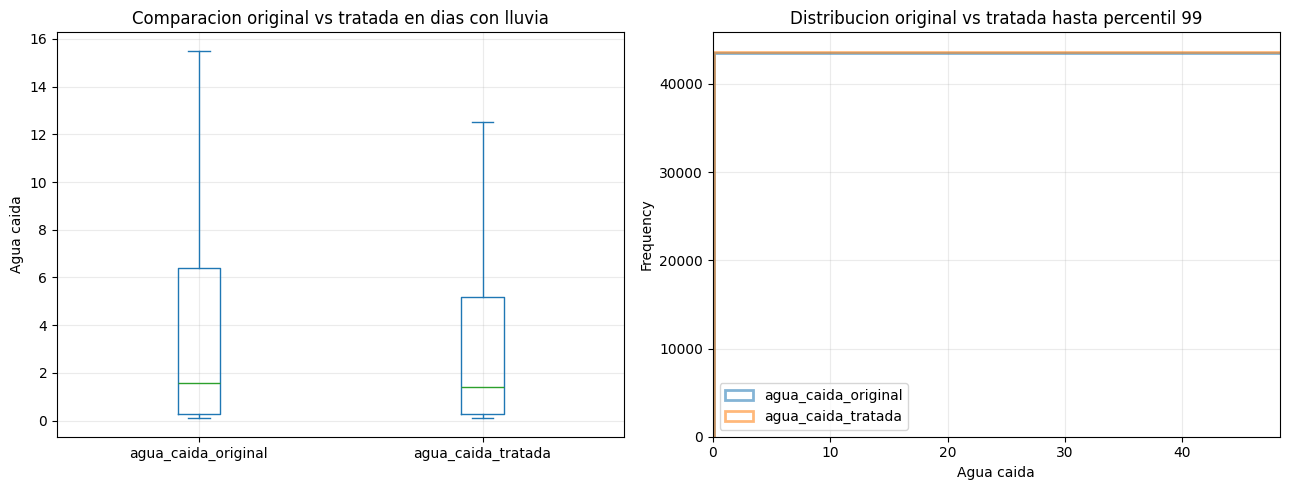

In [33]:
comparacion_lluvia = pd.DataFrame({
    'agua_caida_original': df_eda['agua_caida'],
    'agua_caida_tratada': df_eda['agua_caida_tratada']
})

comparacion_lluvia_positiva = comparacion_lluvia[comparacion_lluvia['agua_caida_original'] > 0]
limite_visual_comparacion = comparacion_lluvia_positiva.quantile(0.99).max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparacion_lluvia_positiva.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Comparacion original vs tratada en dias con lluvia')
axes[0].set_ylabel('Agua caida')

comparacion_lluvia_positiva.plot(kind='hist', bins=50, alpha=0.55, histtype='step', linewidth=2, ax=axes[1])
axes[1].set_title('Distribucion original vs tratada hasta percentil 99')
axes[1].set_xlabel('Agua caida')
axes[1].set_xlim(0, limite_visual_comparacion)

plt.tight_layout()
plt.show()


**Analisis del tratamiento de lluvia:**

El tratamiento reemplaza solo los extremos superiores de `agua_caida`, definidos por percentil 99, usando la mediana de dias con lluvia no extrema. Esta decision reduce la distorsion de promedios y correlaciones, pero conserva la variable original para auditoria y comparacion. No se usa la mediana general porque en lluvia diaria suele ser 0, lo que transformaria eventos de lluvia en dias sin precipitacion.


**Analisis de transformaciones iniciales:**

Las transformaciones realizadas permiten continuar el analisis sin perder trazabilidad. La correccion de texto mejora la interpretacion de regiones y estaciones en graficos, y la macrozona permite resumir regiones en grupos territoriales mas interpretables. Los codigos numericos permiten estudiar correlaciones exploratorias, pero no reemplazan una preparacion formal para modelamiento. Los outliers quedan marcados y, para lluvia extrema, se crea una variable tratada que reduce distorsion sin perder el registro original.


## 2.5 Analisis estadisticos basicos

Se calculan estadisticos descriptivos para comprender rangos, dispersion y comportamiento general de las variables numericas. Desde esta seccion, los resumenes de precipitacion usan `agua_caida_tratada` para evitar que pocos extremos altos dominen las medidas. Luego se agregan resultados por region, macrozona y zona geografica para obtener una lectura territorial en distintos niveles de detalle.


**Mini objetivo:** calcular estadisticos descriptivos de las variables numericas base, comparando lluvia original y lluvia tratada.


In [34]:
variables_numericas_base = ['altura', 'latitud', 'longitud', 'agua_caida', 'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media']
estadisticos_base = df_eda[variables_numericas_base].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

display(estadisticos_base)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
altura,"187,876.000",441.946,741.220,5.000,6.000,11.000,53.000,156.000,474.000,"2,326.000","3,700.000","4,084.000"
latitud,"187,876.000",-35.851,8.857,-62.192,-54.932,-53.130,-40.084,-33.728,-32.222,-19.277,-18.200,-17.595
longitud,"187,876.000",-71.691,4.176,-109.433,-78.833,-73.735,-72.344,-71.187,-70.683,-69.295,-67.616,-58.980
agua_caida,"170,813.000",1.494,15.673,0.000,0.000,0.000,0.000,0.000,0.100,8.600,27.800,"3,574.300"
agua_caida_tratada,"170,813.000",1.011,3.340,0.000,0.000,0.000,0.000,0.000,0.100,7.000,19.000,27.800
temp_max,"166,829.000",18.915,7.305,-29.800,0.800,6.900,14.000,18.700,24.100,31.000,34.000,49.900
temp_min,"165,911.000",7.657,5.505,-49.900,-5.800,-1.300,4.100,7.800,11.400,16.500,19.800,35.600
temp_media,"165,163.000",12.755,5.603,-22.100,-1.600,3.100,9.200,12.800,16.700,21.600,23.800,31.100


**Analisis estadistico base:**

Los estadisticos muestran que la precipitacion tiene alta dispersion y muchos valores bajos, mientras que las temperaturas presentan un comportamiento mas continuo. Esto anticipa que los modelos de lluvia seran mas dificiles que los de temperatura.

**Mini objetivo:** resumir precipitacion y temperatura por region para detectar patrones territoriales.


In [35]:
estadisticos_region = df_eda.groupby('nombre_region').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_region)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
nombre_region,,,,,
De Los Lagos,16434,9,2.875,"40,456.400",10.457
Aysén del Gral. Carlos Ibáñez del Campo,10437,6,2.811,"23,869.000",8.831
De Los Ríos,6569,4,2.499,"13,528.900",11.342
De La Araucanía,10956,6,1.827,"17,293.900",11.399
Del Biobío,8764,5,1.586,"12,551.500",12.912
De Ñuble,4383,3,1.293,"5,422.900",13.047
Magallanes y de la Antártica Chilena,19347,11,1.128,"21,315.800",5.769
Del Maule,5456,3,0.976,"5,060.500",14.223
Del Libertador Gral. Bernardo O'Higgins,9092,5,0.597,"4,900.800",13.775


**Analisis por region:**

El resumen regional evidencia diferencias climaticas importantes entre territorios. Estas diferencias respaldan el uso de variables geograficas como predictoras y la necesidad de analizar resultados por zona.

**Mini objetivo:** resumir precipitacion y temperatura por zona geografica para comparar comportamientos climaticos.


In [36]:
estadisticos_zona = df_eda.groupby('zona_geografica').agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).sort_values('agua_promedio', ascending=False).round(3)

display(estadisticos_zona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
zona_geografica,,,,,
Litoral,64838,36,1.289,"76,573.600",12.240
Valle,86617,51,1.054,"84,139.100",13.001
Secano Interior,2557,2,0.825,"1,886.200",13.143
PreCordillera,19060,11,0.447,"7,114.000",14.153
Cordillera,7527,5,0.274,"1,730.300",9.473
Secano Costero,7277,4,0.182,"1,284.000",14.021


**Analisis por zona geografica:**

La agrupacion por zona reduce ruido respecto de la region individual y permite observar patrones climaticos mas interpretables. Esto ayuda a conectar el analisis con decisiones territoriales.

**Mini objetivo:** resumir precipitacion y temperatura por macrozona para analizar patrones territoriales de mayor escala.


In [37]:
estadisticos_macrozona = df_eda.groupby('macrozona', observed=True).agg(
    registros=('codigo_estacion', 'size'),
    estaciones=('codigo_estacion', 'nunique'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media_promedio=('temp_media', 'mean')
).round(3)

display(estadisticos_macrozona)


,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
macrozona,,,,,
Norte Grande,22131,13,0.086,"1,739.400",16.294
Norte Chico,21410,13,0.122,"2,337.800",15.397
Zona Central,80592,47,0.695,"52,186.000",14.015
Zona Sur,33959,19,2.462,"71,279.200",10.919
Zona Austral,29784,17,1.650,"45,184.800",6.696


**Analisis por macrozona:**

La macrozona resume el comportamiento territorial en categorias amplias. Esta variable es util para graficos, correlaciones, modelos y para explicar resultados de forma clara frente a la rubrica.

**Mini objetivo:** graficar precipitacion y temperatura promedio por region para facilitar la comparacion visual.


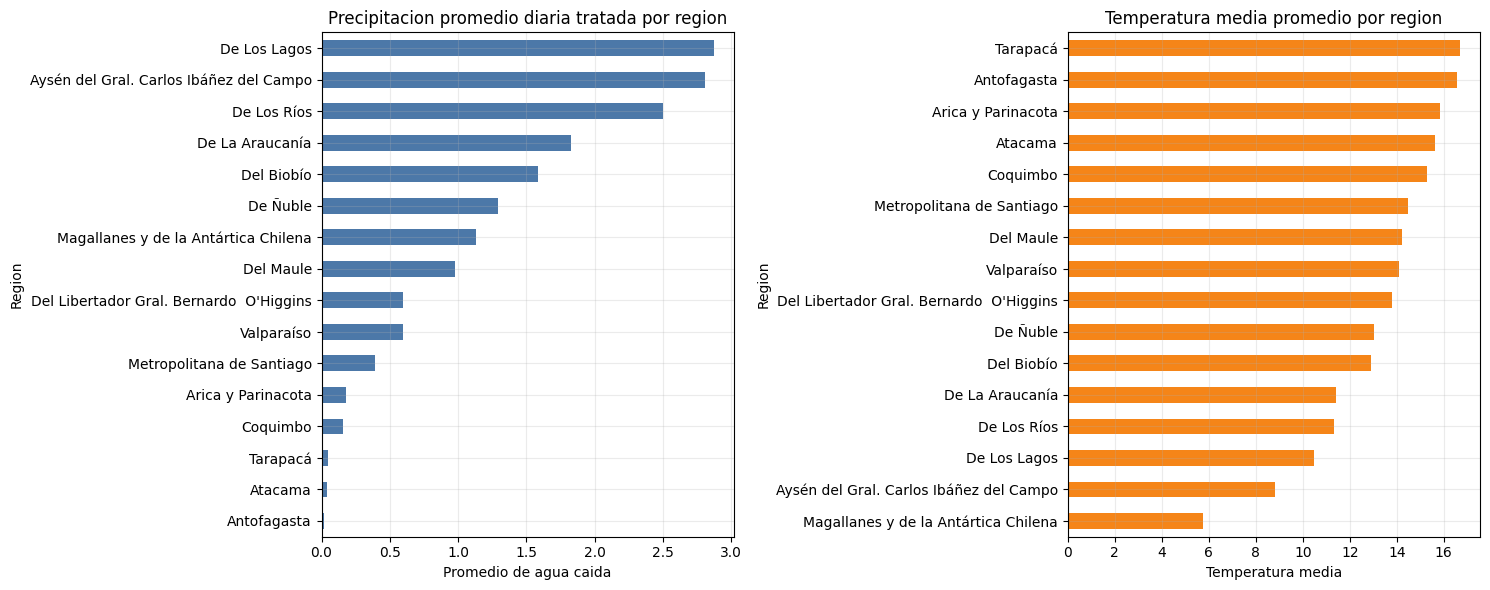

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

estadisticos_region['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por region')
axes[0].set_xlabel('Promedio de agua caida')
axes[0].set_ylabel('Region')

estadisticos_region['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por region')
axes[1].set_xlabel('Temperatura media')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis grafico por region:**

La comparacion visual confirma que precipitacion y temperatura no se distribuyen igual entre regiones. Esto indica que la ubicacion geografica tiene valor explicativo para el modelamiento.

**Mini objetivo:** graficar precipitacion y temperatura promedio por zona geografica para facilitar la comparacion visual.


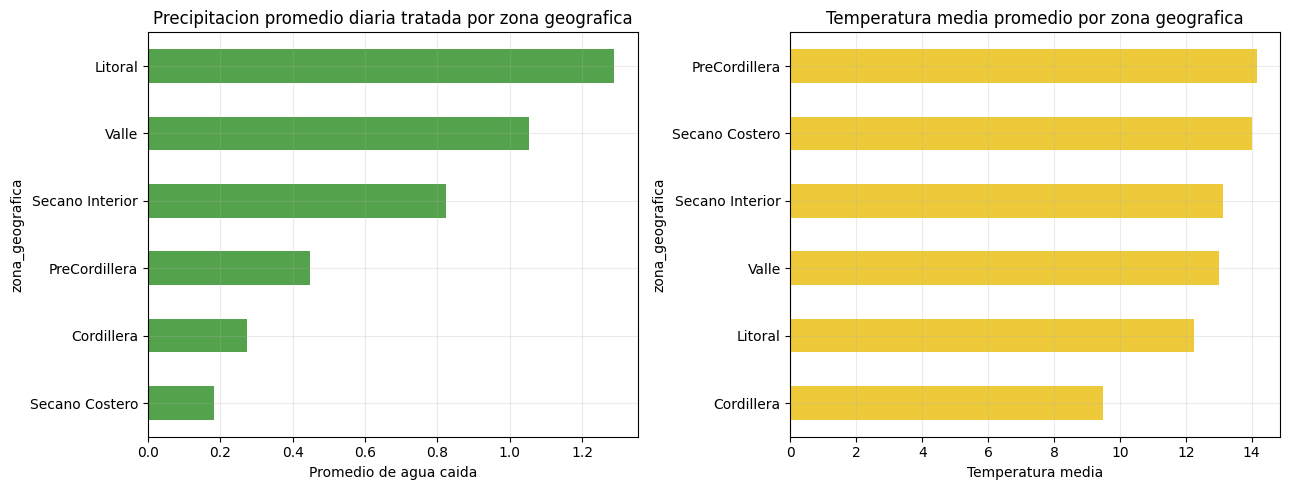

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_zona['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#54a24b')
axes[0].set_title('Precipitacion promedio diaria tratada por zona geografica')
axes[0].set_xlabel('Promedio de agua caida')

estadisticos_zona['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#eeca3b')
axes[1].set_title('Temperatura media promedio por zona geografica')
axes[1].set_xlabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis grafico por zona:**

Las zonas permiten distinguir gradientes climaticos sin saturar el grafico con demasiadas categorias. Esta lectura territorial fortalece las hipotesis sobre macrozonas y estacionalidad.

**Mini objetivo:** graficar precipitacion y temperatura promedio por macrozona para comparar el comportamiento norte-centro-sur de forma agregada.


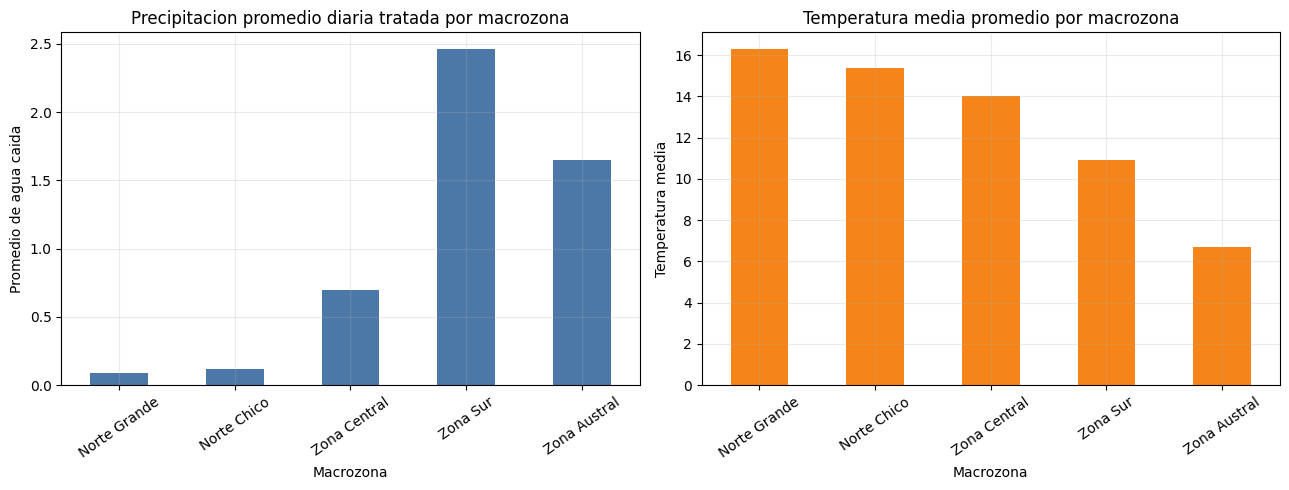

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_macrozona['agua_promedio'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por macrozona')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Promedio de agua caida')
axes[0].tick_params(axis='x', rotation=35)

estadisticos_macrozona['temp_media_promedio'].plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis grafico por macrozona:**

La macrozona muestra diferencias claras en precipitacion y temperatura promedio. Esta evidencia justifica incluir `macrozona_cod` en los modelos como variable predictora codificada.

**Mini objetivo:** usar boxplots por macrozona para observar dispersion y diferencias territoriales. En precipitacion se consideran solo dias con lluvia para que el grafico sea interpretable.


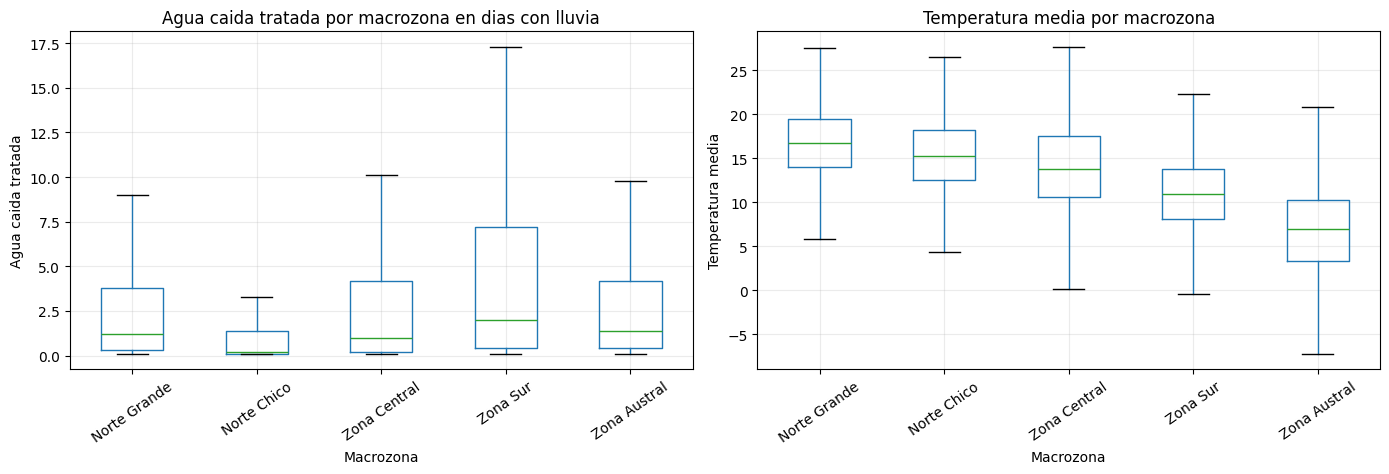

In [41]:
macrozona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

macrozona_lluvia.boxplot(column='agua_caida_tratada', by='macrozona', ax=axes[0], rot=35, showfliers=False)
axes[0].set_title('Agua caida tratada por macrozona en dias con lluvia')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Agua caida tratada')

df_eda.boxplot(column='temp_media', by='macrozona', ax=axes[1], rot=35, showfliers=False)
axes[1].set_title('Temperatura media por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por macrozona:**

La macrozona permite leer los datos de manera mas clara que una comparacion con muchas regiones. Esta agrupacion ayuda a distinguir patrones climaticos amplios entre norte, centro, sur y extremo austral, manteniendo una interpretacion territorial comprensible para el analisis de negocio.


**Mini objetivo:** observar distribuciones de precipitacion tratada y temperaturas para entender su forma estadistica.


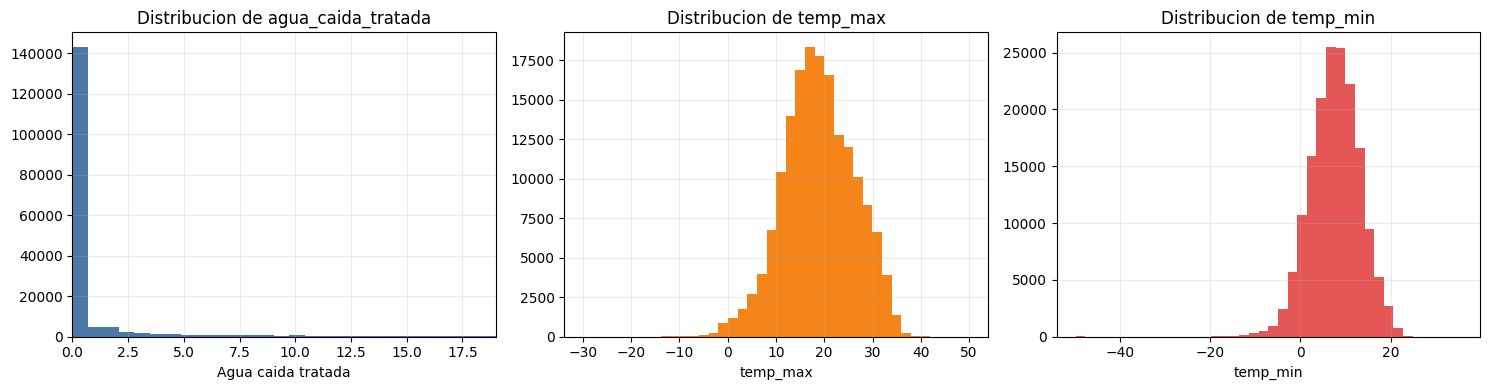

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

serie_lluvia_tratada = df_eda['agua_caida_tratada'].dropna()
serie_lluvia_tratada.hist(bins=40, ax=axes[0], color='#4c78a8')
axes[0].set_title('Distribucion de agua_caida_tratada')
axes[0].set_xlabel('Agua caida tratada')
axes[0].set_xlim(0, serie_lluvia_tratada.quantile(0.99))

for columna, ax, color in zip(['temp_max', 'temp_min'], axes[1:], ['#f58518', '#e45756']):
    df_eda[columna].dropna().hist(bins=40, ax=ax, color=color)
    ax.set_title(f'Distribucion de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis estadistico:**

Los estadisticos y graficos muestran que la precipitacion, incluso tratada, no se distribuye de forma normal: predominan valores bajos y pocos eventos concentran montos altos. Las temperaturas presentan una distribucion mas continua y son mas adecuadas para analisis de correlacion directa. Las comparaciones por region, macrozona y zona permiten comenzar a validar hipotesis territoriales en distintos niveles de detalle.


## 2.6 Matriz de Correlacion

La matriz de correlacion permite analizar relaciones lineales entre variables numericas. No implica causalidad, pero ayuda a identificar variables que podrian aportar informacion en modelos predictivos.


**Mini objetivo:** calcular la matriz de correlacion inicial y graficarla con etiquetas numericas para facilitar su interpretacion.


In [43]:
def graficar_matriz_correlacion(correlacion, titulo, figsize=(8, 6), rotacion=45):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)

    ax.set_xticks(range(len(correlacion.columns)))
    ax.set_yticks(range(len(correlacion.index)))
    ax.set_xticklabels(correlacion.columns, rotation=rotacion, ha='right')
    ax.set_yticklabels(correlacion.index)
    ax.set_title(titulo)

    for fila in range(len(correlacion.index)):
        for columna in range(len(correlacion.columns)):
            valor = correlacion.iloc[fila, columna]
            color_texto = 'white' if abs(valor) >= 0.60 else 'black'
            ax.text(columna, fila, f'{valor:.2f}', ha='center', va='center', fontsize=8, color=color_texto)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


**Mini objetivo:** calcular la correlacion inicial sobre variables numericas principales y mostrar la tabla resultante.


In [44]:
columnas_correlacion_inicial = [
    'altura', 'latitud', 'longitud', 'mes', 'agua_caida_tratada',
    'temp_max', 'temp_min', 'temp_media'
]

corr_inicial = df_eda[columnas_correlacion_inicial].corr(numeric_only=True)
display(corr_inicial.round(3))


,altura,latitud,longitud,mes,agua_caida_tratada,temp_max,temp_min,temp_media
altura,1.000,0.393,0.182,-0.002,-0.092,0.074,-0.161,-0.031
latitud,0.393,1.000,-0.062,-0.002,-0.168,0.518,0.487,0.559
longitud,0.182,-0.062,1.000,-0.001,-0.084,-0.095,-0.234,-0.184
mes,-0.002,-0.002,-0.001,1.000,0.007,-0.136,-0.150,-0.157
agua_caida_tratada,-0.092,-0.168,-0.084,0.007,1.000,-0.240,-0.048,-0.167
temp_max,0.074,0.518,-0.095,-0.136,-0.240,1.000,0.582,0.901
temp_min,-0.161,0.487,-0.234,-0.150,-0.048,0.582,1.000,0.859
temp_media,-0.031,0.559,-0.184,-0.157,-0.167,0.901,0.859,1.000


**Analisis de matriz inicial:**

La matriz inicial muestra relaciones entre variables base antes de incorporar nuevas variables derivadas. Esta comparacion sirve como linea base para evaluar si las transformaciones agregan informacion.

**Mini objetivo:** graficar la matriz inicial para facilitar la lectura de relaciones positivas y negativas.


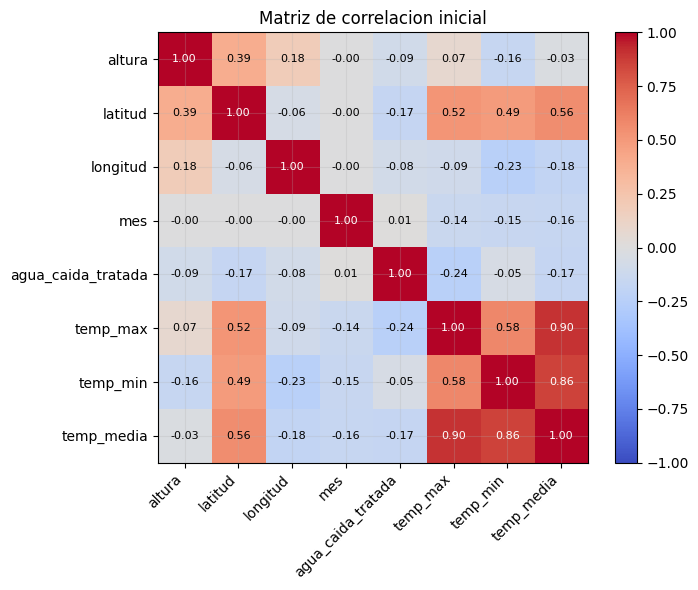

In [45]:
graficar_matriz_correlacion(
    corr_inicial,
    'Matriz de correlacion inicial',
    figsize=(8, 6),
    rotacion=45
)


**Analisis de correlacion inicial:**

Se espera observar una relacion fuerte entre las variables de temperatura, especialmente entre `temp_media`, `temp_max` y `temp_min`. Las variables geograficas como `latitud` y `altura` pueden mostrar relacion con temperatura, lo que es consistente con el comportamiento climatico esperado. La variable `agua_caida_tratada` puede presentar correlaciones mas debiles porque la lluvia diaria suele depender de patrones no lineales y eventos puntuales.


## 2.7 Patrones/comportamientos detectados

En esta seccion se revisan patrones temporales, geograficos y climaticos mediante graficos. Cada grafico responde a una pregunta concreta: como cambia la lluvia por mes, como cambia la temperatura, que zonas concentran mas precipitacion y como se relacionan ubicacion y clima.


**Mini objetivo:** construir una serie mensual separada por anio para observar evolucion temporal de precipitacion y temperatura sin mezclar periodos distintos.

In [46]:
mensual = df_eda.assign(
    periodo=df_eda['fecha'].dt.to_period('M').dt.to_timestamp()
).groupby(['anio', 'mes', 'periodo']).agg(
    agua_total=('agua_caida_tratada', 'sum'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    temp_media=('temp_media', 'mean')
).reset_index()

anios_disponibles = sorted(mensual['anio'].unique())
meses = range(1, 13)

**Mini objetivo:** graficar la evolucion mensual de precipitacion total y temperatura media, mostrando una linea independiente para cada anio.

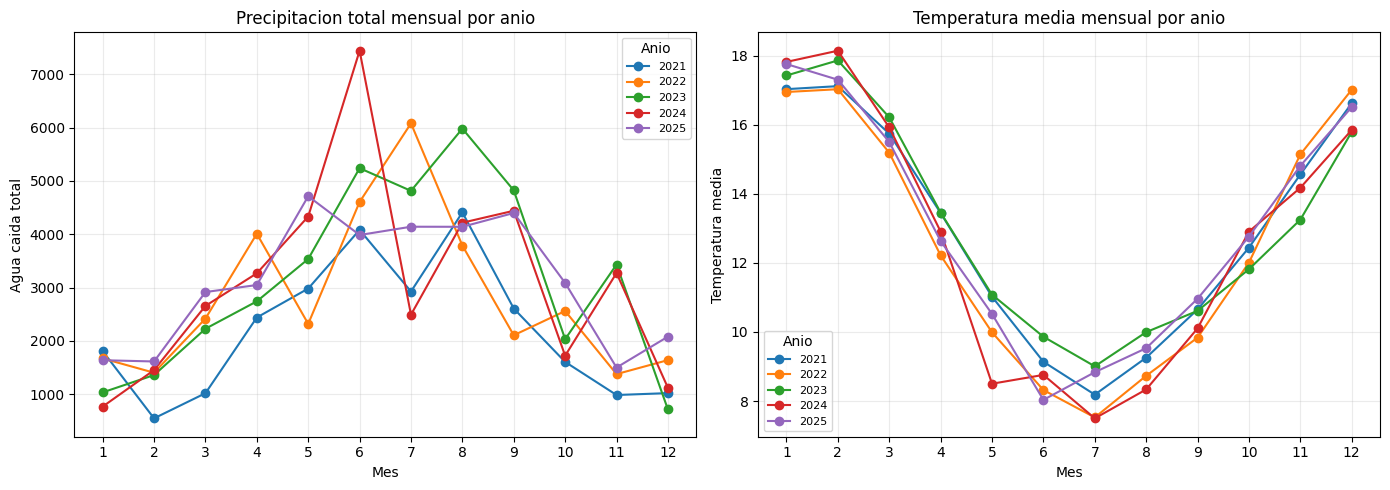

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for anio in anios_disponibles:
    datos_anio = mensual[mensual['anio'] == anio]
    axes[0].plot(datos_anio['mes'], datos_anio['agua_total'], marker='o', label=str(anio))
    axes[1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', label=str(anio))

axes[0].set_title('Precipitacion total mensual por anio')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Agua caida total')

axes[1].set_title('Temperatura media mensual por anio')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura media')

for ax in axes:
    ax.set_xticks(meses)
    ax.legend(title='Anio', fontsize=8)

plt.tight_layout()
plt.show()

**Analisis mensual por anio:**

Separar las lineas por anio permite comparar si la estacionalidad se repite o cambia entre 2021, 2022, 2023, 2024 y 2025. Esta vista es mas trazable que un promedio general por mes, porque muestra diferencias interanuales y evita ocultar anios con comportamientos particulares.

**Mini objetivo:** preparar una tabla `anio-mes` para graficar la estacionalidad anual en lluvia promedio y temperatura media mediante paneles por anio.

In [48]:
por_anio_mes = mensual[[
    'anio', 'mes', 'agua_promedio', 'agua_total', 'temp_media'
]].copy()

display(por_anio_mes.head(12))

,anio,mes,agua_promedio,agua_total,temp_media
0,2021,1,0.710,"1,807.000",17.036
1,2021,2,0.241,545.800,17.123
2,2021,3,0.388,"1,017.200",15.747
3,2021,4,0.926,"2,437.400",13.448
4,2021,5,1.051,"2,980.400",11.024
5,2021,6,1.522,"4,081.700",9.138
6,2021,7,1.127,"2,925.100",8.185
7,2021,8,1.643,"4,409.900",9.257
8,2021,9,0.998,"2,606.000",10.653
9,2021,10,0.607,"1,604.500",12.446


**Analisis de tabla anio-mes:**

La tabla deja trazable la agregacion usada para los graficos siguientes. Al conservar `anio` y `mes` por separado, se evita mezclar todos los a?os en un promedio unico y se puede comparar la estacionalidad de cada periodo.

**Mini objetivo:** mostrar graficos mensuales separados por cada anio para revisar estacionalidad sin mezclar periodos.

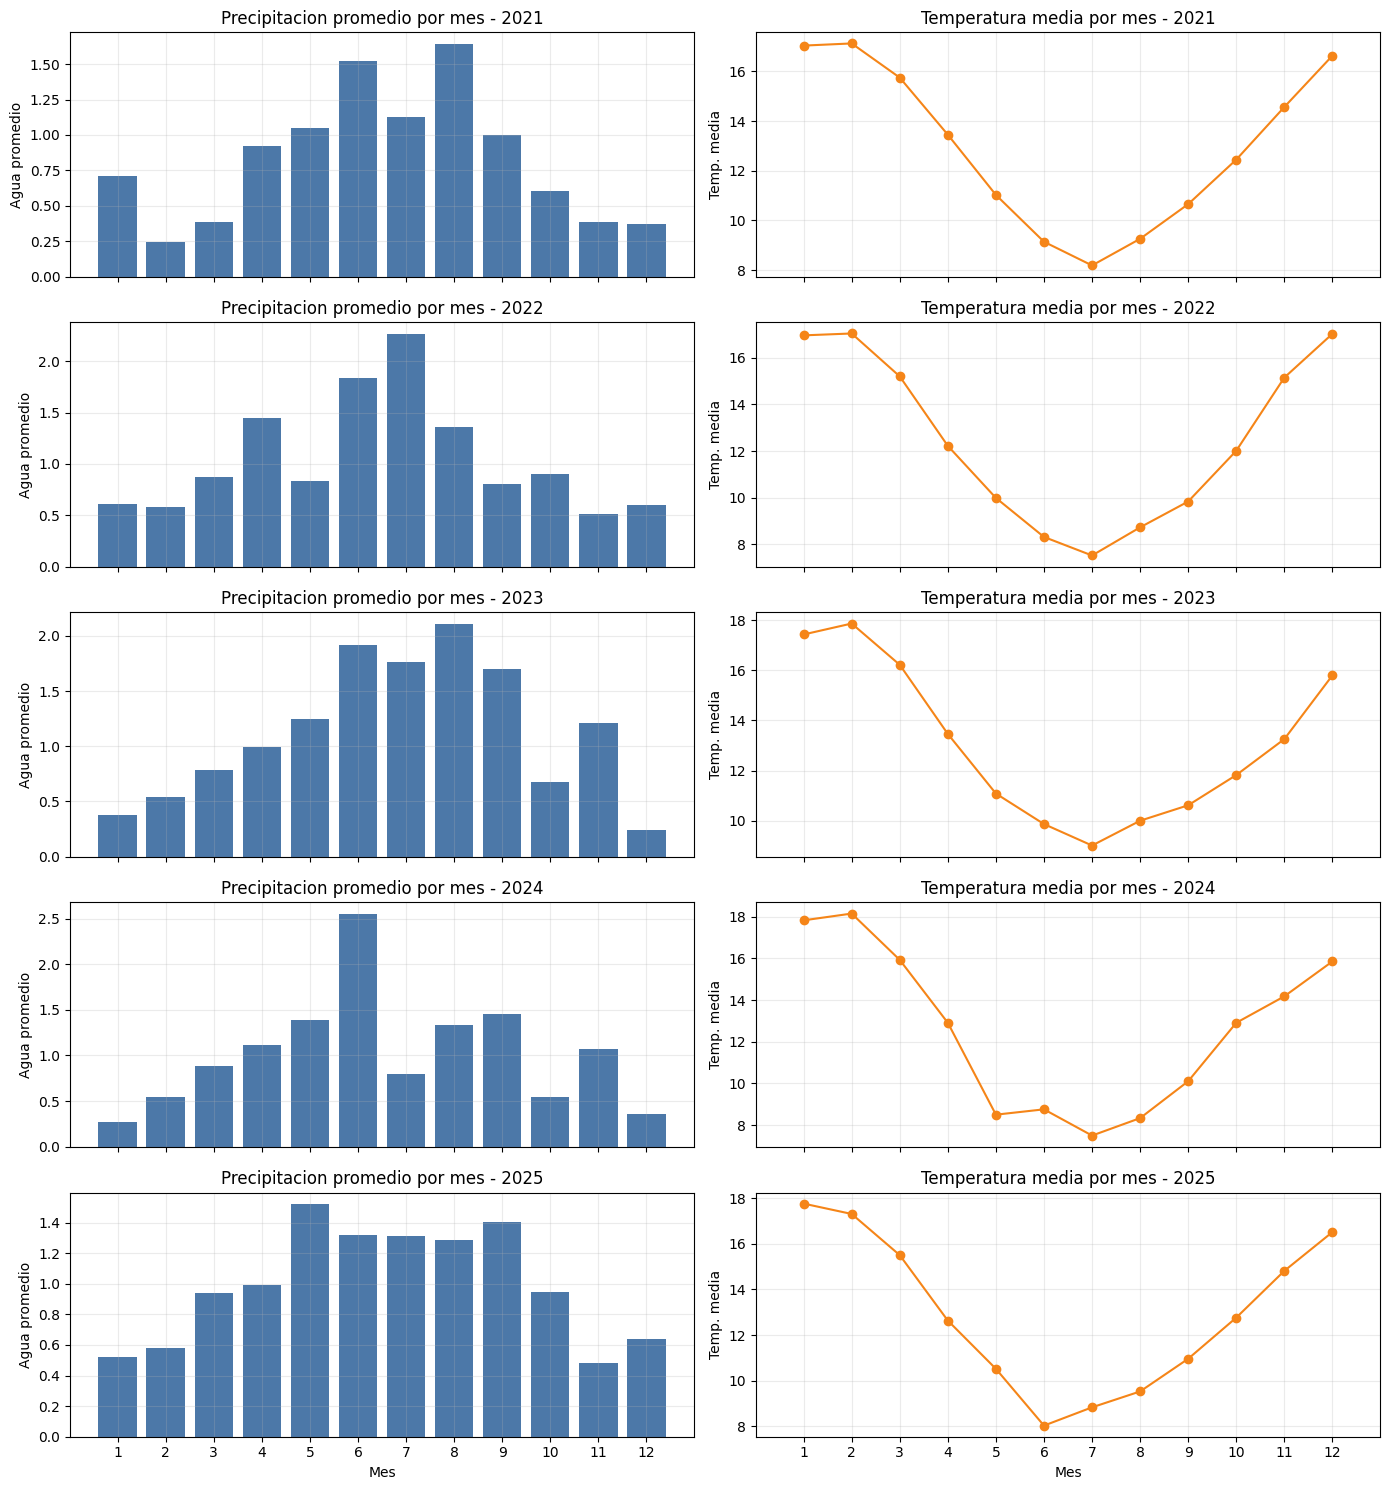

In [49]:
fig, axes = plt.subplots(len(anios_disponibles), 2, figsize=(14, 3 * len(anios_disponibles)), sharex=True)

for fila, anio in enumerate(anios_disponibles):
    datos_anio = por_anio_mes[por_anio_mes['anio'] == anio]
    axes[fila, 0].bar(datos_anio['mes'], datos_anio['agua_promedio'], color='#4c78a8')
    axes[fila, 0].set_title(f'Precipitacion promedio por mes - {anio}')
    axes[fila, 0].set_ylabel('Agua promedio')

    axes[fila, 1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', color='#f58518')
    axes[fila, 1].set_title(f'Temperatura media por mes - {anio}')
    axes[fila, 1].set_ylabel('Temp. media')

for ax in axes[-1, :]:
    ax.set_xlabel('Mes')
for ax in axes.ravel():
    ax.set_xticks(meses)

plt.tight_layout()
plt.show()

**Analisis por mes y anio:**

Los paneles muestran la estacionalidad mensual dentro de cada anio. Esto permite observar si los meses lluviosos y los meses mas calidos se mantienen consistentes entre anios o si existen variaciones relevantes que puedan influir en los modelos predictivos.

**Mini objetivo:** comparar precipitacion tratada por zona geografica usando la escala normal de `agua_caida_tratada`. Se usan dias con lluvia y una vista acotada al percentil 99 para observar mejor la dispersion entre zonas.


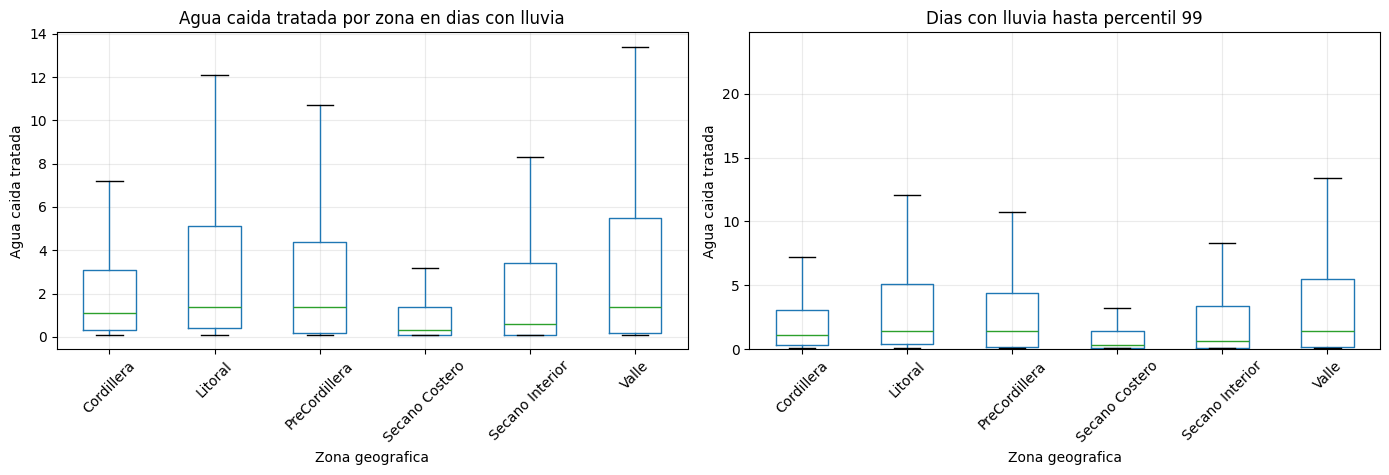

In [50]:
df_zona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]
limite_visual_zona = df_zona_lluvia['agua_caida_tratada'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[0], rot=45, showfliers=False)
axes[0].set_title('Agua caida tratada por zona en dias con lluvia')
axes[0].set_xlabel('Zona geografica')
axes[0].set_ylabel('Agua caida tratada')

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[1], rot=45, showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_xlabel('Zona geografica')
axes[1].set_ylabel('Agua caida tratada')
axes[1].set_ylim(0, limite_visual_zona)

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por zona en dias con lluvia:**

Al graficar solo dias con lluvia, la dispersion entre zonas se vuelve mas interpretable. La vista al percentil 99 mantiene escala normal y evita depender de transformaciones de escala.

**Mini objetivo:** usar una muestra para visualizar relaciones entre ubicacion geografica y temperatura sin saturar el grafico.


In [51]:
columnas_scatter = ['latitud', 'altura', 'temp_media', 'agua_caida_tratada']
muestra_scatter = df_eda[columnas_scatter].dropna().sample(
    n=min(6000, df_eda[columnas_scatter].dropna().shape[0]),
    random_state=42
)


**Mini objetivo:** graficar la muestra para contrastar temperatura con latitud y altura.


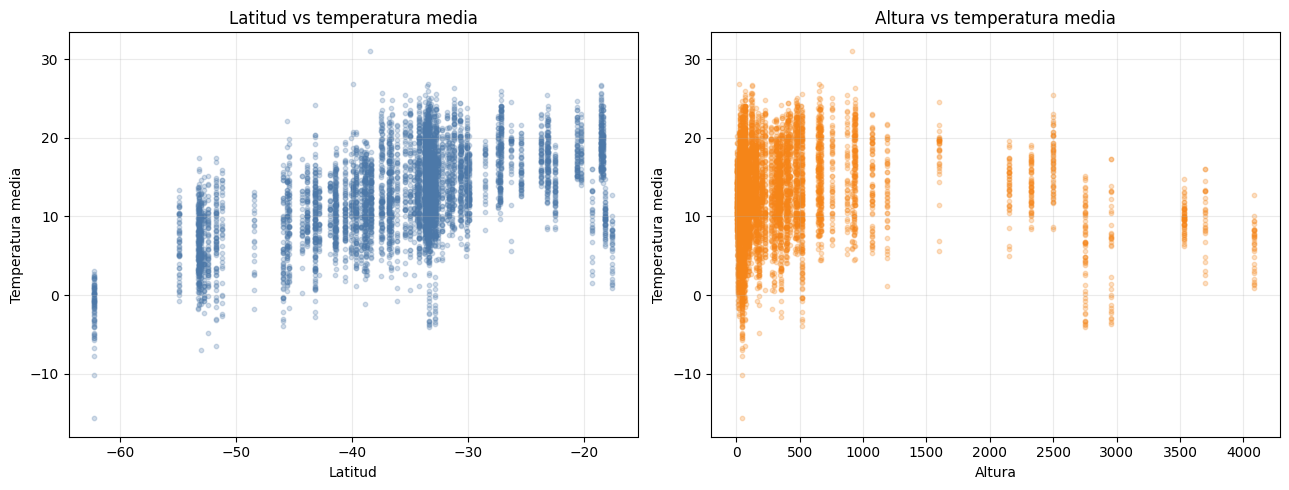

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(muestra_scatter['latitud'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#4c78a8')
axes[0].set_title('Latitud vs temperatura media')
axes[0].set_xlabel('Latitud')
axes[0].set_ylabel('Temperatura media')

axes[1].scatter(muestra_scatter['altura'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#f58518')
axes[1].set_title('Altura vs temperatura media')
axes[1].set_xlabel('Altura')
axes[1].set_ylabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis geografico y temperatura:**

Los scatter plots muestran relacion entre ubicacion, altura y temperatura media. Estos patrones apoyan el uso de variables geograficas en modelos predictivos.

**Mini objetivo:** agregar datos por estacion para visualizar distribucion geografica y precipitacion acumulada.


In [53]:
estaciones_geo = df_eda.groupby(['codigo_estacion', 'nombre_estacion']).agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media=('temp_media', 'mean')
).reset_index()


**Mini objetivo:** graficar las estaciones segun ubicacion y precipitacion acumulada para revisar patrones espaciales.


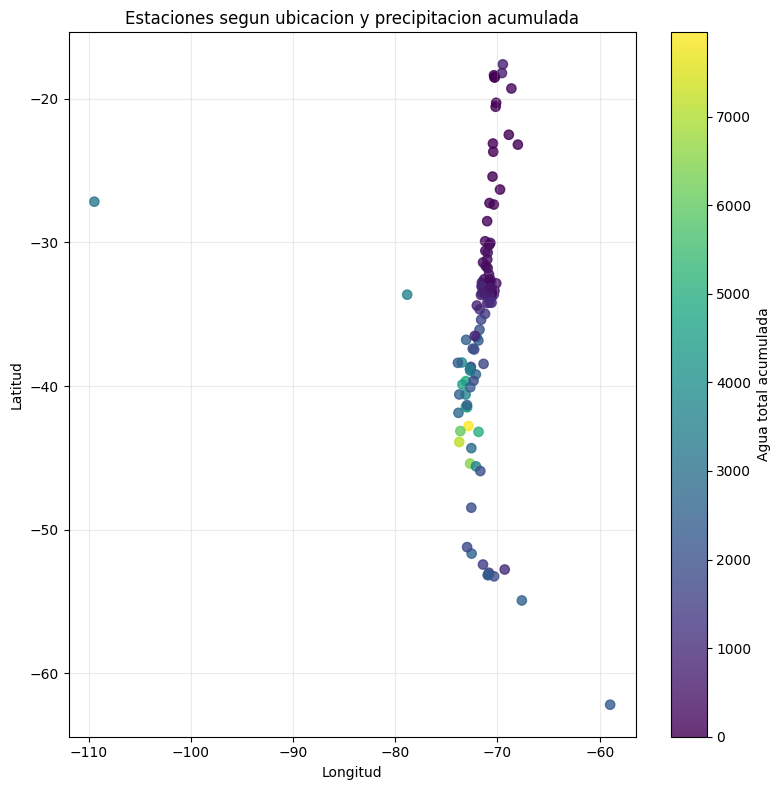

In [54]:
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    estaciones_geo['longitud'],
    estaciones_geo['latitud'],
    c=estaciones_geo['agua_total'],
    s=45,
    cmap='viridis',
    alpha=0.8
)
ax.set_title('Estaciones segun ubicacion y precipitacion acumulada')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.colorbar(scatter, ax=ax, label='Agua total acumulada')
plt.tight_layout()
plt.show()


**Analisis de estaciones:**

El grafico geografico permite ubicar estaciones y observar donde se acumula mayor precipitacion. Esta vista ayuda a interpretar diferencias territoriales y posibles sesgos de cobertura.

**Patrones detectados inicialmente:**

Los graficos temporales permiten observar estacionalidad: las precipitaciones y temperaturas cambian segun el mes. Los boxplots por zona muestran diferencias territoriales y tambien confirman la presencia de eventos extremos en precipitacion. Los graficos de latitud y altura ayudan a evaluar la hipotesis de que la ubicacion geografica influye en la temperatura. El grafico geografico de estaciones permite visualizar si la lluvia acumulada se concentra en ciertas areas del pais.


## 2.8 Nuevas variables a partir de analisis

A partir del entendimiento inicial se crean variables que facilitan el analisis y el futuro modelamiento. Estas variables traducen informacion climatica y temporal a formatos mas utiles para regresion, clasificacion y clustering.

| Nueva variable | Descripcion | Uso esperado |
|---|---|---|
| `llueve` | 1 si `agua_caida_tratada > 0`, 0 si no | Clasificacion binaria |
| `lluvia_intensa` | 1 si `agua_caida_tratada` supera el percentil 95 | Deteccion/clasificacion de lluvia alta no extrema |
| `rango_termico` | `temp_max - temp_min` | Analisis de variabilidad termica |
| `estacion_anio` | Verano, otono, invierno, primavera | Analisis estacional |
| `mes_sin`, `mes_cos` | Representacion ciclica del mes | Modelos con comportamiento anual |


**Mini objetivo:** crear variables derivadas para clasificacion, estacionalidad, rango termico y analisis de lluvia extrema.


In [55]:
umbral_lluvia_intensa = df_eda['agua_caida_tratada'].quantile(0.95)

def obtener_estacion_anio(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    if mes in [3, 4, 5]:
        return 'Otono'
    if mes in [6, 7, 8]:
        return 'Invierno'
    return 'Primavera'


**Mini objetivo:** aplicar las nuevas variables al dataset de trabajo para conectar exploracion con modelamiento.


In [56]:
df_eda['llueve'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] > 0).astype(int)
)
df_eda['lluvia_intensa'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] >= umbral_lluvia_intensa).astype(int)
)
df_eda['rango_termico'] = df_eda['temp_max'] - df_eda['temp_min']
df_eda['estacion_anio'] = df_eda['mes'].apply(obtener_estacion_anio)
df_eda['mes_sin'] = np.sin(2 * np.pi * df_eda['mes'] / 12)
df_eda['mes_cos'] = np.cos(2 * np.pi * df_eda['mes'] / 12)


**Mini objetivo:** resumir las variables derivadas para validar que fueron creadas correctamente.


In [57]:
resumen_nuevas_variables = pd.DataFrame([
    {'variable': 'umbral_lluvia_intensa', 'valor': umbral_lluvia_intensa},
    {'variable': 'dias_con_lluvia', 'valor': df_eda['llueve'].sum()},
    {'variable': 'eventos_lluvia_intensa', 'valor': df_eda['lluvia_intensa'].sum()},
    {'variable': 'rango_termico_promedio', 'valor': df_eda['rango_termico'].mean()},
])

columnas_muestra_nuevas = [
    'fecha', 'agua_caida', 'agua_caida_tratada', 'llueve',
    'lluvia_intensa', 'rango_termico', 'estacion_anio', 'mes_sin', 'mes_cos'
]

display(resumen_nuevas_variables)
display(df_eda[columnas_muestra_nuevas].head(3))


,variable,valor
0,umbral_lluvia_intensa,7.000
1,dias_con_lluvia,"43,657.000"
2,eventos_lluvia_intensa,"8,610.000"
3,rango_termico_promedio,11.284


,fecha,agua_caida,agua_caida_tratada,llueve,lluvia_intensa,rango_termico,estacion_anio,mes_sin,mes_cos
0,2023-01-01,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
1,2023-01-02,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866
2,2023-01-03,NaN,NaN,NaN,NaN,NaN,Verano,0.500,0.866


**Analisis de nuevas variables:**

Las variables creadas usan la precipitacion tratada y conectan directamente con las hipotesis del proyecto. `llueve` y `lluvia_intensa` permiten pasar desde regresion a clasificacion. `rango_termico` resume diferencias entre maxima y minima diaria. `estacion_anio`, `mes_sin` y `mes_cos` permiten representar estacionalidad, que es esperable en datos meteorologicos.


## 2.9 Matriz de Correlacion

Luego de crear nuevas variables, se calcula una segunda matriz de correlacion. El objetivo es revisar si las variables derivadas entregan senales adicionales para explicar precipitacion, temperatura o eventos de lluvia.


**Mini objetivo:** calcular una segunda correlacion incluyendo variables derivadas y graficarla con etiquetas numericas.


In [58]:
columnas_correlacion_nuevas = [
    'altura', 'latitud', 'longitud', 'mes', 'mes_sin', 'mes_cos',
    'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media',
    'rango_termico', 'llueve', 'lluvia_intensa', 'region_cod',
    'zona_geografica_cod', 'macrozona_cod'
]

corr_nuevas = df_eda[columnas_correlacion_nuevas].corr(numeric_only=True)
display(corr_nuevas.round(3))


,altura,latitud,longitud,mes,mes_sin,mes_cos,agua_caida_tratada,temp_max,temp_min,temp_media,rango_termico,llueve,lluvia_intensa,region_cod,zona_geografica_cod,macrozona_cod
altura,1.000,0.393,0.182,-0.002,0.002,-0.001,-0.092,0.074,-0.161,-0.031,0.238,-0.154,-0.074,-0.089,-0.184,-0.374
latitud,0.393,1.000,-0.062,-0.002,0.001,-0.001,-0.168,0.518,0.487,0.559,0.182,-0.343,-0.121,-0.216,-0.073,-0.947
longitud,0.182,-0.062,1.000,-0.001,0.001,-0.001,-0.084,-0.095,-0.234,-0.184,0.098,-0.131,-0.065,-0.092,0.031,-0.080
mes,-0.002,-0.002,-0.001,1.000,-0.762,0.205,0.007,-0.136,-0.150,-0.157,-0.028,0.009,0.007,0.001,0.000,0.001
mes_sin,0.002,0.001,0.001,-0.762,1.000,-0.001,-0.045,0.281,0.279,0.316,0.085,-0.062,-0.040,-0.001,-0.002,-0.000
mes_cos,-0.001,-0.001,-0.001,0.205,-0.001,1.000,-0.116,0.443,0.369,0.479,0.196,-0.173,-0.095,0.001,-0.001,0.001
agua_caida_tratada,-0.092,-0.168,-0.084,0.007,-0.045,-0.116,1.000,-0.240,-0.048,-0.167,-0.244,0.517,0.879,-0.049,-0.003,0.196
temp_max,0.074,0.518,-0.095,-0.136,0.281,0.443,-0.240,1.000,0.582,0.901,0.675,-0.411,-0.184,-0.021,0.252,-0.473
temp_min,-0.161,0.487,-0.234,-0.150,0.279,0.369,-0.048,0.582,1.000,0.859,-0.207,-0.172,-0.030,-0.128,-0.126,-0.456
temp_media,-0.031,0.559,-0.184,-0.157,0.316,0.479,-0.167,0.901,0.859,1.000,0.304,-0.339,-0.124,-0.077,0.076,-0.518


**Analisis de segunda matriz de correlacion:**

La segunda matriz permite revisar el efecto de variables nuevas como `llueve`, `lluvia_intensa`, `rango_termico` y codificaciones territoriales. Esto conecta la exploracion con el modelamiento posterior.

**Mini objetivo:** visualizar la segunda matriz de correlacion con etiquetas numericas para facilitar su lectura.


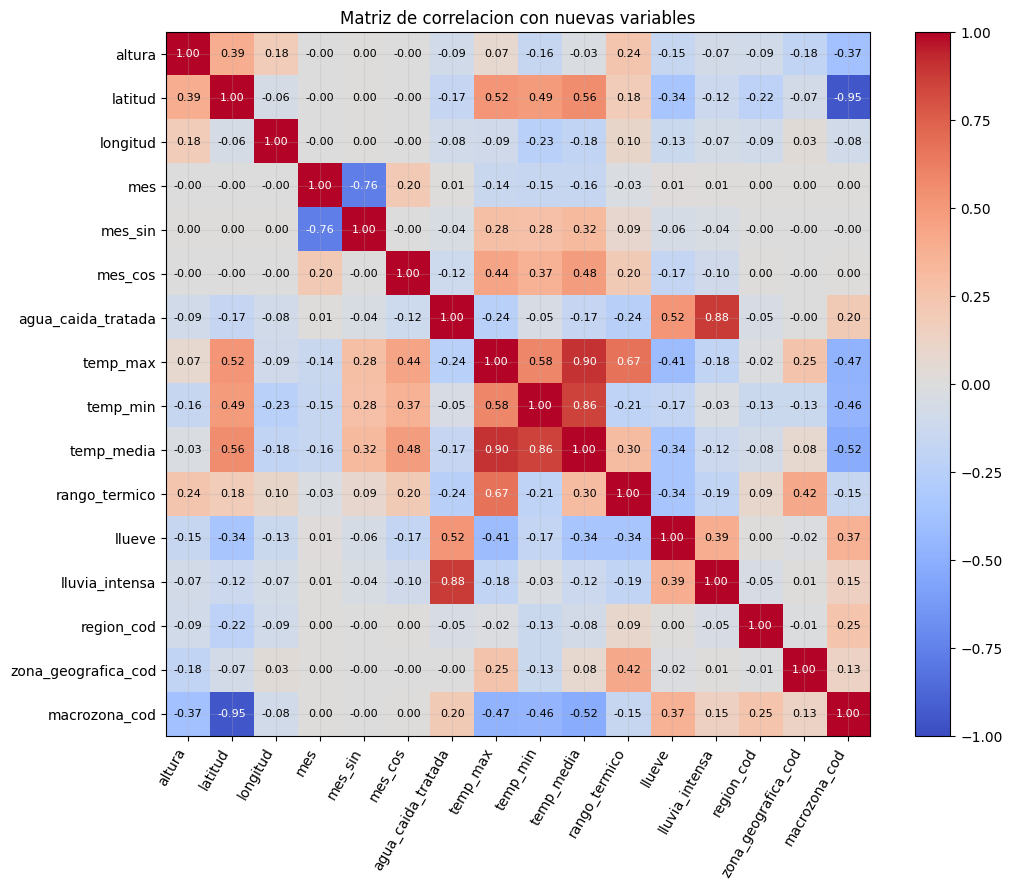

In [59]:
graficar_matriz_correlacion(
    corr_nuevas,
    'Matriz de correlacion con nuevas variables',
    figsize=(12, 9),
    rotacion=60
)


**Analisis de correlacion con nuevas variables:**

La segunda matriz permite comparar variables originales y derivadas manteniendo la precipitacion en escala normal mediante `agua_caida_tratada`. La inclusion de `macrozona_cod` permite revisar si la agrupacion territorial aporta alguna senal exploratoria. Las variables `llueve` y `lluvia_intensa` seran utiles para modelos de clasificacion, aunque no necesariamente tendran correlaciones lineales fuertes con todas las variables climaticas.


## 2.10 Patrones/comportamientos detectados con nuevas variables

Con las nuevas variables se analizan patrones mas cercanos al futuro modelamiento: dias con lluvia, lluvia intensa, estacionalidad y relaciones entre variables climaticas. Tambien se incluye una visualizacion tipo pairplot para observar relaciones combinadas entre variables.


**Mini objetivo:** contar registros con y sin lluvia para revisar el balance de la variable objetivo de clasificacion.


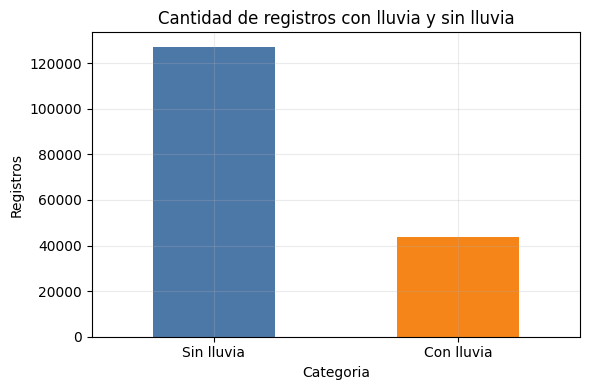

In [60]:
conteo_lluvia = df_eda['llueve'].map({0: 'Sin lluvia', 1: 'Con lluvia'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
conteo_lluvia.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('Cantidad de registros con lluvia y sin lluvia')
ax.set_xlabel('Categoria')
ax.set_ylabel('Registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Analisis de balance de lluvia:**

La clase `Sin lluvia` es mayoritaria, por lo que accuracy por si sola puede ser enganosa. En clasificacion se deben revisar tambien precision, recall y F1-score.

**Mini objetivo:** comparar eventos de lluvia intensa por region, zona geografica y macrozona.


In [61]:
lluvia_intensa_region = df_eda[df_eda['lluvia_intensa'] == 1].groupby('nombre_region').size().sort_values()
lluvia_intensa_zona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('zona_geografica').size().sort_values()
lluvia_intensa_macrozona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('macrozona', observed=True).size()


**Mini objetivo:** graficar los eventos de lluvia intensa para comparar concentracion territorial en tres niveles: region, zona geografica y macrozona.


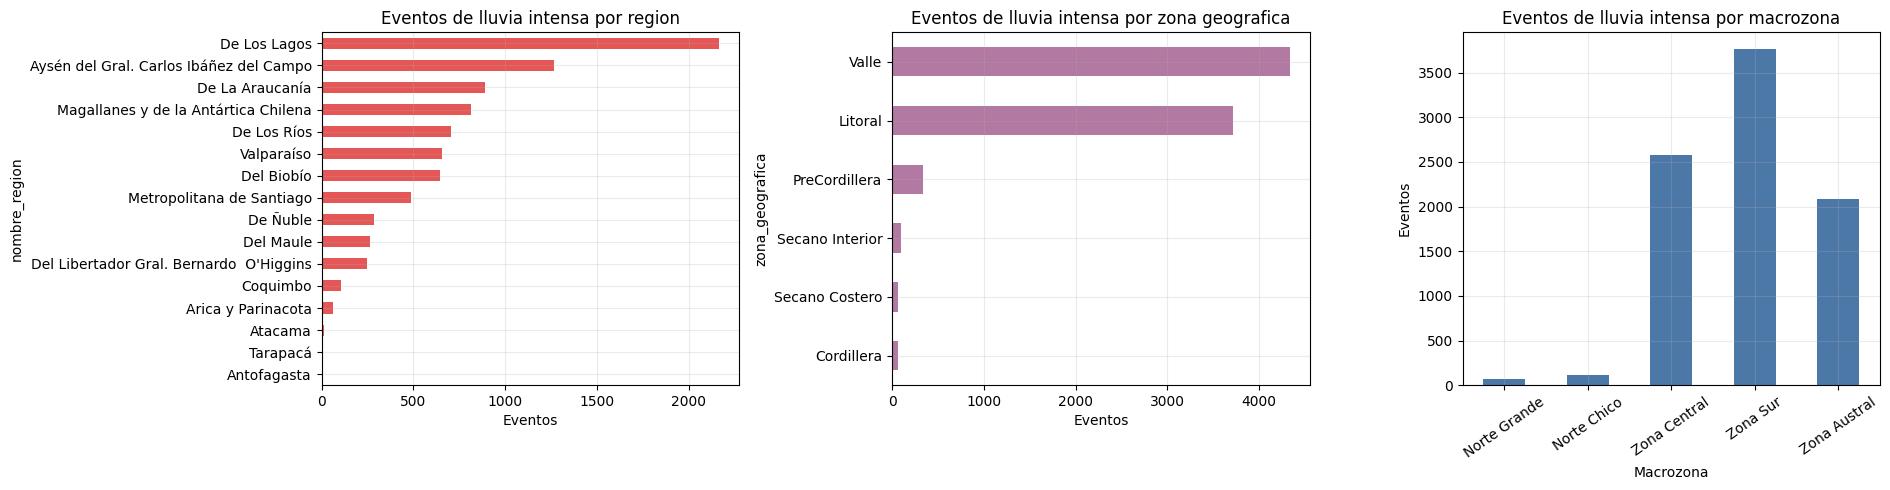

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

lluvia_intensa_region.plot(kind='barh', ax=axes[0], color='#e45756')
axes[0].set_title('Eventos de lluvia intensa por region')
axes[0].set_xlabel('Eventos')

lluvia_intensa_zona.plot(kind='barh', ax=axes[1], color='#b279a2')
axes[1].set_title('Eventos de lluvia intensa por zona geografica')
axes[1].set_xlabel('Eventos')

lluvia_intensa_macrozona.plot(kind='bar', ax=axes[2], color='#4c78a8')
axes[2].set_title('Eventos de lluvia intensa por macrozona')
axes[2].set_xlabel('Macrozona')
axes[2].set_ylabel('Eventos')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis de lluvia intensa:**

Los eventos intensos son menos frecuentes y se concentran territorialmente. Esto anticipa un problema de clasificacion desbalanceado, donde recall y F1 son mas informativos que accuracy sola.

**Mini objetivo:** comparar temperatura segun presencia de lluvia y precipitacion tratada por estacion del anio. Para precipitacion se usan solo dias con lluvia.


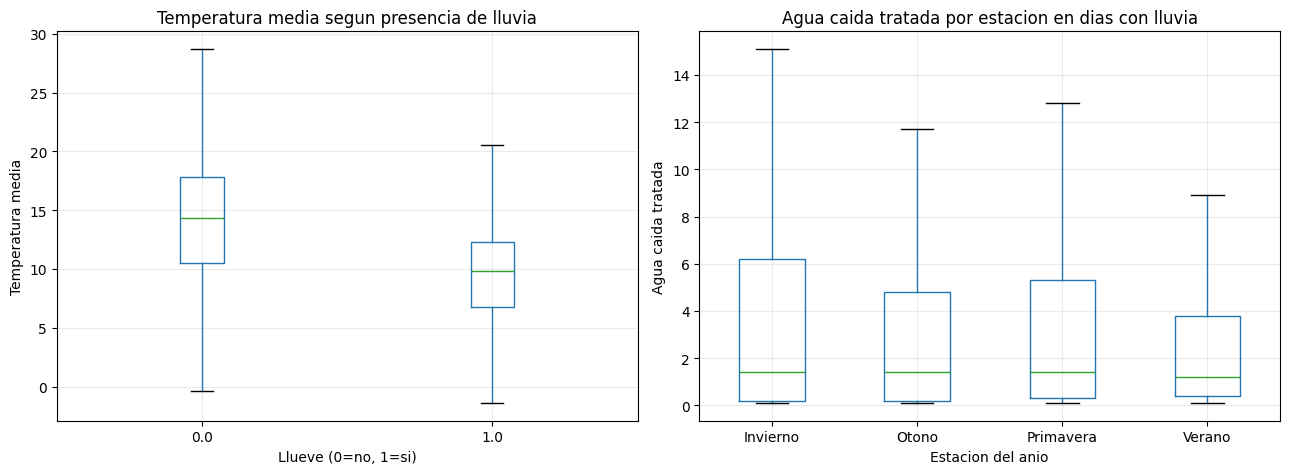

In [63]:
df_lluvia_positiva = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_eda.boxplot(column='temp_media', by='llueve', ax=axes[0], showfliers=False)
axes[0].set_title('Temperatura media segun presencia de lluvia')
axes[0].set_xlabel('Llueve (0=no, 1=si)')
axes[0].set_ylabel('Temperatura media')

df_lluvia_positiva.boxplot(column='agua_caida_tratada', by='estacion_anio', ax=axes[1], showfliers=False)
axes[1].set_title('Agua caida tratada por estacion en dias con lluvia')
axes[1].set_xlabel('Estacion del anio')
axes[1].set_ylabel('Agua caida tratada')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis comparativo de clases:**

La lluvia se asocia a diferencias de temperatura y estacionalidad. Estos patrones justifican usar variables climaticas y temporales para clasificar presencia de lluvia o lluvia intensa.

**Mini objetivo:** construir una visualizacion tipo pairplot para observar relaciones cruzadas entre variables climaticas y geograficas.


In [64]:
variables_pairplot = ['agua_caida_tratada', 'temp_media', 'rango_termico', 'altura', 'latitud', 'llueve']
muestra_pairplot = df_eda[variables_pairplot].dropna().sample(
    n=min(2500, df_eda[variables_pairplot].dropna().shape[0]),
    random_state=42
)


**Mini objetivo:** graficar la muestra seleccionada para observar relaciones cruzadas entre variables sin saturar el notebook.


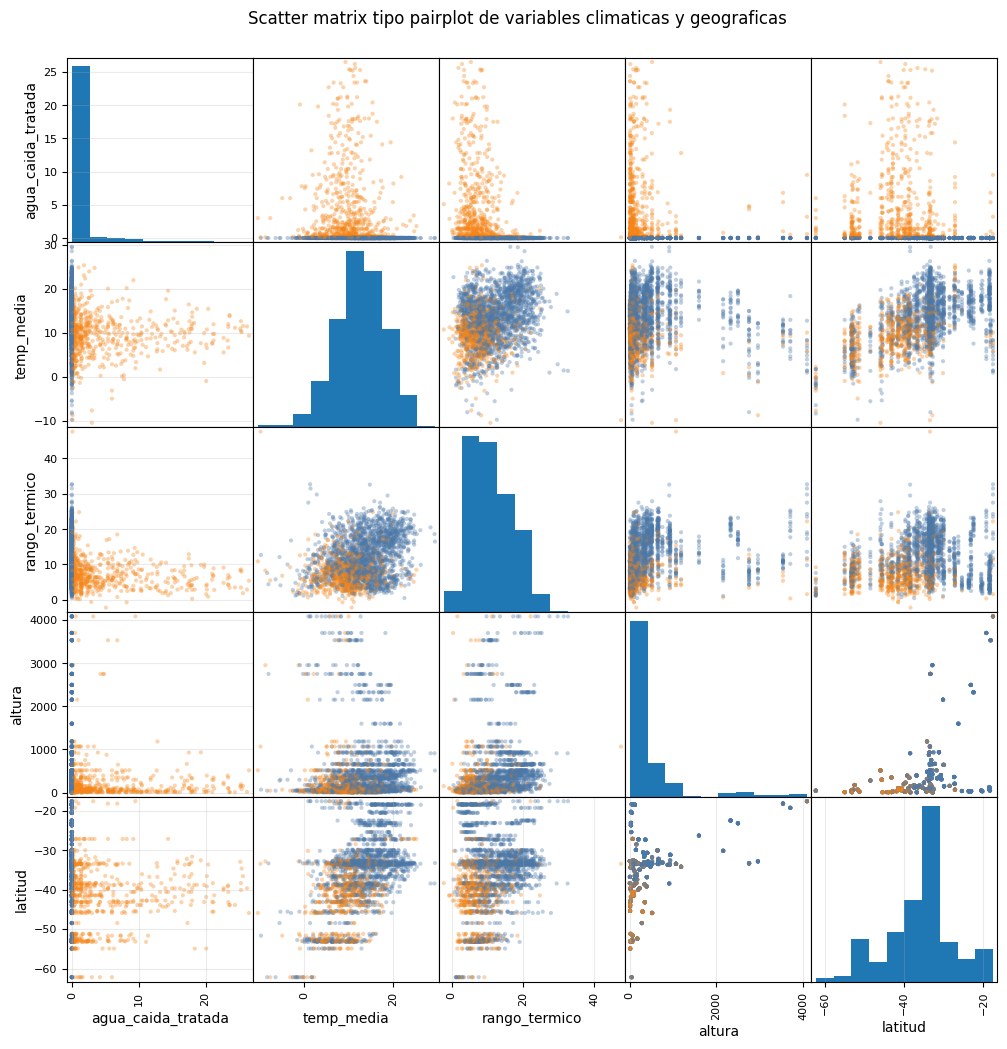

In [65]:
if sns is not None:
    sns.pairplot(
        muestra_pairplot,
        vars=['agua_caida_tratada', 'temp_media', 'rango_termico', 'altura', 'latitud'],
        hue='llueve',
        diag_kind='hist',
        plot_kws={'alpha': 0.35, 's': 12}
    )
    plt.suptitle('Pairplot de variables climaticas y geograficas', y=1.02)
    plt.show()
else:
    colores = np.where(muestra_pairplot['llueve'] == 1, '#f58518', '#4c78a8')
    scatter_matrix(
        muestra_pairplot[['agua_caida_tratada', 'temp_media', 'rango_termico', 'altura', 'latitud']],
        figsize=(12, 12), diagonal='hist', color=colores, alpha=0.35
    )
    plt.suptitle('Scatter matrix tipo pairplot de variables climaticas y geograficas', y=0.92)
    plt.show()


**Analisis de patrones con nuevas variables:**

Las variables derivadas permiten observar el problema desde una perspectiva mas util para mineria de datos. La variable `llueve` separa el dataset en dos clases, mientras que `lluvia_intensa` permite estudiar eventos poco frecuentes. Los boxplots comparan condiciones termicas y estacionales. La visualizacion tipo pairplot ayuda a detectar relaciones no evidentes entre lluvia, temperatura, rango termico, altura y latitud.


## Cierre de Fase 2

En esta fase se corrigio la carga del dataset, se identificaron tipos de variables, nulos, outliers, transformaciones iniciales, estadisticos basicos, correlaciones y patrones. Tambien se crearon nuevas variables que conectan el analisis exploratorio con las siguientes fases del proyecto.

Decisiones principales para continuar:

1. Usar `dataset_precipitaciones_temperaturas_chile.csv` como fuente principal.
2. Mantener outliers climaticos marcados, conservando el dato original.
3. Usar `agua_caida_tratada` para analisis y modelamiento cuando los extremos altos distorsionen los resultados.
4. Usar `llueve` y `lluvia_intensa` para modelos de clasificacion.
5. Usar `agua_caida_tratada` o `temp_media` como posibles objetivos de regresion.
6. Usar variables agregadas por estacion para clustering en fases posteriores.

La siguiente fase corresponde a **Transformacion**, donde se prepararan los datos para modelamiento mediante imputacion, encoding y escalamiento.


# 3. Transformacion

Esta fase convierte el analisis exploratorio en una base preparada para modelamiento. La transformacion integra zonas climaticas Koppen-Geiger oficiales asignadas por coordenadas, variables territoriales, imputacion simple, encoding y escalamiento, conservando trazabilidad entre los datos originales y las variables finales.

## 3.1 Zonas climaticas Koppen-Geiger oficiales

**Mini objetivo:** reemplazar la clasificacion aproximada por una asignacion geoespacial basada en el raster Koppen-Geiger 1991-2020 de 1 km. La zona se asigna usando la latitud y longitud de cada estacion, por lo que queda trazada a una fuente climatologica externa y no a reglas manuales por macrozona.

In [66]:
KOPPEN_DIR.mkdir(exist_ok=True)

archivos_koppen = [
    {'archivo': 'Raster Koppen-Geiger 1991-2020 1 km', 'ruta': KOPPEN_TIF, 'url': KOPPEN_TIF_URL},
    {'archivo': 'Leyenda Koppen-Geiger', 'ruta': KOPPEN_LEGEND, 'url': KOPPEN_LEGEND_URL},
]

for item in archivos_koppen:
    if not item['ruta'].exists():
        urllib.request.urlretrieve(item['url'], item['ruta'])

estado_koppen = pd.DataFrame([
    {
        'archivo': item['archivo'],
        'ruta': item['ruta'].as_posix(),
        'existe': item['ruta'].exists(),
        'tamano_mb': round(item['ruta'].stat().st_size / (1024 ** 2), 2) if item['ruta'].exists() else np.nan,
        'fuente': item['url']
    }
    for item in archivos_koppen
])

display(estado_koppen)

,archivo,ruta,existe,tamano_mb,fuente
0,Raster Koppen-Geiger 1991-2020 1 km,.data/koppen_geiger/koppen_geiger_1991_2020_1k...,True,17.860,https://data.naturalcapitalalliance.stanford.e...
1,Leyenda Koppen-Geiger,.data/koppen_geiger/legend.txt,True,0.000,https://data.naturalcapitalalliance.stanford.e...


**Mini objetivo:** leer la leyenda oficial del raster y extraer la clase Koppen-Geiger de cada estacion meteorologica. Para evitar repetir calculos por cada registro diario, la asignacion se calcula una vez por estacion y luego se une al dataset principal.

In [67]:
def leer_leyenda_koppen(ruta_leyenda):
    leyenda = {}
    patron = re.compile(r'\s*(\d+):\s+([A-Z][A-Za-z]{1,2})\s+(.+?)\s+\[')
    with open(ruta_leyenda, encoding='utf-8', errors='replace') as archivo:
        for linea in archivo:
            coincidencia = patron.match(linea)
            if coincidencia:
                valor = int(coincidencia.group(1))
                codigo = coincidencia.group(2)
                descripcion = coincidencia.group(3).strip()
                leyenda[valor] = {'codigo': codigo, 'descripcion': descripcion}
    return leyenda


def extraer_koppen_por_coordenada(raster, leyenda, longitud, latitud, radio_maximo=5):
    escala = raster.tag_v2.get(33550)
    referencia = raster.tag_v2.get(33922)
    origen_x, origen_y = referencia[3], referencia[4]
    pixel_x, pixel_y = escala[0], escala[1]
    ancho, alto = raster.size

    columna = int((longitud - origen_x) / pixel_x)
    fila = int((origen_y - latitud) / pixel_y)
    if not (0 <= columna < ancho and 0 <= fila < alto):
        return {'zona_koppen_valor': 0, 'zona_koppen_codigo': 'Sin dato', 'zona_koppen_descripcion': 'Fuera del raster', 'zona_koppen_radio_px': np.nan}

    valor = int(raster.getpixel((columna, fila)))
    radio_usado = 0

    if valor == 0:
        for radio in range(1, radio_maximo + 1):
            encontrado = False
            for delta_y in range(-radio, radio + 1):
                for delta_x in range(-radio, radio + 1):
                    if abs(delta_x) != radio and abs(delta_y) != radio:
                        continue
                    columna_vecina = columna + delta_x
                    fila_vecina = fila + delta_y
                    if 0 <= columna_vecina < ancho and 0 <= fila_vecina < alto:
                        valor_vecino = int(raster.getpixel((columna_vecina, fila_vecina)))
                        if valor_vecino != 0:
                            valor = valor_vecino
                            radio_usado = radio
                            encontrado = True
                            break
                if encontrado:
                    break
            if encontrado:
                break

    clase = leyenda.get(valor, {'codigo': 'Sin dato', 'descripcion': 'Sin clasificacion disponible'})
    return {
        'zona_koppen_valor': valor,
        'zona_koppen_codigo': clase['codigo'],
        'zona_koppen_descripcion': clase['descripcion'],
        'zona_koppen_radio_px': radio_usado if valor != 0 else np.nan
    }


Image.MAX_IMAGE_PIXELS = None
leyenda_koppen = leer_leyenda_koppen(KOPPEN_LEGEND)
raster_koppen = Image.open(KOPPEN_TIF)

estaciones_koppen = df_eda[[
    'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'latitud', 'longitud', 'altura'
]].drop_duplicates('codigo_estacion').copy()

asignaciones_koppen = estaciones_koppen.apply(
    lambda fila: pd.Series(extraer_koppen_por_coordenada(
        raster_koppen,
        leyenda_koppen,
        fila['longitud'],
        fila['latitud']
    )),
    axis=1
).reset_index(drop=True)

estaciones_koppen = pd.concat([estaciones_koppen.reset_index(drop=True), asignaciones_koppen], axis=1)
estaciones_koppen['zona_koppen'] = estaciones_koppen['zona_koppen_codigo'] + ' - ' + estaciones_koppen['zona_koppen_descripcion']

columnas_koppen = ['zona_koppen_valor', 'zona_koppen_codigo', 'zona_koppen_descripcion', 'zona_koppen_radio_px', 'zona_koppen', 'zona_koppen_cod']
df_eda = df_eda.drop(columns=[columna for columna in columnas_koppen if columna in df_eda.columns])
df_eda = df_eda.merge(
    estaciones_koppen[['codigo_estacion'] + columnas_koppen[:-1]],
    on='codigo_estacion',
    how='left'
)
df_eda['zona_koppen_cod'] = df_eda['zona_koppen_codigo'].astype('category').cat.codes

resumen_koppen = df_eda['zona_koppen'].value_counts().rename_axis('zona_koppen').to_frame('registros')
resumen_asignacion_koppen = pd.DataFrame([
    {'indicador': 'estaciones clasificadas', 'valor': estaciones_koppen['zona_koppen_codigo'].ne('Sin dato').sum()},
    {'indicador': 'estaciones sin clasificacion', 'valor': estaciones_koppen['zona_koppen_codigo'].eq('Sin dato').sum()},
    {'indicador': 'zonas Koppen-Geiger presentes', 'valor': estaciones_koppen['zona_koppen_codigo'].nunique()},
    {'indicador': 'asignaciones por pixel exacto', 'valor': estaciones_koppen['zona_koppen_radio_px'].eq(0).sum()},
    {'indicador': 'asignaciones por pixel cercano', 'valor': estaciones_koppen['zona_koppen_radio_px'].gt(0).sum()},
])

auditoria_koppen = estaciones_koppen[
    estaciones_koppen['zona_koppen_radio_px'].fillna(-1).gt(0) |
    estaciones_koppen['zona_koppen_codigo'].eq('Sin dato')
][[
    'codigo_estacion', 'nombre_estacion', 'latitud', 'longitud',
    'zona_koppen_codigo', 'zona_koppen_descripcion', 'zona_koppen_radio_px'
]].sort_values(['zona_koppen_radio_px', 'codigo_estacion'])

display(resumen_koppen)
display(resumen_asignacion_koppen)
display(auditoria_koppen)

,registros
zona_koppen,
"Csb - Temperate, dry summer, warm summer",53002
"BSk - Arid, steppe, cold",37823
"Cfb - Temperate, no dry season, warm summer",29788
"BWk - Arid, desert, cold",19851
"Csa - Temperate, dry summer, hot summer",17106
"BWh - Arid, desert, hot",14602
"Cfc - Temperate, no dry season, cold summer",6574
"ET - Polar, tundra",3652
"Af - Tropical, rainforest",1826


,indicador,valor
0,estaciones clasificadas,109
1,estaciones sin clasificacion,0
2,zonas Koppen-Geiger presentes,11
3,asignaciones por pixel exacto,107
4,asignaciones por pixel cercano,2


,codigo_estacion,nombre_estacion,latitud,longitud,zona_koppen_codigo,zona_koppen_descripcion,zona_koppen_radio_px
42,330031,"Juan Fernández, Estación Meteorológica.",-33.636,-78.833,Csb,"Temperate, dry summer, warm summer",1
107,550001,"Guardiamarina Zañartu, Pto Williams Ad.",-54.932,-67.616,Dfc,"Cold, no dry season, cold summer",1


**Analisis de zonas Koppen-Geiger oficiales:**

La clasificacion queda asignada desde un raster climatologico 1991-2020 de 1 km, usando coordenadas de estaciones. Esta version es mas defendible que una regla por macrozona, porque cada estacion recibe el codigo Koppen-Geiger correspondiente a su ubicacion espacial. Se conserva el codigo oficial, la descripcion, el valor numerico del raster y el radio de busqueda usado para auditar casos costeros o sin dato. Si aparece radio mayor que 0, significa que la coordenada cayo en un pixel sin dato y se uso el pixel climatico valido mas cercano, dejando el caso visible en la tabla de auditoria.

**Mini objetivo:** relacionar la zona Koppen-Geiger oficial con la zona geografica del dataset para revisar coherencia territorial y detectar posibles diferencias entre clasificacion climatica y agrupacion administrativa/fisica.

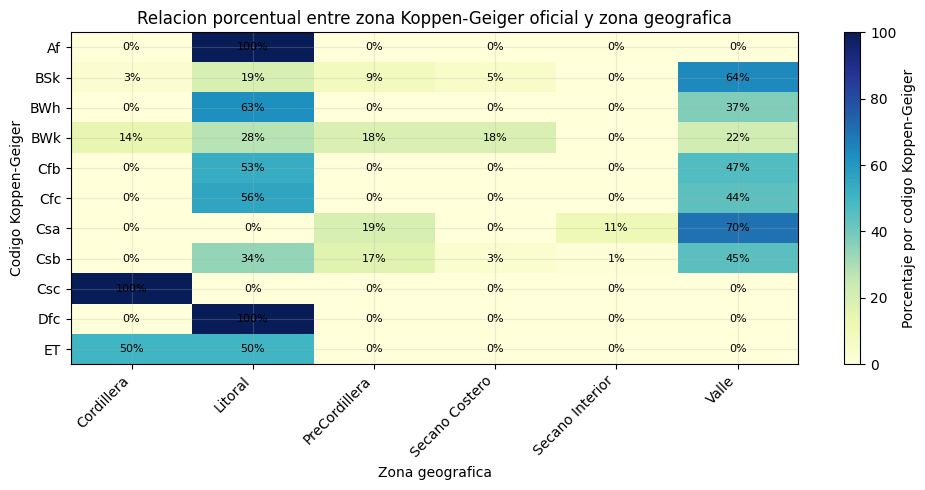

In [68]:
relacion_koppen_zona = pd.crosstab(
    df_eda['zona_koppen_codigo'],
    df_eda['zona_geografica'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(relacion_koppen_zona, cmap='YlGnBu', aspect='auto')
ax.set_title('Relacion porcentual entre zona Koppen-Geiger oficial y zona geografica')
ax.set_xlabel('Zona geografica')
ax.set_ylabel('Codigo Koppen-Geiger')
ax.set_xticks(range(len(relacion_koppen_zona.columns)))
ax.set_xticklabels(relacion_koppen_zona.columns, rotation=45, ha='right')
ax.set_yticks(range(len(relacion_koppen_zona.index)))
ax.set_yticklabels(relacion_koppen_zona.index)
for y in range(relacion_koppen_zona.shape[0]):
    for x in range(relacion_koppen_zona.shape[1]):
        valor = relacion_koppen_zona.iloc[y, x]
        ax.text(x, y, f'{valor:.0f}%', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Porcentaje por codigo Koppen-Geiger')
plt.tight_layout()
plt.show()

**Analisis de relacion Koppen-Geiger y zona geografica:**

La tabla visual permite validar si las zonas climaticas oficiales se concentran en franjas territoriales esperadas. Si una misma zona geografica contiene varios codigos Koppen-Geiger, esto no es un error: indica que la clasificacion climatica captura diferencias locales de temperatura, precipitacion y altura que una categoria territorial amplia no siempre representa.

## 3.2 Mapa climatico y comportamiento anual

**Mini objetivo:** preparar una funcion simple para dibujar el contorno de Chile usando el GeoJSON disponible, sin depender de librerias geoespaciales externas.

In [69]:
def obtener_poligonos_chile(ruta_geojson):
    with open(ruta_geojson, 'r', encoding='utf-8') as archivo:
        geojson = json.load(archivo)
    geometria = geojson['features'][0]['geometry']
    if geometria['type'] == 'Polygon':
        return [geometria['coordinates']]
    return geometria['coordinates']


def trazar_chile(ax, poligonos):
    for poligono in poligonos:
        for anillo in poligono:
            coords = np.array(anillo)
            ax.plot(coords[:, 0], coords[:, 1], color='0.55', linewidth=0.8)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_aspect('equal', adjustable='box')

poligonos_chile = obtener_poligonos_chile(CHILE_GEOJSON)

**Mini objetivo:** representar un mapa de calor por estaciones, comparando precipitacion promedio y temperatura media acumulada territorialmente.

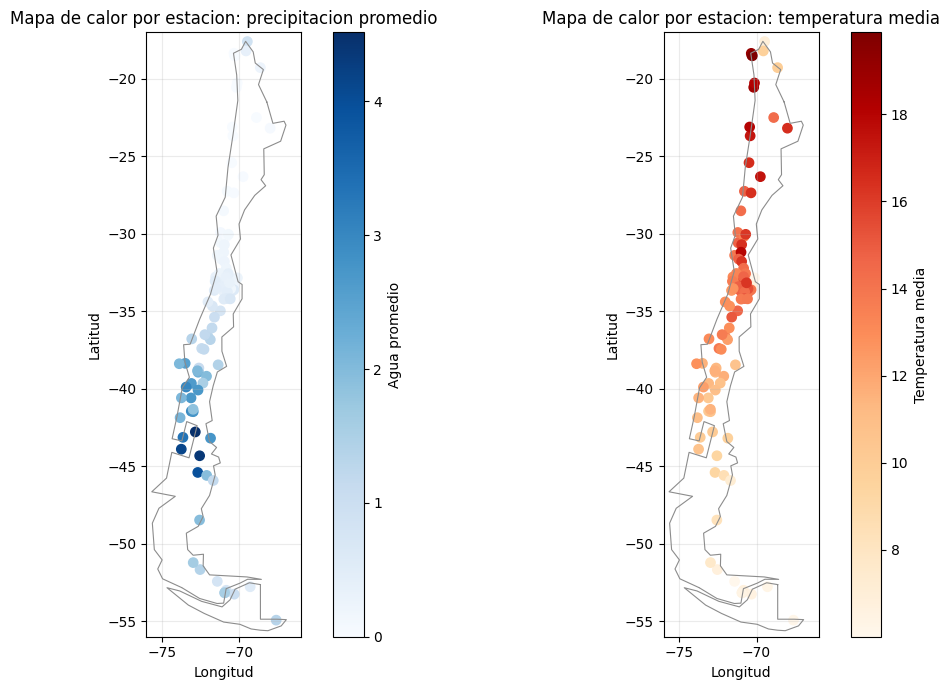

In [70]:
estaciones_mapa = df_eda.groupby('codigo_estacion').agg(
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_promedio=('agua_caida_tratada', 'mean')
).dropna()

estaciones_mapa = estaciones_mapa[
    estaciones_mapa['longitud'].between(-76, -66) &
    estaciones_mapa['latitud'].between(-56, -17)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax in axes:
    trazar_chile(ax, poligonos_chile)
    ax.set_xlim(-76, -66)
    ax.set_ylim(-56, -17)

sc1 = axes[0].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['agua_promedio'], cmap='Blues', s=45)
axes[0].set_title('Mapa de calor por estacion: precipitacion promedio')
plt.colorbar(sc1, ax=axes[0], label='Agua promedio')

sc2 = axes[1].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['temp_media'], cmap='OrRd', s=45)
axes[1].set_title('Mapa de calor por estacion: temperatura media')
plt.colorbar(sc2, ax=axes[1], label='Temperatura media')
plt.tight_layout()
plt.show()

**Analisis del mapa climatico:**

El mapa permite observar gradientes territoriales sin convertir el analisis en una visualizacion puramente tabular. La intensidad del color resume el comportamiento promedio por estacion y ayuda a relacionar ubicacion con lluvia y temperatura.

**Mini objetivo:** comparar promedio anual de precipitacion tratada y temperatura media para observar variaciones entre anios.

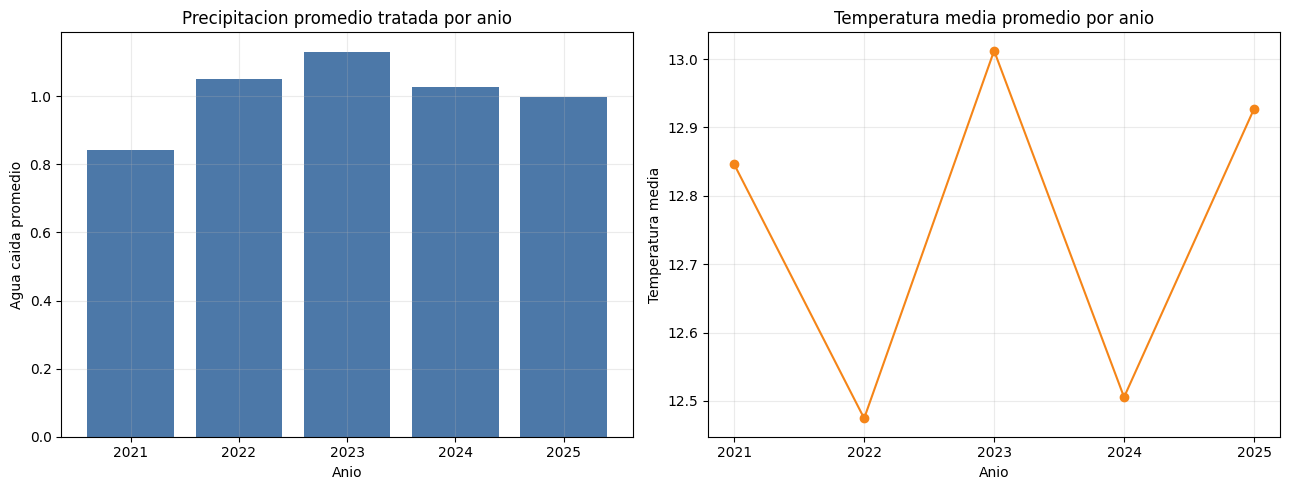

In [71]:
clima_por_anio = df_eda.groupby('anio').agg(
    precipitacion_promedio=('agua_caida_tratada', 'mean'),
    precipitacion_total=('agua_caida_tratada', 'sum'),
    temperatura_promedio=('temp_media', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(clima_por_anio['anio'], clima_por_anio['precipitacion_promedio'], color='#4c78a8')
axes[0].set_title('Precipitacion promedio tratada por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Agua caida promedio')

axes[1].plot(clima_por_anio['anio'], clima_por_anio['temperatura_promedio'], marker='o', color='#f58518')
axes[1].set_title('Temperatura media promedio por anio')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('Temperatura media')
axes[1].set_xticks(clima_por_anio['anio'])
plt.tight_layout()
plt.show()

**Analisis anual:**

La comparacion anual separa el comportamiento promedio de lluvia y temperatura por periodo. Esta lectura evita resumir todo el horizonte 2021-2025 en una sola media y permite identificar anios con comportamiento distinto.

## 3.3 Variables categoricas e insights

**Mini objetivo:** codificar todas las variables categoricas principales para explorar asociaciones visuales mediante pairplot y matriz de correlacion.

In [72]:
variables_categoricas_analisis = [
    'nombre_region', 'zona_geografica', 'macrozona',
    'estacion_anio', 'zona_koppen_codigo'
]

categoricas_codificadas = df_eda[variables_categoricas_analisis + ['llueve', 'lluvia_intensa']].copy()
for columna in variables_categoricas_analisis:
    categoricas_codificadas[f'{columna}_cod'] = categoricas_codificadas[columna].astype('category').cat.codes

columnas_categoricas_cod = [f'{columna}_cod' for columna in variables_categoricas_analisis]
muestra_categoricas = categoricas_codificadas[columnas_categoricas_cod + ['llueve', 'lluvia_intensa']].dropna()
muestra_categoricas = muestra_categoricas.sample(min(2500, len(muestra_categoricas)), random_state=42)

display(muestra_categoricas.head())

,nombre_region_cod,zona_geografica_cod,macrozona_cod,estacion_anio_cod,zona_koppen_codigo_cod,llueve,lluvia_intensa
126417,5,5,3,1,7,0.000,0.000
105803,10,1,2,2,7,1.000,0.000
182894,12,1,4,1,1,1.000,1.000
7459,1,1,0,0,2,0.000,0.000
13485,0,2,0,3,3,0.000,0.000


**Analisis de codificacion categorica:**

La codificacion permite visualizar asociaciones entre categorias dentro de herramientas numericas. Los codigos no representan magnitud ordinal; se usan como soporte grafico para detectar agrupaciones o separaciones entre categorias.

**Mini objetivo:** construir un pairplot de variables categoricas codificadas para observar patrones entre region, zona, macrozona, estacion y zona climatica.

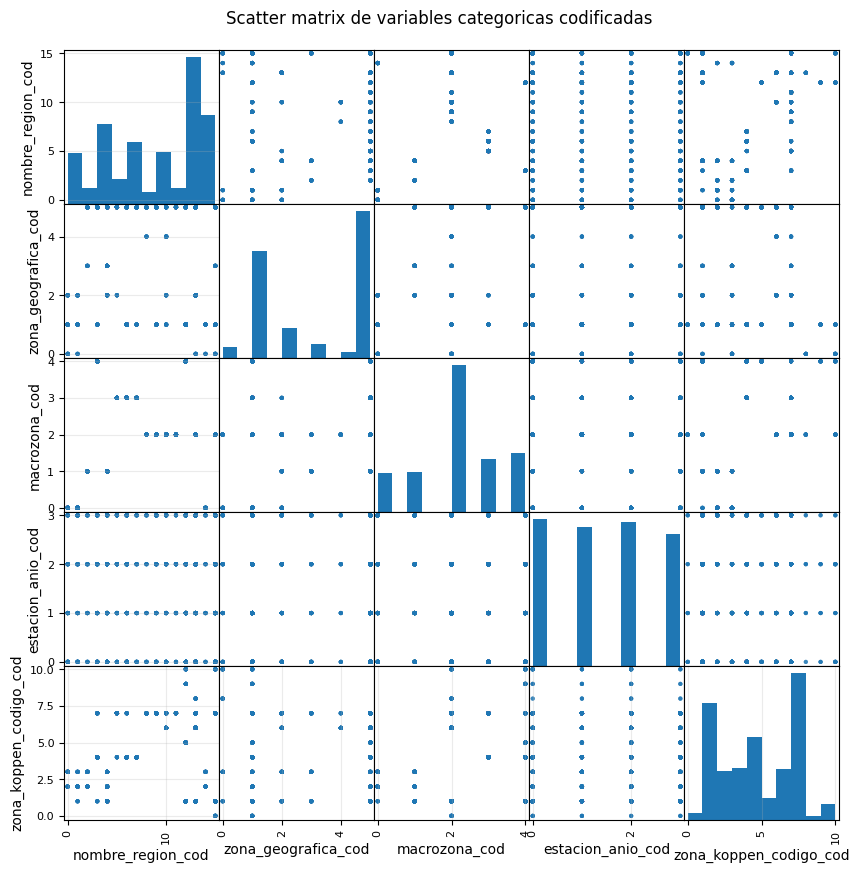

In [73]:
if sns is not None:
    sns.pairplot(
        muestra_categoricas,
        vars=columnas_categoricas_cod,
        hue='llueve',
        diag_kind='hist',
        plot_kws={'alpha': 0.25, 's': 10}
    )
    plt.suptitle('Pairplot de variables categoricas codificadas', y=1.02)
    plt.show()
else:
    scatter_matrix(muestra_categoricas[columnas_categoricas_cod], figsize=(10, 10), diagonal='hist')
    plt.suptitle('Scatter matrix de variables categoricas codificadas', y=0.92)
    plt.show()

**Analisis del pairplot categorico:**

El pairplot permite revisar si las categorias codificadas forman agrupaciones visibles. La interpretacion se centra en separacion y concentracion de puntos, no en relaciones lineales estrictas, porque las variables son categoricas.

**Mini objetivo:** estimar asociaciones de alto impacto entre variables transformadas y objetivos de lluvia mediante correlaciones absolutas.

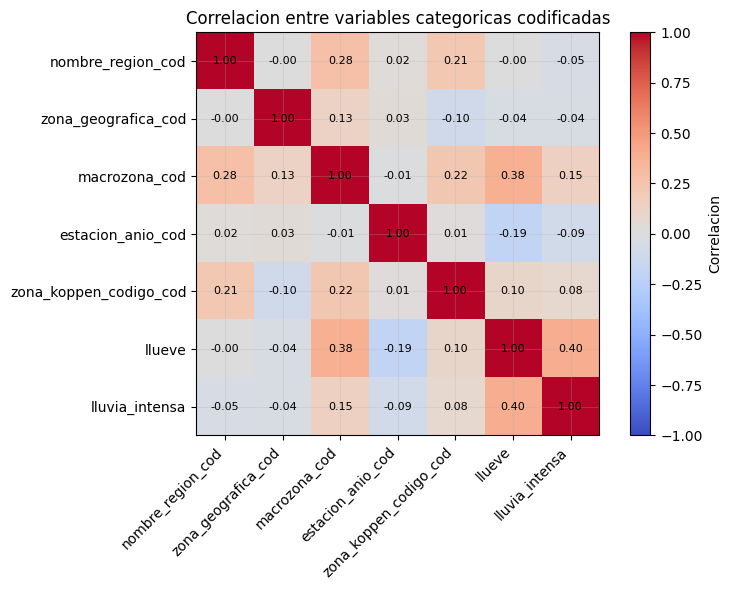

In [74]:
matriz_categorica = muestra_categoricas[columnas_categoricas_cod + ['llueve', 'lluvia_intensa']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_categorica, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlacion entre variables categoricas codificadas')
ax.set_xticks(range(len(matriz_categorica.columns)))
ax.set_xticklabels(matriz_categorica.columns, rotation=45, ha='right')
ax.set_yticks(range(len(matriz_categorica.index)))
ax.set_yticklabels(matriz_categorica.index)
for y in range(matriz_categorica.shape[0]):
    for x in range(matriz_categorica.shape[1]):
        ax.text(x, y, f'{matriz_categorica.iloc[y, x]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Correlacion')
plt.tight_layout()
plt.show()

**Analisis de correlacion categorica:**

La matriz resume asociaciones entre variables categoricas transformadas y objetivos binarios. Los valores sirven como indicio exploratorio de impacto, no como prueba causal, y complementan los graficos territoriales.

## 3.4 Imputacion simple, encoding y variables de alto impacto

En modelamiento supervisado, la matriz `X` corresponde al conjunto de variables predictoras o explicativas. Estas variables representan la informacion disponible antes de predecir: ubicacion, tiempo, temperatura y categorias territoriales. La variable `Y` corresponde al objetivo que el modelo intenta estimar o clasificar.

En este proyecto existen tres objetivos supervisados. Para regresion, `Y` es `agua_caida_tratada`, porque se busca estimar un valor numerico de precipitacion. Para clasificacion, `Y` puede ser `llueve` o `lluvia_intensa`, porque ambas variables representan clases binarias. Las variables objetivo no se incorporan dentro de `X`, ya que eso produciria fuga de informacion y haria que el modelo aprenda una respuesta que ya conoce.

**Mini objetivo:** definir de forma explicita que columnas se usan como `X`, que columnas se usan como `Y` y que columnas quedan excluidas del conjunto predictor.

In [75]:
columnas_numericas_base = [
    'altura', 'latitud', 'longitud', 'anio', 'mes', 'mes_sin', 'mes_cos',
    'temp_max', 'temp_min', 'temp_media', 'rango_termico'
]

columnas_categoricas_base = [
    'nombre_region', 'zona_geografica', 'macrozona',
    'estacion_anio', 'zona_koppen_codigo'
]

objetivos_supervisados = ['agua_caida_tratada', 'llueve', 'lluvia_intensa']
variables_excluidas_x = ['agua_caida', 'codigo_estacion', 'fecha', 'dia', 'nombre_estacion']

tabla_roles_xy = pd.DataFrame(
    [{'variable': v, 'rol': 'X numerica', 'uso': 'Predictora directa'} for v in columnas_numericas_base] +
    [{'variable': v, 'rol': 'X categorica', 'uso': 'Predictora codificada con one-hot'} for v in columnas_categoricas_base] +
    [{'variable': v, 'rol': 'Y objetivo', 'uso': 'Variable a predecir, no entra como X'} for v in objetivos_supervisados] +
    [{'variable': v, 'rol': 'Excluida de X', 'uso': 'Identificador, fecha cruda, auditoria o posible fuga'} for v in variables_excluidas_x]
)

display(tabla_roles_xy)

,variable,rol,uso
0,altura,X numerica,Predictora directa
1,latitud,X numerica,Predictora directa
2,longitud,X numerica,Predictora directa
3,anio,X numerica,Predictora directa
4,mes,X numerica,Predictora directa
5,mes_sin,X numerica,Predictora directa
6,mes_cos,X numerica,Predictora directa
7,temp_max,X numerica,Predictora directa
8,temp_min,X numerica,Predictora directa
9,temp_media,X numerica,Predictora directa


**Analisis de seleccion X/Y:**

La seleccion separa claramente entradas y salidas del problema predictivo. Las variables `X numerica` describen magnitudes observables como altura, coordenadas, temperatura y ciclo temporal. Las variables `X categorica` describen grupos territoriales o climaticos y se codifican despues para que los modelos puedan procesarlas. Las variables `Y objetivo` quedan fuera de `X` porque son la respuesta esperada. Las variables excluidas no aportan como predictores directos o pueden generar fuga de informacion, especialmente `agua_caida`, que esta directamente relacionada con `agua_caida_tratada`, `llueve` y `lluvia_intensa`.

**Mini objetivo:** analizar el aporte esperado de cada grupo de variables `X` antes de construir los modelos.

In [76]:
analisis_grupos_x = pd.DataFrame([
    {'grupo_X': 'Geograficas', 'variables': 'altura, latitud, longitud', 'aporte_esperado': 'Explican gradientes territoriales de temperatura y lluvia'},
    {'grupo_X': 'Temporales', 'variables': 'anio, mes, mes_sin, mes_cos, estacion_anio', 'aporte_esperado': 'Capturan estacionalidad y diferencias entre periodos'},
    {'grupo_X': 'Climaticas', 'variables': 'temp_max, temp_min, temp_media, rango_termico', 'aporte_esperado': 'Resumen condiciones termicas del registro'},
    {'grupo_X': 'Territoriales', 'variables': 'region, zona_geografica, macrozona, zona_koppen_codigo', 'aporte_esperado': 'Representan patrones climaticos por agrupacion espacial'},
    {'grupo_X': 'Excluidas', 'variables': 'agua_caida, fecha, codigo_estacion, nombre_estacion', 'aporte_esperado': 'Evitan fuga, ruido identificador o duplicacion directa de la respuesta'}
])

display(analisis_grupos_x)

,grupo_X,variables,aporte_esperado
0,Geograficas,"altura, latitud, longitud",Explican gradientes territoriales de temperatu...
1,Temporales,"anio, mes, mes_sin, mes_cos, estacion_anio",Capturan estacionalidad y diferencias entre pe...
2,Climaticas,"temp_max, temp_min, temp_media, rango_termico",Resumen condiciones termicas del registro
3,Territoriales,"region, zona_geografica, macrozona, zona_koppe...",Representan patrones climaticos por agrupacion...
4,Excluidas,"agua_caida, fecha, codigo_estacion, nombre_est...","Evitan fuga, ruido identificador o duplicacion..."


**Analisis del aporte de variables X:**

El conjunto `X` se construye con variables disponibles antes de la prediccion y con sentido climatico. Las variables geograficas aportan posicion y altura, las temporales capturan estacionalidad, las climaticas resumen condiciones termicas y las territoriales incorporan diferencias por zona. La exclusion de `agua_caida` es clave: aunque se relaciona fuertemente con los objetivos, usarla como predictor haria que el modelo recibiera informacion demasiado cercana a la respuesta real.

**Mini objetivo:** resumir como se interpreta `X` e `Y` segun el tipo de modelo utilizado en el proyecto.

In [77]:
resumen_xy_modelos = pd.DataFrame([
    {'tipo_modelo': 'Regresion', 'X': 'variables numericas + categoricas codificadas', 'Y': 'agua_caida_tratada', 'interpretacion': 'Predice un valor numerico de precipitacion'},
    {'tipo_modelo': 'Clasificacion llueve', 'X': 'variables numericas + categoricas codificadas', 'Y': 'llueve', 'interpretacion': 'Clasifica si existe lluvia o no'},
    {'tipo_modelo': 'Clasificacion lluvia intensa', 'X': 'variables numericas + categoricas codificadas', 'Y': 'lluvia_intensa', 'interpretacion': 'Clasifica eventos intensos'},
    {'tipo_modelo': 'Cluster', 'X': 'variables agregadas por estacion', 'Y': 'no aplica', 'interpretacion': 'Agrupa estaciones sin variable objetivo'}
])

display(resumen_xy_modelos)

,tipo_modelo,X,Y,interpretacion
0,Regresion,variables numericas + categoricas codificadas,agua_caida_tratada,Predice un valor numerico de precipitacion
1,Clasificacion llueve,variables numericas + categoricas codificadas,llueve,Clasifica si existe lluvia o no
2,Clasificacion lluvia intensa,variables numericas + categoricas codificadas,lluvia_intensa,Clasifica eventos intensos
3,Cluster,variables agregadas por estacion,no aplica,Agrupa estaciones sin variable objetivo


**Analisis de interpretacion X/Y:**

En regresion y clasificacion existe una variable `Y` porque el entrenamiento es supervisado. En cluster no existe `Y`, ya que el algoritmo busca grupos a partir de la estructura interna de `X`. Esta diferencia evita confundir prediccion supervisada con segmentacion descriptiva.

**Mini objetivo:** profundizar la lectura analitica de cada variable `Y` y su relacion con las preguntas del proyecto.

In [78]:
analisis_objetivos_y = pd.DataFrame([
    {'Y': 'agua_caida_tratada', 'tipo': 'Regresion', 'pregunta': 'Cuanta precipitacion se estima', 'dificultad': 'Alta variabilidad y muchos valores bajos'},
    {'Y': 'llueve', 'tipo': 'Clasificacion binaria', 'pregunta': 'Existe lluvia o no existe lluvia', 'dificultad': 'Desbalance entre dias secos y lluviosos'},
    {'Y': 'lluvia_intensa', 'tipo': 'Clasificacion binaria', 'pregunta': 'Existe evento de lluvia intensa', 'dificultad': 'Clase positiva poco frecuente'},
    {'Y': 'no aplica', 'tipo': 'Cluster', 'pregunta': 'Que estaciones se parecen entre si', 'dificultad': 'Interpretar grupos sin respuesta conocida'}
])

display(analisis_objetivos_y)

,Y,tipo,pregunta,dificultad
0,agua_caida_tratada,Regresion,Cuanta precipitacion se estima,Alta variabilidad y muchos valores bajos
1,llueve,Clasificacion binaria,Existe lluvia o no existe lluvia,Desbalance entre dias secos y lluviosos
2,lluvia_intensa,Clasificacion binaria,Existe evento de lluvia intensa,Clase positiva poco frecuente
3,no aplica,Cluster,Que estaciones se parecen entre si,Interpretar grupos sin respuesta conocida


**Analisis de variables Y:**

Cada `Y` responde una pregunta distinta. `agua_caida_tratada` permite una prediccion numerica, pero es una variable dificil porque la lluvia diaria concentra muchos ceros y pocos eventos altos. `llueve` simplifica el problema a presencia o ausencia de lluvia, por lo que facilita la clasificacion. `lluvia_intensa` es mas exigente porque los eventos extremos son menos frecuentes y los errores pueden ser mas relevantes para la toma de decisiones. En cluster no existe `Y`, porque el objetivo es descubrir grupos de estaciones sin una etiqueta previa.

**Mini objetivo:** separar entrenamiento y prueba antes de imputar, evitando que informacion del conjunto de prueba influya en la preparacion del entrenamiento.

In [79]:
df_modelo_base = df_eda[columnas_numericas_base + columnas_categoricas_base + objetivos_supervisados].copy()
df_supervisado = df_modelo_base.dropna(subset=objetivos_supervisados).copy()
df_supervisado[['llueve', 'lluvia_intensa']] = df_supervisado[['llueve', 'lluvia_intensa']].astype(int)

y_regresion = df_supervisado['agua_caida_tratada']
y_clasificacion_llueve = df_supervisado['llueve']
y_clasificacion_intensa = df_supervisado['lluvia_intensa']

idx_train, idx_test = train_test_split(df_supervisado.index, test_size=0.25, random_state=42, stratify=df_supervisado['llueve'])
X_train_base = df_supervisado.loc[idx_train, columnas_numericas_base + columnas_categoricas_base].copy()
X_test_base = df_supervisado.loc[idx_test, columnas_numericas_base + columnas_categoricas_base].copy()
y_train_regresion = y_regresion.loc[idx_train]
y_test_regresion = y_regresion.loc[idx_test]

resumen_split = pd.DataFrame([
    {'particion': 'X_train_base', 'registros': len(X_train_base), 'rol': 'predictoras entrenamiento'},
    {'particion': 'X_test_base', 'registros': len(X_test_base), 'rol': 'predictoras prueba'},
    {'particion': 'y_train_regresion', 'registros': len(y_train_regresion), 'rol': 'objetivo regresion entrenamiento'},
    {'particion': 'y_test_regresion', 'registros': len(y_test_regresion), 'rol': 'objetivo regresion prueba'}
])
display(resumen_split)

,particion,registros,rol
0,X_train_base,128109,predictoras entrenamiento
1,X_test_base,42704,predictoras prueba
2,y_train_regresion,128109,objetivo regresion entrenamiento
3,y_test_regresion,42704,objetivo regresion prueba


**Analisis de separacion train/test:**

La division se realiza antes de imputar y escalar para evitar fuga de informacion. `X_train_base` y `X_test_base` contienen solo variables predictoras. `y_train_regresion` y `y_test_regresion` contienen la respuesta numerica de regresion. Las respuestas de clasificacion (`llueve` y `lluvia_intensa`) se mantienen en `df_supervisado` y se separan con los mismos indices de entrenamiento y prueba en la fase de modelamiento.

**Mini objetivo:** aplicar imputacion simple usando mediana para variables numericas y moda para variables categoricas.

In [80]:
medianas_train = X_train_base[columnas_numericas_base].median()
modas_train = X_train_base[columnas_categoricas_base].mode().iloc[0]

X_train_imputado = X_train_base.copy()
X_test_imputado = X_test_base.copy()
X_train_imputado[columnas_numericas_base] = X_train_imputado[columnas_numericas_base].fillna(medianas_train)
X_test_imputado[columnas_numericas_base] = X_test_imputado[columnas_numericas_base].fillna(medianas_train)
X_train_imputado[columnas_categoricas_base] = X_train_imputado[columnas_categoricas_base].fillna(modas_train)
X_test_imputado[columnas_categoricas_base] = X_test_imputado[columnas_categoricas_base].fillna(modas_train)

resumen_imputacion = pd.DataFrame([
    {'grupo': 'numericas', 'criterio': 'mediana de train', 'nulos_train': int(X_train_imputado[columnas_numericas_base].isna().sum().sum())},
    {'grupo': 'categoricas', 'criterio': 'moda de train', 'nulos_train': int(X_train_imputado[columnas_categoricas_base].isna().sum().sum())}
])

display(resumen_imputacion)

,grupo,criterio,nulos_train
0,numericas,mediana de train,0
1,categoricas,moda de train,0


**Analisis de imputacion simple:**

La imputacion simple es trazable y adecuada para una primera preparacion formal. La mediana reduce el efecto de extremos numericos, mientras que la moda conserva la categoria mas representativa sin introducir modelos auxiliares.

**Mini objetivo:** aplicar encoding a variables categoricas y construir matrices finales para modelos supervisados.

In [81]:
X_train_cat = pd.get_dummies(X_train_imputado[columnas_categoricas_base], prefix=columnas_categoricas_base, dtype=int)
X_test_cat = pd.get_dummies(X_test_imputado[columnas_categoricas_base], prefix=columnas_categoricas_base, dtype=int)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

X_train = pd.concat([X_train_imputado[columnas_numericas_base], X_train_cat], axis=1)
X_test = pd.concat([X_test_imputado[columnas_numericas_base], X_test_cat], axis=1)
X_supervisado = pd.concat([X_train, X_test]).sort_index()
columnas_predictoras = list(X_train.columns)

resumen_encoding = pd.DataFrame([
    {'indicador': 'variables numericas', 'valor': len(columnas_numericas_base)},
    {'indicador': 'variables categoricas one-hot', 'valor': X_train_cat.shape[1]},
    {'indicador': 'predictoras finales', 'valor': len(columnas_predictoras)},
    {'indicador': 'nulos finales train', 'valor': int(X_train.isna().sum().sum())}
])

display(resumen_encoding)

,indicador,valor
0,variables numericas,11
1,variables categoricas one-hot,42
2,predictoras finales,53
3,nulos finales train,0


**Analisis de encoding:**

El encoding one-hot convierte cada categoria en columnas binarias, por ejemplo una columna para cada macrozona o codigo Koppen-Geiger. Esto permite que los modelos usen informacion territorial y climatica sin asumir que una categoria es mayor o menor que otra. Despues de esta transformacion, `X_train` y `X_test` representan la version final de las variables predictoras: combinan numericas originales imputadas y categoricas codificadas. Esa matriz final es la que alimenta arboles y, tras escalamiento numerico, tambien regresion lineal, SVM y K-Means.

**Mini objetivo:** identificar variables de alto impacto exploratorio mediante correlacion absoluta con los objetivos principales.

In [82]:
datos_impacto = X_train.copy()
datos_impacto['agua_caida_tratada'] = y_train_regresion
datos_impacto['llueve'] = df_supervisado.loc[idx_train, 'llueve']
datos_impacto['lluvia_intensa'] = df_supervisado.loc[idx_train, 'lluvia_intensa']

impactos = []
for objetivo in objetivos_supervisados:
    correlaciones = datos_impacto[columnas_predictoras].corrwith(datos_impacto[objetivo]).abs()
    for variable, valor in correlaciones.dropna().items():
        impactos.append({'variable': variable, 'objetivo': objetivo, 'impacto_abs': valor})

impacto_variables = pd.DataFrame(impactos)
impacto_resumen = impacto_variables.groupby('variable')['impacto_abs'].mean().sort_values(ascending=False).head(15)
display(impacto_resumen.to_frame('impacto_promedio'))

,impacto_promedio
variable,
temp_max,0.276
rango_termico,0.253
zona_koppen_codigo_Cfb,0.234
latitud,0.211
temp_media,0.208
macrozona_Zona Sur,0.201
nombre_region_De Los Lagos,0.169
mes_cos,0.130
nombre_region_Aysén del Gral. Carlos Ibáñez del Campo,0.126


**Analisis de variables de alto impacto:**

El ranking resume variables con mayor asociacion exploratoria promedio respecto de lluvia tratada, presencia de lluvia y lluvia intensa. La lectura es de relevancia estadistica preliminar, no de causalidad.

**Mini objetivo:** graficar las variables de mayor impacto para facilitar la lectura comparativa.

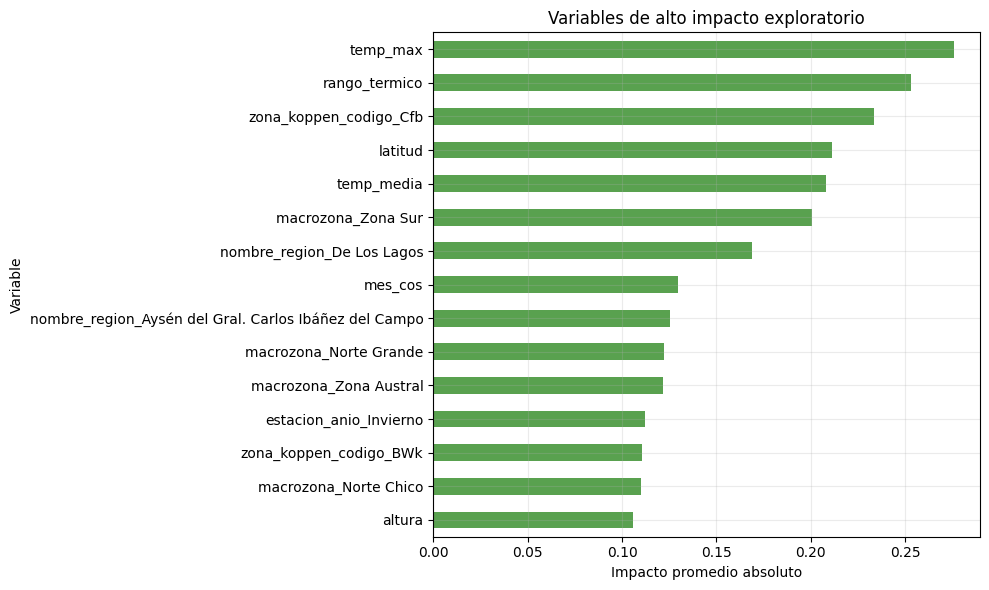

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
impacto_resumen.sort_values().plot(kind='barh', ax=ax, color='#59a14f')
ax.set_title('Variables de alto impacto exploratorio')
ax.set_xlabel('Impacto promedio absoluto')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

**Analisis del grafico de impacto:**

El grafico permite priorizar variables antes de modelar. Las variables territoriales, climaticas y temporales con mayor impacto entregan una base objetiva para justificar su permanencia en el dataset final.

**Mini objetivo:** sintetizar insights de transformacion vinculados con territorio, clima y calidad de datos.

In [84]:
insights_fase3 = pd.DataFrame([
    {'insight': 'Las zonas Koppen-Geiger oficiales agregan lectura climatica territorial.', 'evidencia': 'Relacion Koppen-Geiger-zona geografica'},
    {'insight': 'La ubicacion de estaciones aporta informacion para lluvia y temperatura.', 'evidencia': 'Mapa de calor por estacion'},
    {'insight': 'La variacion anual debe conservarse en variables temporales.', 'evidencia': 'Promedios por anio'},
    {'insight': 'Las categorias territoriales y climaticas requieren encoding sin orden artificial.', 'evidencia': 'One-hot encoding'},
    {'insight': 'La imputacion simple deja una base trazable para modelos.', 'evidencia': 'Mediana y moda calculadas en train'}
])

display(insights_fase3)

,insight,evidencia
0,Las zonas Koppen-Geiger oficiales agregan lect...,Relacion Koppen-Geiger-zona geografica
1,La ubicacion de estaciones aporta informacion ...,Mapa de calor por estacion
2,La variacion anual debe conservarse en variabl...,Promedios por anio
3,Las categorias territoriales y climaticas requ...,One-hot encoding
4,La imputacion simple deja una base trazable pa...,Mediana y moda calculadas en train


**Analisis de insights:**

Los insights resumen decisiones de preparacion con evidencia visible en tablas y graficos. Esta sintesis conecta transformacion con modelamiento y evita que la fase quede reducida a operaciones tecnicas.

## 3.5 Escalamiento y dataset para cluster

**Mini objetivo:** escalar solo las variables numericas predictoras, manteniendo las variables one-hot sin escalamiento.

In [85]:
columnas_numericas_escalar = columnas_numericas_base
escalador_supervisado = StandardScaler()

X_train_escalado = X_train.copy()
X_test_escalado = X_test.copy()
X_train_escalado[columnas_numericas_escalar] = escalador_supervisado.fit_transform(X_train[columnas_numericas_escalar])
X_test_escalado[columnas_numericas_escalar] = escalador_supervisado.transform(X_test[columnas_numericas_escalar])

resumen_escalamiento = pd.DataFrame({
    'variable': columnas_numericas_escalar,
    'media_train_escalada': X_train_escalado[columnas_numericas_escalar].mean().values,
    'desv_train_escalada': X_train_escalado[columnas_numericas_escalar].std(ddof=0).values
})

display(resumen_escalamiento.round(3))

,variable,media_train_escalada,desv_train_escalada
0,altura,-0.000,1.000
1,latitud,-0.000,1.000
2,longitud,0.000,1.000
3,anio,0.000,1.000
4,mes,-0.000,1.000
5,mes_sin,-0.000,1.000
6,mes_cos,0.000,1.000
7,temp_max,0.000,1.000
8,temp_min,0.000,1.000
9,temp_media,0.000,1.000


**Analisis del escalamiento:**

El escalamiento se ajusta solo con entrenamiento y se aplica despues a prueba. Las variables one-hot no se escalan porque ya representan presencia o ausencia de categoria; las numericas si requieren estandarizacion para SVM, regresion lineal y K-Means.

**Mini objetivo:** construir una tabla agregada por estacion para segmentacion mediante K-Means.

In [86]:
cluster_estaciones = df_eda.groupby('codigo_estacion').agg(
    altura=('altura', 'median'),
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_media=('agua_caida_tratada', 'mean'),
    frecuencia_lluvia=('llueve', 'mean'),
    zona_koppen_principal=('zona_koppen_codigo', lambda x: x.mode().iloc[0])
).dropna()

columnas_cluster = ['altura', 'latitud', 'longitud', 'temp_media', 'agua_media', 'frecuencia_lluvia']
resumen_cluster = pd.DataFrame([
    {'indicador': 'estaciones para cluster', 'valor': len(cluster_estaciones)},
    {'indicador': 'variables numericas de cluster', 'valor': len(columnas_cluster)},
    {'indicador': 'zonas Koppen-Geiger presentes', 'valor': cluster_estaciones['zona_koppen_principal'].nunique()}
])

display(resumen_cluster)

,indicador,valor
0,estaciones para cluster,109
1,variables numericas de cluster,6
2,zonas Koppen-Geiger presentes,11


**Analisis del dataset de cluster:**

El cluster se trabaja por estacion para resumir comportamiento territorial. La zona Koppen-Geiger oficial queda disponible para interpretar los grupos, mientras que K-Means utiliza variables numericas escalables.

# 4. Modelamiento

Se implementan 9 modelos o configuraciones compatibles con el material del curso: tres de regresion, cuatro de clasificacion y dos de cluster. La seleccion evita modelos externos avanzados y mantiene parametros simples y explicables.

## 4.1 Modelos de regresion

### 4.1.1 Seleccion de variables X/Y

**Mini objetivo:** documentar los modelos de regresion usados para predecir `agua_caida_tratada`.

In [87]:
parametros_regresion = pd.DataFrame([
    {'modelo': 'Regresion lineal', 'X_usada': 'X_train_escalado / X_test_escalado', 'Y_usada': 'y_train_regresion / y_test_regresion', 'objetivo': 'agua_caida_tratada', 'parametros': 'base'},
    {'modelo': 'Arbol regresor', 'X_usada': 'X_train / X_test', 'Y_usada': 'y_train_regresion / y_test_regresion', 'objetivo': 'agua_caida_tratada', 'parametros': 'max_depth=6, min_samples_leaf=80'},
    {'modelo': 'SVM lineal regresion', 'X_usada': 'X_train_escalado / X_test_escalado', 'Y_usada': 'y_train_regresion / y_test_regresion', 'objetivo': 'agua_caida_tratada', 'parametros': 'C=0.5, epsilon=0.1'}
])

display(parametros_regresion)

,modelo,X_usada,Y_usada,objetivo,parametros
0,Regresion lineal,X_train_escalado / X_test_escalado,y_train_regresion / y_test_regresion,agua_caida_tratada,base
1,Arbol regresor,X_train / X_test,y_train_regresion / y_test_regresion,agua_caida_tratada,"max_depth=6, min_samples_leaf=80"
2,SVM lineal regresion,X_train_escalado / X_test_escalado,y_train_regresion / y_test_regresion,agua_caida_tratada,"C=0.5, epsilon=0.1"


**Analisis de modelos de regresion:**

La regresion lineal entrega una base interpretable, el arbol captura relaciones no lineales simples y SVM lineal evalua un enfoque basado en margen. Los tres modelos son adecuados para comparar complejidad sin salir de las tecnicas vistas en el curso.

### 4.1.2 Aplicacion de modelos de regresion

**Mini objetivo:** entrenar los modelos de regresion definidos con parametros controlados.

In [88]:
modelos_regresion = {
    'Regresion lineal': (LinearRegression(), X_train_escalado, X_test_escalado),
    'Arbol regresor': (DecisionTreeRegressor(max_depth=6, min_samples_leaf=80, random_state=42), X_train, X_test),
    'SVM lineal regresion': (LinearSVR(C=0.5, epsilon=0.1, max_iter=5000, random_state=42, dual='auto'), X_train_escalado, X_test_escalado)
}

predicciones_regresion = {}
modelos_regresion_entrenados = {}

for nombre, (modelo, X_entrena, X_prueba) in modelos_regresion.items():
    modelo.fit(X_entrena, y_train_regresion)
    predicciones_regresion[nombre] = modelo.predict(X_prueba)
    modelos_regresion_entrenados[nombre] = modelo

### 4.1.3 Obtencion de metricas de regresion

**Mini objetivo:** comparar MAE, RMSE y R2 de los modelos de regresion.

In [89]:
metricas_regresion = []

for nombre, prediccion in predicciones_regresion.items():
    metricas_regresion.append({
        'modelo': nombre,
        'MAE': mean_absolute_error(y_test_regresion, prediccion),
        'RMSE': np.sqrt(mean_squared_error(y_test_regresion, prediccion)),
        'R2': r2_score(y_test_regresion, prediccion)
    })

metricas_regresion = pd.DataFrame(metricas_regresion).sort_values('RMSE')
display(metricas_regresion.round(3))

,modelo,MAE,RMSE,R2
1,Arbol regresor,1.312,3.066,0.181
0,Regresion lineal,1.572,3.146,0.138
2,SVM lineal regresion,1.046,3.484,-0.058


**Analisis de metricas de regresion:**

RMSE es clave porque penaliza mas los errores grandes, algo importante en precipitacion. Si un modelo subestima eventos altos de lluvia, RMSE lo evidencia mejor que MAE. R2 ayuda a medir capacidad explicativa, aunque en lluvia diaria suele ser limitado por la alta cantidad de ceros y la variabilidad natural.

## 4.2 Modelos de clasificacion

### 4.2.1 Seleccion de variables X/Y

**Mini objetivo:** documentar modelos de clasificacion para `llueve` y `lluvia_intensa`.

In [90]:
parametros_clasificacion = pd.DataFrame([
    {'modelo': 'Arbol clasificador', 'X_usada': 'X_train / X_test', 'Y_usada': 'llueve', 'parametros': 'max_depth=6, class_weight=balanced'},
    {'modelo': 'Arbol clasificador', 'X_usada': 'X_train / X_test', 'Y_usada': 'lluvia_intensa', 'parametros': 'max_depth=6, class_weight=balanced'},
    {'modelo': 'Naive Bayes', 'X_usada': 'X_train_escalado / X_test_escalado', 'Y_usada': 'llueve', 'parametros': 'GaussianNB'},
    {'modelo': 'SVM lineal', 'X_usada': 'X_train_escalado / X_test_escalado', 'Y_usada': 'llueve', 'parametros': 'C=0.5, class_weight=balanced'}
])

display(parametros_clasificacion)

,modelo,X_usada,Y_usada,parametros
0,Arbol clasificador,X_train / X_test,llueve,"max_depth=6, class_weight=balanced"
1,Arbol clasificador,X_train / X_test,lluvia_intensa,"max_depth=6, class_weight=balanced"
2,Naive Bayes,X_train_escalado / X_test_escalado,llueve,GaussianNB
3,SVM lineal,X_train_escalado / X_test_escalado,llueve,"C=0.5, class_weight=balanced"


**Analisis de modelos de clasificacion:**

Los arboles permiten reglas interpretables, Naive Bayes entrega una base probabilistica simple y SVM lineal evalua separacion por margen. Para clases desbalanceadas se usa `class_weight=balanced` en arboles y SVM.

### 4.2.2 Aplicacion de modelos de clasificacion

**Mini objetivo:** entrenar modelos de clasificacion y guardar predicciones para evaluacion.

In [91]:
y_train_llueve = df_supervisado.loc[idx_train, 'llueve']
y_test_llueve = df_supervisado.loc[idx_test, 'llueve']
y_train_intensa = df_supervisado.loc[idx_train, 'lluvia_intensa']
y_test_intensa = df_supervisado.loc[idx_test, 'lluvia_intensa']

modelos_clasificacion = [
    ('Arbol llueve', 'llueve', DecisionTreeClassifier(max_depth=6, min_samples_leaf=80, class_weight='balanced', random_state=42), X_train, X_test, y_train_llueve, y_test_llueve),
    ('Arbol lluvia intensa', 'lluvia_intensa', DecisionTreeClassifier(max_depth=6, min_samples_leaf=80, class_weight='balanced', random_state=42), X_train, X_test, y_train_intensa, y_test_intensa),
    ('Naive Bayes llueve', 'llueve', GaussianNB(), X_train_escalado, X_test_escalado, y_train_llueve, y_test_llueve),
    ('SVM lineal llueve', 'llueve', LinearSVC(C=0.5, class_weight='balanced', max_iter=5000, random_state=42, dual='auto'), X_train_escalado, X_test_escalado, y_train_llueve, y_test_llueve)
]

predicciones_clasificacion = {}

for nombre, objetivo, modelo, X_entrena, X_prueba, y_entrena, y_prueba in modelos_clasificacion:
    modelo.fit(X_entrena, y_entrena)
    predicciones_clasificacion[f'{nombre}|{objetivo}'] = (y_prueba, modelo.predict(X_prueba))

### 4.2.3 Obtencion de metricas de clasificacion

**Mini objetivo:** comparar accuracy, precision, recall y F1-score.

In [92]:
metricas_clasificacion = []

for clave, (y_real, y_pred) in predicciones_clasificacion.items():
    nombre, objetivo = clave.split('|')
    metricas_clasificacion.append({
        'clave': clave,
        'modelo': nombre,
        'objetivo': objetivo,
        'accuracy': accuracy_score(y_real, y_pred),
        'precision': precision_score(y_real, y_pred, zero_division=0),
        'recall': recall_score(y_real, y_pred, zero_division=0),
        'F1': f1_score(y_real, y_pred, zero_division=0)
    })

metricas_clasificacion = pd.DataFrame(metricas_clasificacion).sort_values(['objetivo', 'F1'], ascending=[True, False])
display(metricas_clasificacion.drop(columns='clave').round(3))

,modelo,objetivo,accuracy,precision,recall,F1
0,Arbol llueve,llueve,0.747,0.504,0.841,0.630
3,SVM lineal llueve,llueve,0.750,0.506,0.823,0.627
2,Naive Bayes llueve,llueve,0.665,0.424,0.871,0.570
1,Arbol lluvia intensa,lluvia_intensa,0.756,0.153,0.824,0.258


**Analisis de metricas de clasificacion:**

En lluvia no basta mirar accuracy, porque la clase sin lluvia es mayoritaria. Recall indica cuanta lluvia real detecta el modelo, precision indica cuantas alertas son correctas y F1 resume el equilibrio entre ambas.

## 4.3 Modelos de cluster

### 4.3.1 Seleccion de variables X

**Mini objetivo:** preparar K-Means para segmentar estaciones segun ubicacion, temperatura, precipitacion media y frecuencia de lluvia.

In [93]:
escalador_cluster = StandardScaler()
X_cluster_escalado = escalador_cluster.fit_transform(cluster_estaciones[columnas_cluster])

parametros_cluster = pd.DataFrame([
    {'modelo': 'K-Means', 'configuracion': 'K=3', 'uso': 'segmentacion simple'},
    {'modelo': 'K-Means', 'configuracion': 'K=5', 'uso': 'segmentacion comparativa'},
    {'modelo': 'Metodo del codo', 'configuracion': 'K=2 a K=7', 'uso': 'evaluar inercia'}
])

display(parametros_cluster)

,modelo,configuracion,uso
0,K-Means,K=3,segmentacion simple
1,K-Means,K=5,segmentacion comparativa
2,Metodo del codo,K=2 a K=7,evaluar inercia


**Analisis de variables de cluster:**

K-Means requiere variables escaladas porque trabaja con distancias. La segmentacion se realiza por estacion para obtener perfiles climaticos interpretables, no clasificaciones registro a registro.

### 4.3.2 Aplicacion y metricas de cluster

**Mini objetivo:** entrenar K-Means con distintos valores de K y comparar inercia y silhouette.

In [94]:
metricas_cluster = []
modelos_cluster = {}

for k in range(2, 8):
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(X_cluster_escalado)
    modelos_cluster[k] = (modelo, etiquetas)
    metricas_cluster.append({
        'K': k,
        'inercia': modelo.inertia_,
        'silhouette': silhouette_score(X_cluster_escalado, etiquetas)
    })

metricas_cluster = pd.DataFrame(metricas_cluster)
cluster_estaciones['cluster_k3'] = modelos_cluster[3][1]
cluster_estaciones['cluster_k5'] = modelos_cluster[5][1]
display(metricas_cluster.round(3))

,K,inercia,silhouette
0,2,376.091,0.475
1,3,281.572,0.483
2,4,187.470,0.522
3,5,136.092,0.518
4,6,107.198,0.426
5,7,90.480,0.414


**Analisis de metricas de cluster:**

La inercia baja al aumentar K, como es esperable, mientras que silhouette ayuda a evaluar separacion entre grupos. K=3 entrega una lectura simple y K=5 permite una segmentacion territorial mas fina.

### 4.3.3 Perfil de clusters

**Mini objetivo:** resumir el perfil de los clusters para interpretar los grupos encontrados.

In [95]:
perfil_clusters_k3 = cluster_estaciones.groupby('cluster_k3')[columnas_cluster].mean()
perfil_clusters_k5 = cluster_estaciones.groupby('cluster_k5')[columnas_cluster].mean()

resumen_perfil_k3 = perfil_clusters_k3.round(3)
display(resumen_perfil_k3)

,altura,latitud,longitud,temp_media,agua_media,frecuencia_lluvia
cluster_k3,,,,,,
0,691.652,-30.430,-70.803,14.572,0.358,0.110
1,138.286,-44.148,-72.100,9.627,2.055,0.484
2,69.000,-27.159,-109.432,20.614,1.743,0.522


**Analisis de perfiles de cluster:**

Los perfiles permiten describir cada grupo segun altura, ubicacion, temperatura, precipitacion media y frecuencia de lluvia. Esto convierte K-Means en una herramienta interpretable para segmentacion climatica.

# 5. Evaluacion

La evaluacion compara los resultados de regresion, clasificacion y cluster. Se usan metricas normales, sin transformaciones de escala, y se conectan los resultados con la utilidad para toma de decisiones.

## 5.1 Resumen comparativo de modelos

**Mini objetivo:** identificar los mejores modelos de cada familia segun metricas relevantes.

In [96]:
mejor_regresion = metricas_regresion.iloc[0]
mejor_clasificacion = metricas_clasificacion.sort_values('F1', ascending=False).iloc[0]
mejor_cluster = metricas_cluster.sort_values('silhouette', ascending=False).iloc[0]

resumen_mejores_modelos = pd.DataFrame([
    {'familia': 'Regresion', 'mejor_modelo': mejor_regresion['modelo'], 'criterio': 'menor RMSE', 'valor': mejor_regresion['RMSE']},
    {'familia': 'Clasificacion', 'mejor_modelo': mejor_clasificacion['modelo'], 'criterio': 'mayor F1', 'valor': mejor_clasificacion['F1']},
    {'familia': 'Cluster', 'mejor_modelo': f"K-Means K={int(mejor_cluster['K'])}", 'criterio': 'mayor silhouette', 'valor': mejor_cluster['silhouette']}
])

display(resumen_mejores_modelos.round(3))

,familia,mejor_modelo,criterio,valor
0,Regresion,Arbol regresor,menor RMSE,3.066
1,Clasificacion,Arbol llueve,mayor F1,0.630
2,Cluster,K-Means K=4,mayor silhouette,0.522


**Analisis comparativo:**

El mejor modelo de regresion se selecciona por RMSE porque interesa controlar errores grandes de precipitacion. En clasificacion se prioriza F1 por el desbalance de clases. En cluster se usa silhouette para elegir una segmentacion con grupos mas separados.

## 5.2 Evaluacion de regresion

**Mini objetivo:** graficar metricas y comparar valores reales versus predichos del mejor modelo de regresion.

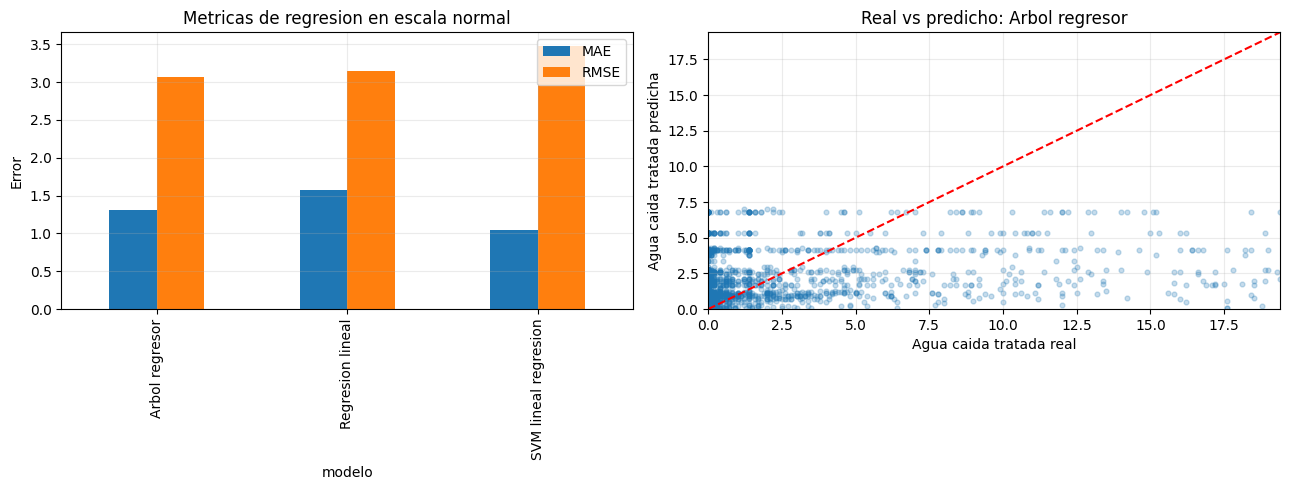

In [97]:
nombre_mejor_regresion = mejor_regresion['modelo']
pred_mejor_regresion = predicciones_regresion[nombre_mejor_regresion]
comparacion_regresion = pd.DataFrame({'real': y_test_regresion, 'predicho': pred_mejor_regresion})
muestra_regresion = comparacion_regresion.sample(min(5000, len(comparacion_regresion)), random_state=42)
limite_regresion = comparacion_regresion['real'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas_regresion.set_index('modelo')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Metricas de regresion en escala normal')
axes[0].set_ylabel('Error')

axes[1].scatter(muestra_regresion['real'], muestra_regresion['predicho'], alpha=0.25, s=12)
axes[1].plot([0, limite_regresion], [0, limite_regresion], color='red', linestyle='--')
axes[1].set_xlim(0, limite_regresion)
axes[1].set_ylim(0, limite_regresion)
axes[1].set_title(f'Real vs predicho: {nombre_mejor_regresion}')
axes[1].set_xlabel('Agua caida tratada real')
axes[1].set_ylabel('Agua caida tratada predicha')
plt.tight_layout()
plt.show()

**Analisis de evaluacion de regresion:**

El grafico usa escala normal y limita la vista al percentil 99 para no ocultar la nube principal con pocos eventos extremos. Si los puntos se alejan de la linea roja, el modelo tiene error; esto es esperable en lluvia diaria por su alta variabilidad y concentracion de ceros.

## 5.3 Evaluacion de clasificacion

**Mini objetivo:** revisar matrices de confusion para entender en que clases fallan los modelos.

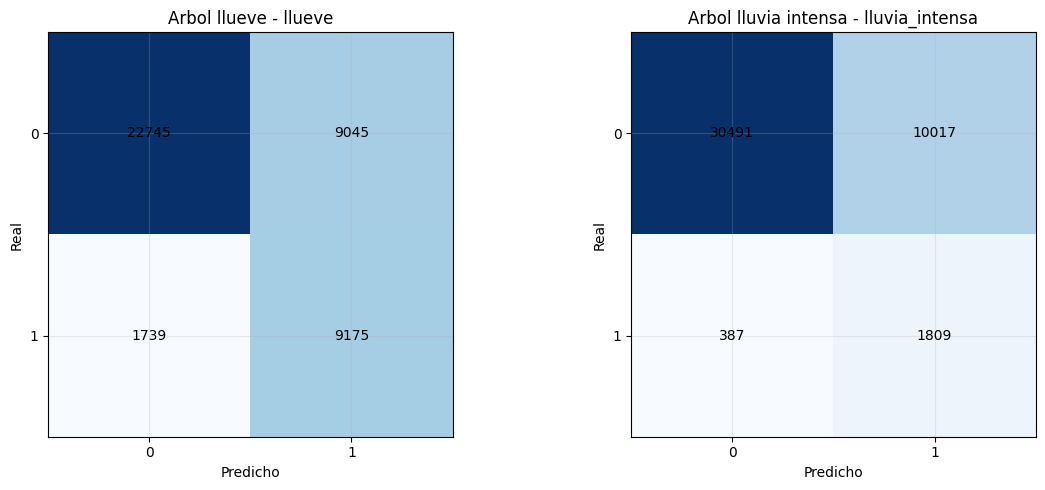

In [98]:
mejores_por_objetivo = metricas_clasificacion.sort_values('F1', ascending=False).groupby('objetivo').head(1)
fig, axes = plt.subplots(1, len(mejores_por_objetivo), figsize=(6 * len(mejores_por_objetivo), 5))
axes = np.atleast_1d(axes)

for ax, (_, fila) in zip(axes, mejores_por_objetivo.iterrows()):
    y_real, y_pred = predicciones_clasificacion[fila['clave']]
    matriz = confusion_matrix(y_real, y_pred, labels=[0, 1])
    im = ax.imshow(matriz, cmap='Blues')
    ax.set_title(f"{fila['modelo']} - {fila['objetivo']}")
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for x in range(2):
        for y in range(2):
            ax.text(x, y, matriz[y, x], ha='center', va='center')

plt.tight_layout()
plt.show()

**Analisis de matrices de confusion:**

La matriz de confusion muestra falsos positivos y falsos negativos. Para lluvia intensa, los falsos negativos son especialmente relevantes porque implican eventos importantes no detectados; por eso recall y F1 pesan mas que accuracy sola.

## 5.4 Evaluacion de cluster

**Mini objetivo:** visualizar el metodo del codo y la distribucion geografica de clusters.

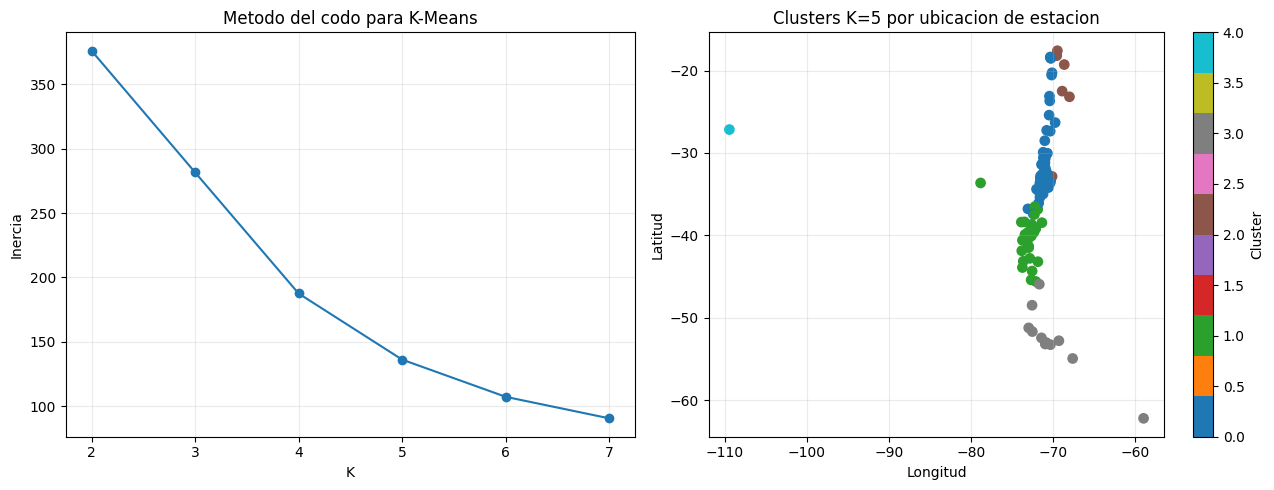

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(metricas_cluster['K'], metricas_cluster['inercia'], marker='o')
axes[0].set_title('Metodo del codo para K-Means')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')

scatter = axes[1].scatter(
    cluster_estaciones['longitud'], cluster_estaciones['latitud'],
    c=cluster_estaciones['cluster_k5'], cmap='tab10', s=45
)
axes[1].set_title('Clusters K=5 por ubicacion de estacion')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.show()

**Analisis de evaluacion de cluster:**

El metodo del codo permite observar cuando agregar mas clusters reduce menos la inercia. El mapa de estaciones ayuda a validar si la segmentacion tiene sentido territorial y no es solo un resultado matematico sin interpretacion climatica.

## 5.5 Mejoras del proceso o modelamiento

**Mini objetivo:** proponer mejoras concretas a partir de los resultados obtenidos.

In [100]:
mejoras_modelamiento = pd.DataFrame([
    {'area': 'Regresion', 'mejora': 'Agregar mas variables atmosfericas para explicar eventos de lluvia'},
    {'area': 'Clasificacion', 'mejora': 'Ajustar umbrales y revisar recall en lluvia intensa'},
    {'area': 'Cluster', 'mejora': 'Comparar clusters con macrozonas y validar estabilidad temporal'},
    {'area': 'Datos', 'mejora': 'Incorporar mas anos y revisar estaciones con nulos altos'},
    {'area': 'Evaluacion', 'mejora': 'Monitorear errores por region, estacion y temporada'}
])

display(mejoras_modelamiento)

,area,mejora
0,Regresion,Agregar mas variables atmosfericas para explic...
1,Clasificacion,Ajustar umbrales y revisar recall en lluvia in...
2,Cluster,Comparar clusters con macrozonas y validar est...
3,Datos,Incorporar mas anos y revisar estaciones con n...
4,Evaluacion,"Monitorear errores por region, estacion y temp..."


**Analisis de mejoras:**

Las mejoras apuntan a aumentar capacidad predictiva sin romper la trazabilidad del notebook. La principal limitacion es que la lluvia diaria depende de factores atmosfericos que no estan completamente representados en el dataset actual.

# 6. Deploy

El despliegue se plantea como una salida academica reproducible. No se implementa una aplicacion externa, pero se define como se podria usar el modelo en un contexto de apoyo a decisiones climaticas.

## 6.1 Propuesta de uso

**Mini objetivo:** definir entrada, salida, usuario objetivo, frecuencia y riesgos del despliegue conceptual.

In [101]:
propuesta_deploy = pd.DataFrame([
    {'elemento': 'Entrada esperada', 'descripcion': 'fecha, estacion, region, macrozona, altura, latitud, longitud y temperaturas'},
    {'elemento': 'Salida esperada', 'descripcion': 'precipitacion tratada estimada, probabilidad operacional de lluvia o alerta de lluvia intensa'},
    {'elemento': 'Usuario objetivo', 'descripcion': 'analistas climaticos, planificacion territorial, agricultura o gestion de riesgo'},
    {'elemento': 'Frecuencia', 'descripcion': 'actualizacion diaria o mensual segun disponibilidad de datos'},
    {'elemento': 'Riesgos', 'descripcion': 'nulos, eventos extremos, estaciones con baja cobertura y cambio climatico'},
    {'elemento': 'Mejoras futuras', 'descripcion': 'mas anos, variables atmosfericas adicionales y monitoreo de drift'}
])

display(propuesta_deploy)

,elemento,descripcion
0,Entrada esperada,"fecha, estacion, region, macrozona, altura, la..."
1,Salida esperada,"precipitacion tratada estimada, probabilidad o..."
2,Usuario objetivo,"analistas climaticos, planificacion territoria..."
3,Frecuencia,actualizacion diaria o mensual segun disponibi...
4,Riesgos,"nulos, eventos extremos, estaciones con baja c..."
5,Mejoras futuras,"mas anos, variables atmosfericas adicionales y..."


**Cierre final del proyecto:**

El notebook queda organizado bajo CRISP-DM, con fases de negocio, datos, transformacion, modelamiento, evaluacion y deploy conceptual. Los modelos usados son compatibles con el curso y las metricas permiten defender resultados de regresion, clasificacion y cluster manteniendo escala normal.